# Market Bets — All 20 Political Markets

Individual bets + cumulative flow + net money per time bucket for every market.
**Green = YES (event happens)  |  Red = NO (event doesn't happen)**

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime, timedelta

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')
plt.rcParams.update({'figure.dpi':110,'axes.titlesize':10,'axes.labelsize':9,
                     'xtick.labelsize':7,'ytick.labelsize':7,'legend.fontsize':7})

C_YES, C_NO, C_NET = '#2ea043', '#cf222e', '#6e40c9'
EDA = Path('.')
CSV_DIR = EDA / 'csv'
CSV_DIR.mkdir(exist_ok=True)

fmt_usdc = mticker.FuncFormatter(
    lambda v,_: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
    else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')

<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_91572/46363757.py:23: SyntaxWarning: invalid escape sequence '\$'
  lambda v,_: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_91572/46363757.py:24: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_91572/46363757.py:24: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')


In [2]:
PRICE_SCHEMA  = {'timestamp': pl.Int64, 'price': pl.Float64}
TRADES_SCHEMA = {'timestamp': pl.Int64, 'price': pl.Float64, 'size': pl.Float64}

markets = pl.read_csv(EDA / 'markets.csv')

# Load and combine all trades
frames = []
for row in markets.iter_rows(named=True):
    p = EDA / row['slug'] / 'trades.csv'
    if not p.exists(): continue
    tr = pl.read_csv(p, schema_overrides=TRADES_SCHEMA, ignore_errors=True)
    tr = tr.with_columns([
        pl.lit(row['slug']).alias('slug'),
        pl.lit(row['question']).alias('market'),
        pl.lit(row['resolution']).alias('resolution'),
        pl.lit(float(row['volume_usdc'] or 0)).alias('volume_usdc'),
        pl.when(pl.col('outcome').str.to_lowercase()=='yes').then(pl.lit('Yes'))
          .when(pl.col('outcome').str.to_lowercase()=='no').then(pl.lit('No'))
          .otherwise(pl.col('outcome')).alias('outcome'),
        (pl.col('timestamp')*1_000_000).cast(pl.Datetime('us')).alias('date'),
    ])
    frames.append(tr)

all_trades = pl.concat(frames)
all_trades.write_csv(CSV_DIR / 'market_bets.csv')
print(f'Saved csv/market_bets.csv  —  {len(all_trades):,} rows')
print(f'{all_trades["slug"].n_unique()} markets')
all_trades.head(3)

Saved csv/market_bets.csv  —  40,000 rows
20 markets


side,price,size,timestamp,outcome,tx_hash,slug,market,resolution,volume_usdc,date
str,f64,f64,i64,str,str,str,str,str,f64,datetime[μs]
"""SELL""",0.998,94.37,1730906435,"""Yes""","""0xcef4b27fdb54c6fd8330cb5cb591…","""will-donald-trump-win-the-2024…","""Will Donald Trump win the 2024…","""Yes""",1.5315e9,2024-11-06 15:20:35
"""SELL""",0.998,5.4,1730906435,"""Yes""","""0x11bce3547abbfbafdafc8b09e432…","""will-donald-trump-win-the-2024…","""Will Donald Trump win the 2024…","""Yes""",1.5315e9,2024-11-06 15:20:35
"""BUY""",0.999,0.35,1730906433,"""Yes""","""0x2b6365ceac2aa48a4f1975b21b6a…","""will-donald-trump-win-the-2024…","""Will Donald Trump win the 2024…","""Yes""",1.5315e9,2024-11-06 15:20:33


## Per-market charts (5 panels each)

Will Donald Trump win the 2024 US Presidential Election?
  YES area: 13,213,671  |  NO area: 491,128


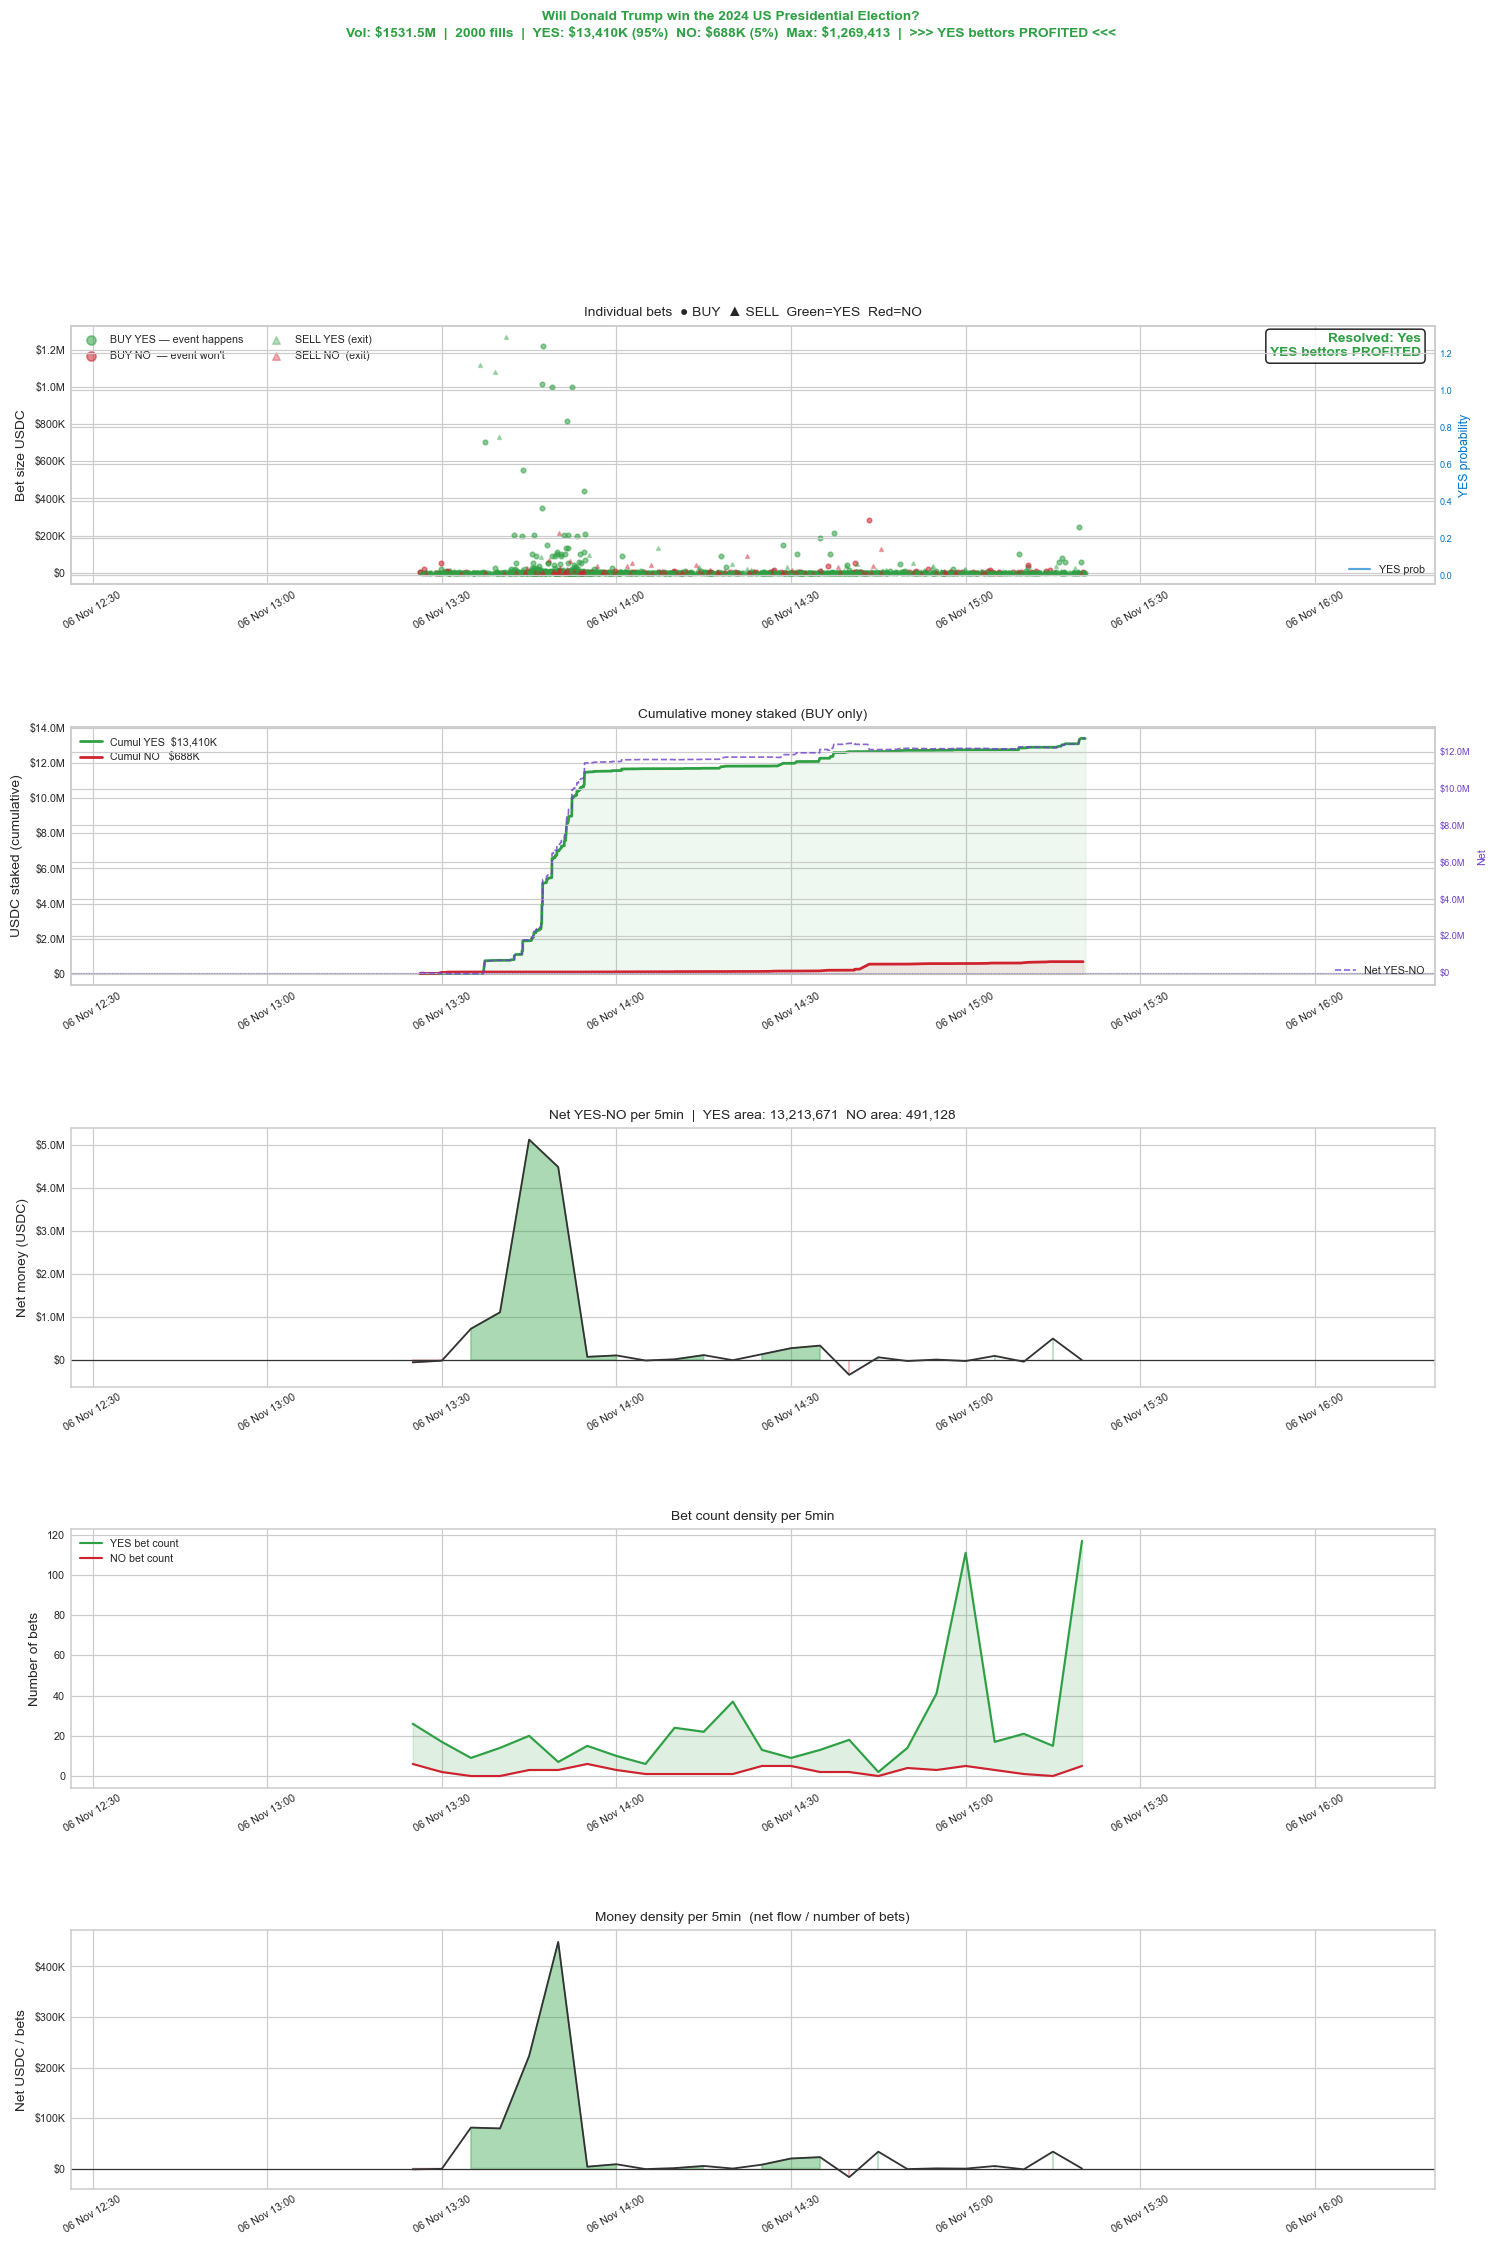

Will Kamala Harris win the 2024 US Presidential Election?
  YES area: 13,283,315  |  NO area: 1,487


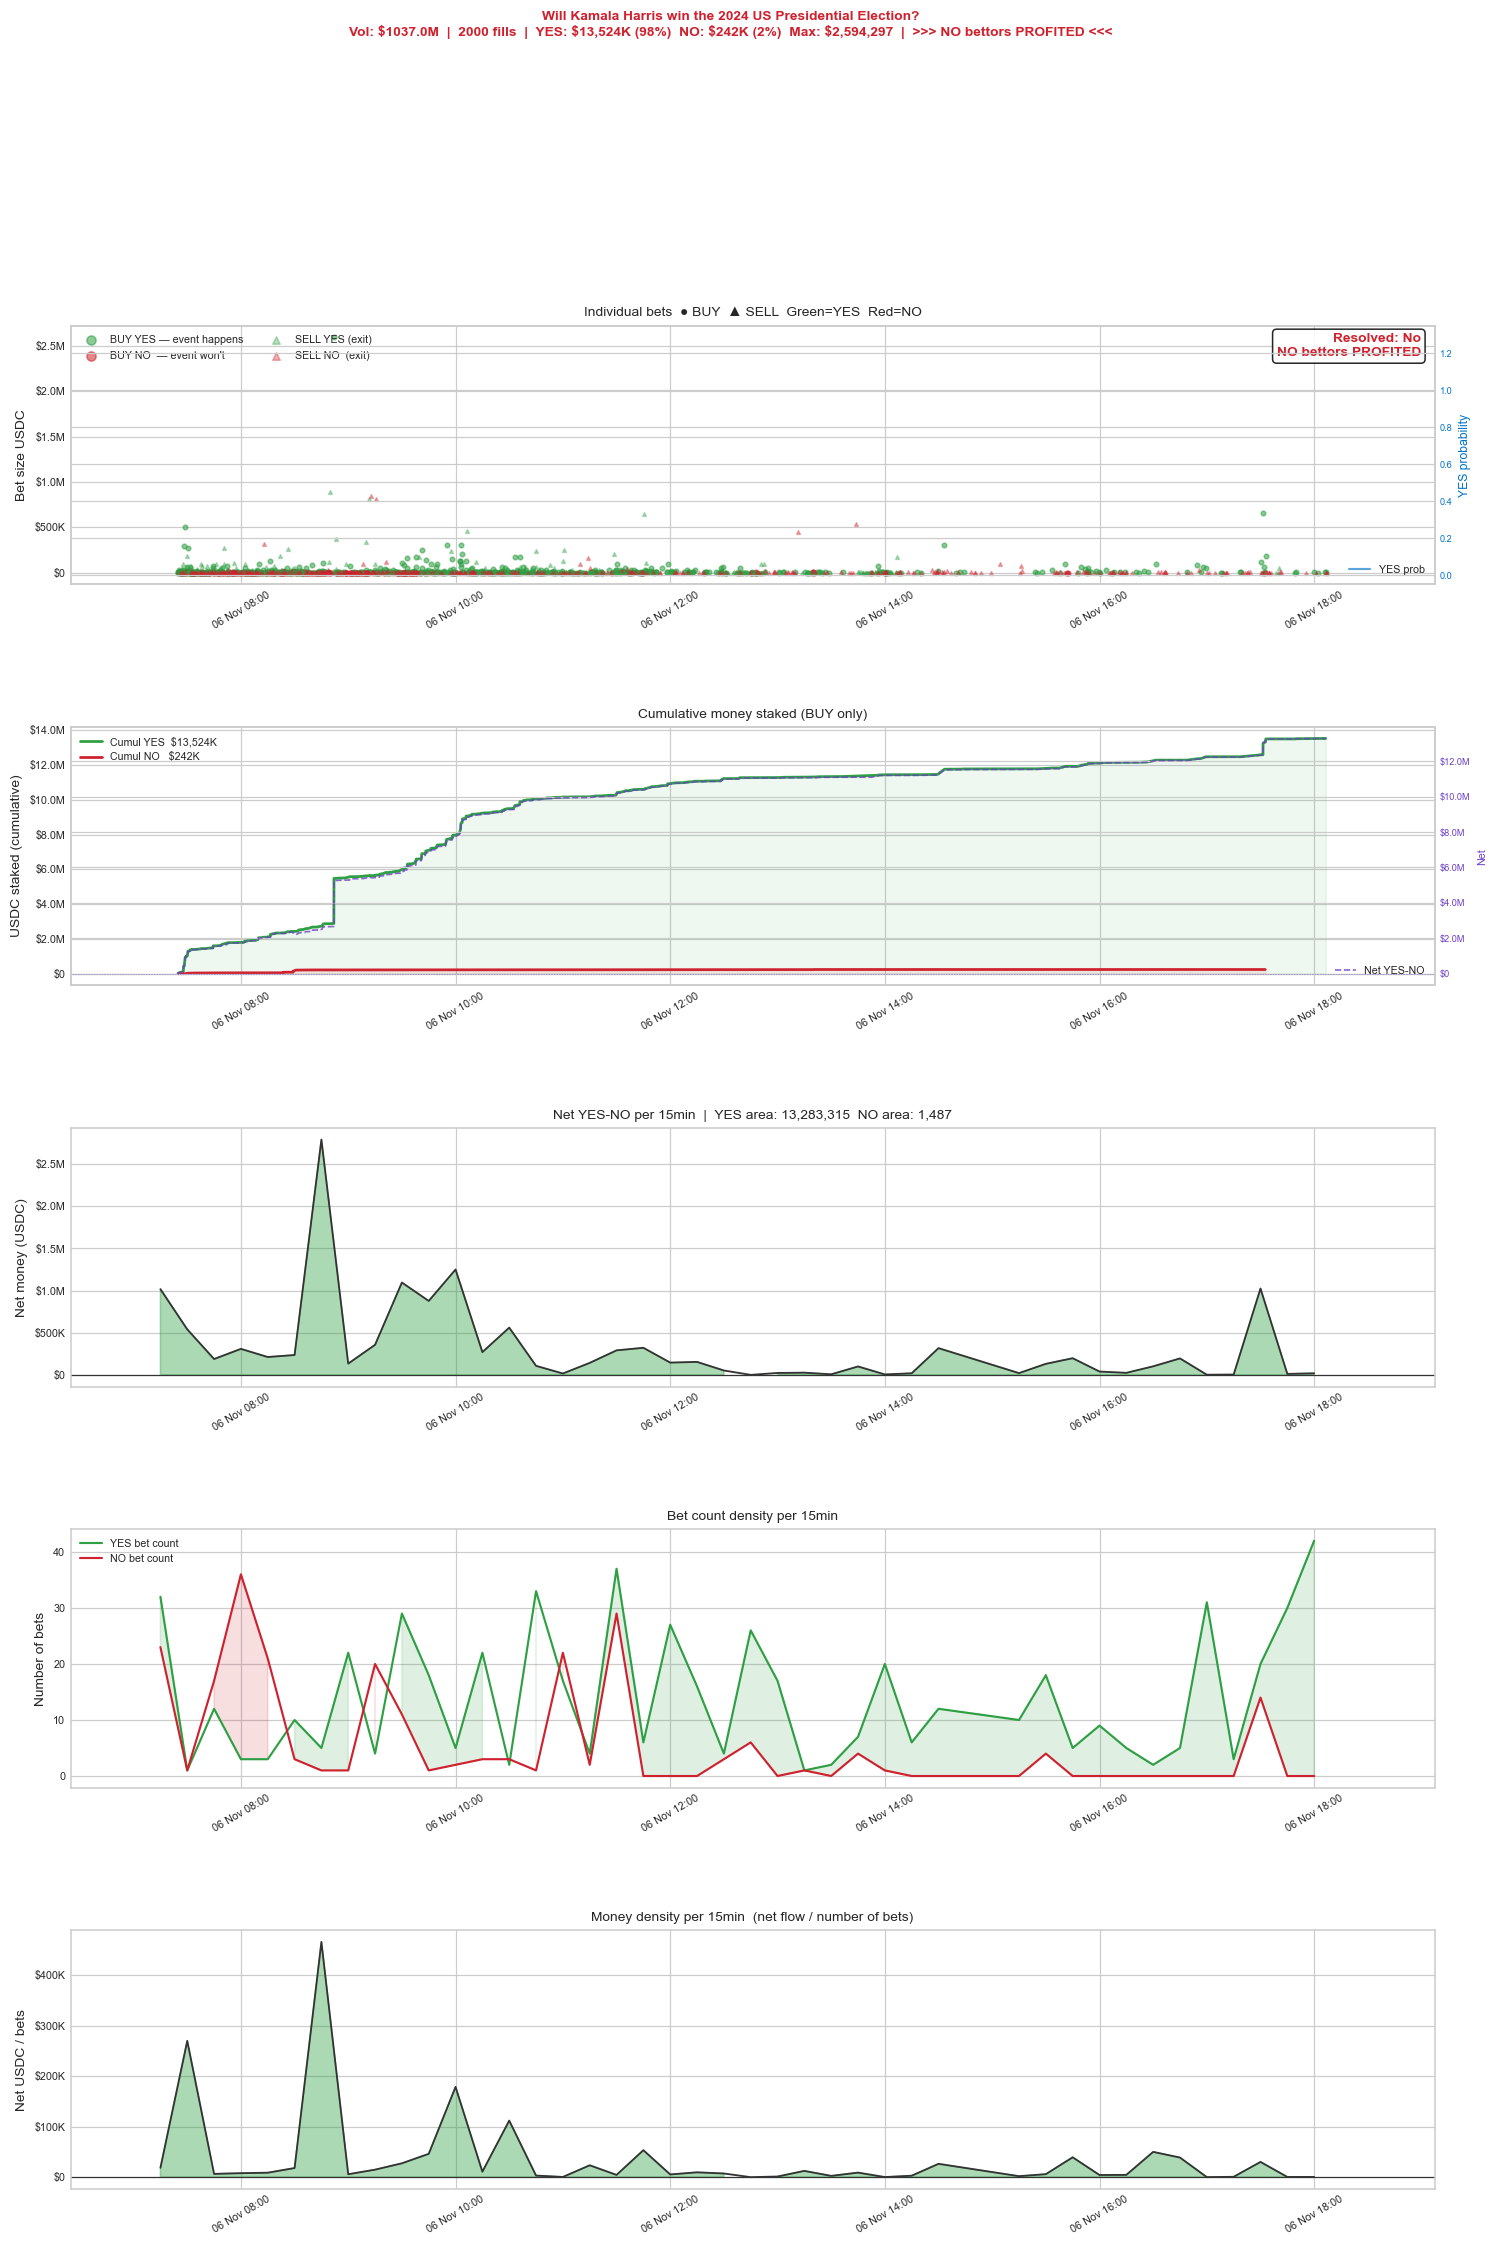

Will Donald Trump be inaugurated?
  YES area: 969,995  |  NO area: 180,891


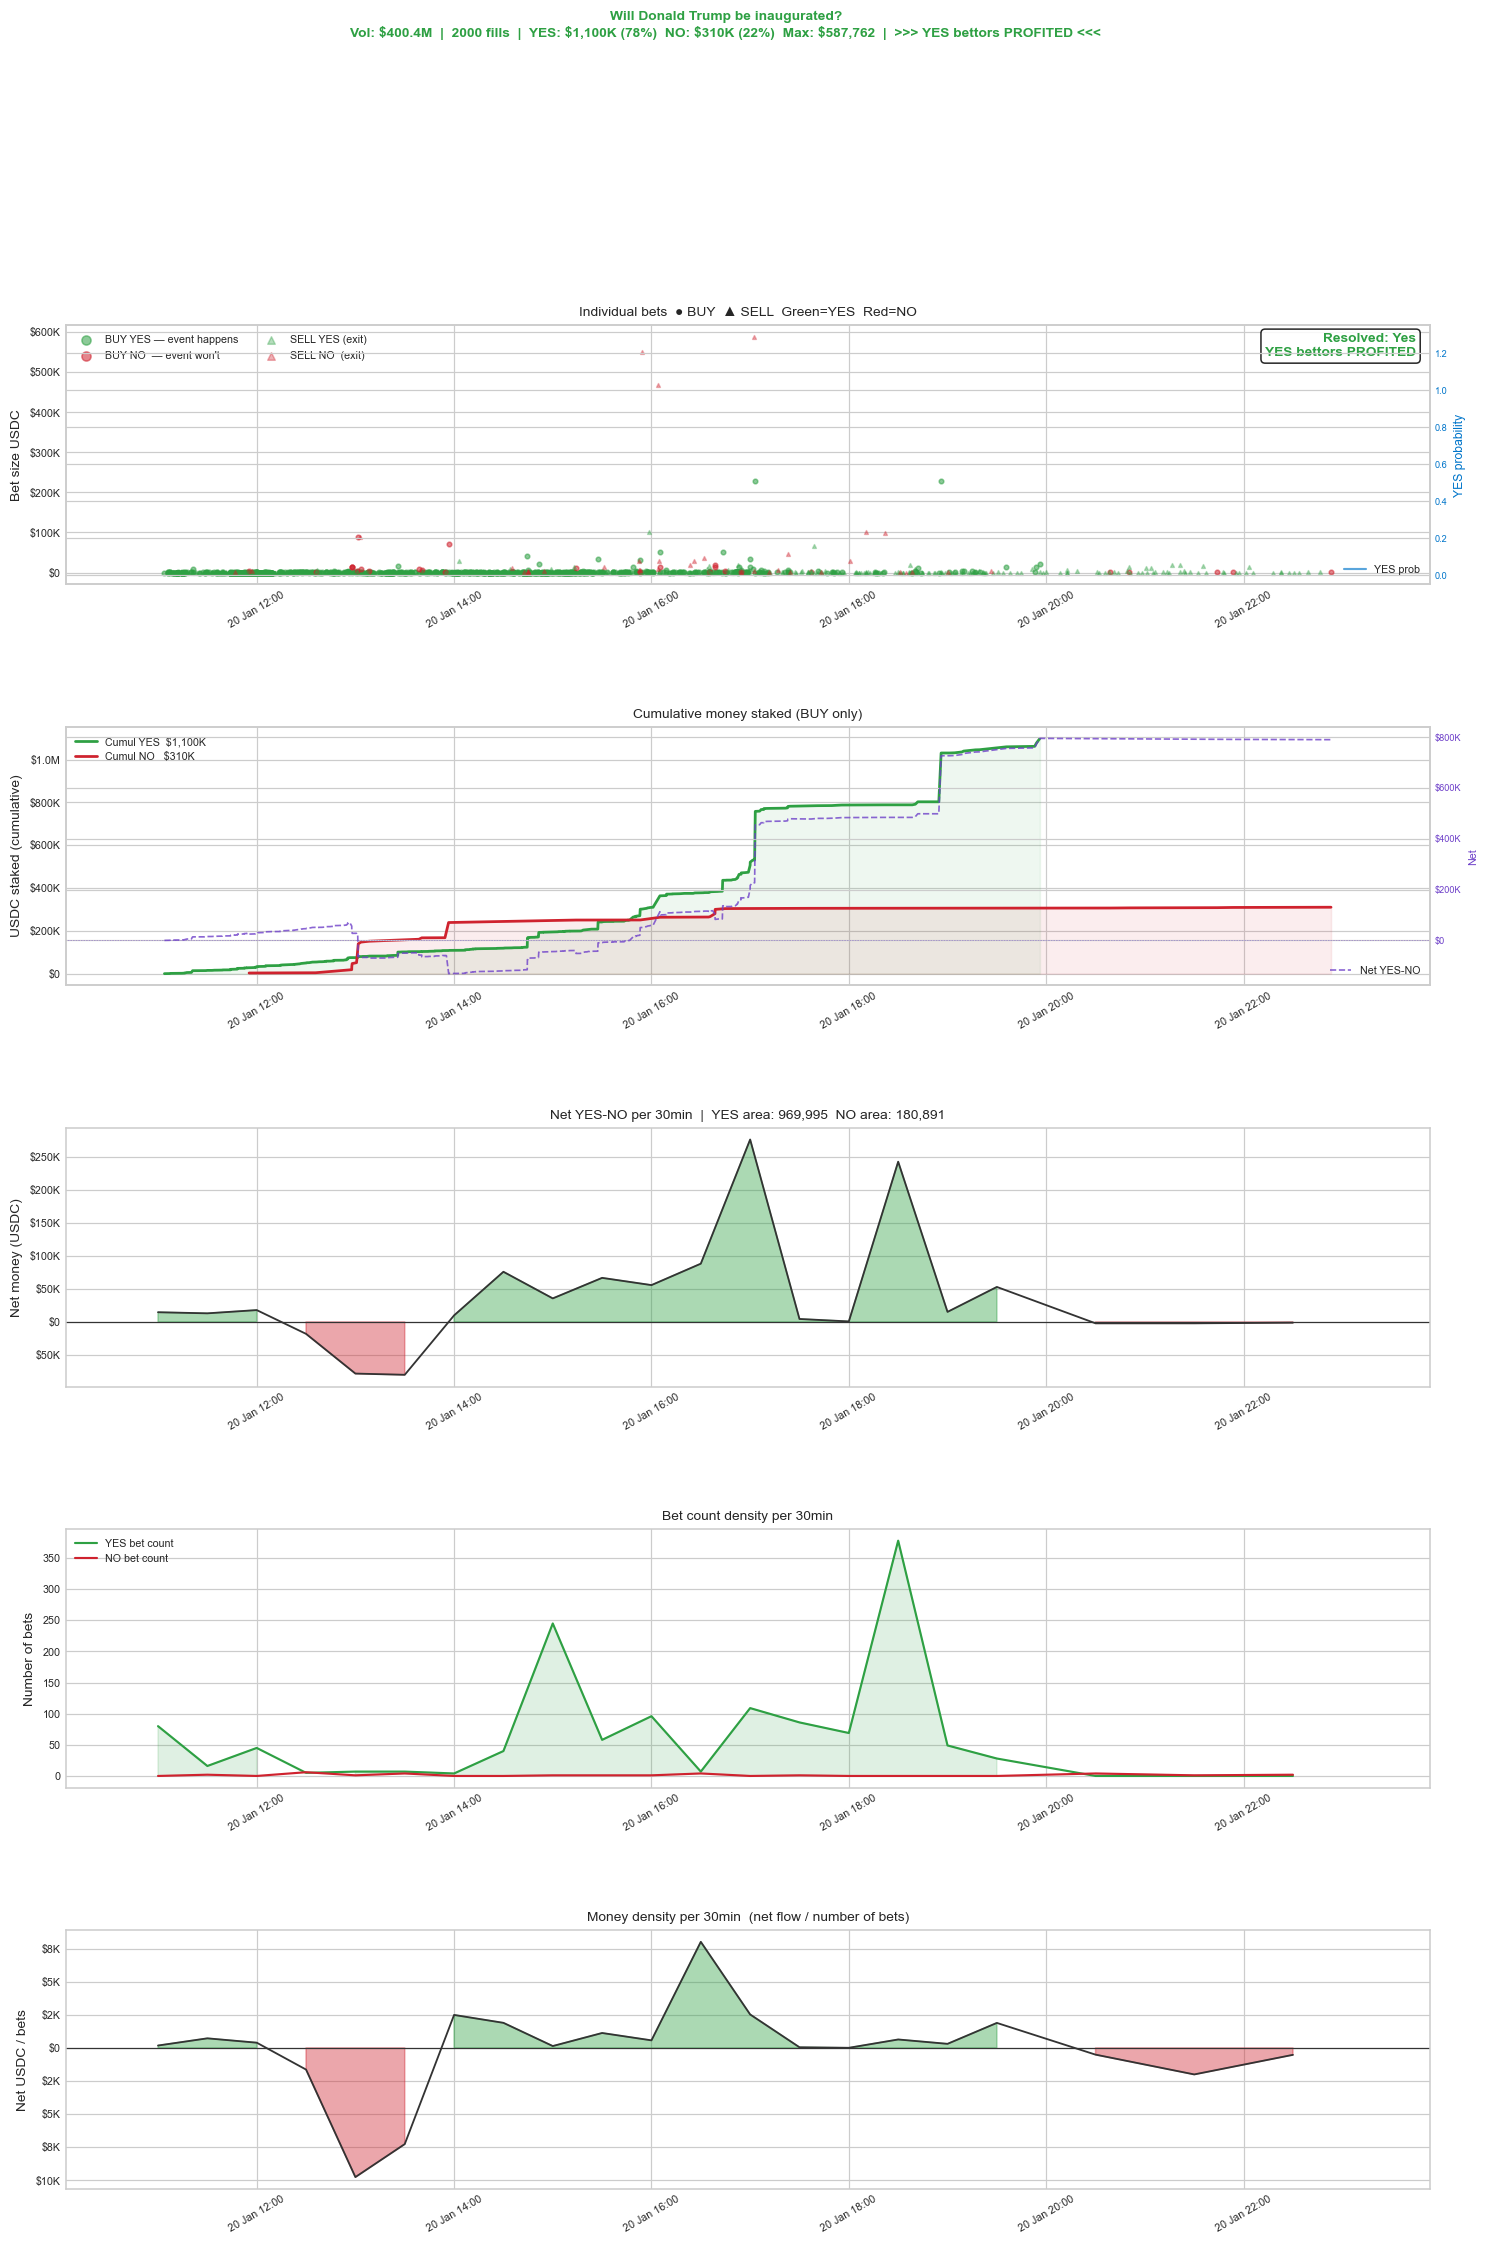

Will Nicolae Ciucă win the 2024 Romanian Presidential electi
  YES area: 30,547,930  |  NO area: 71,675


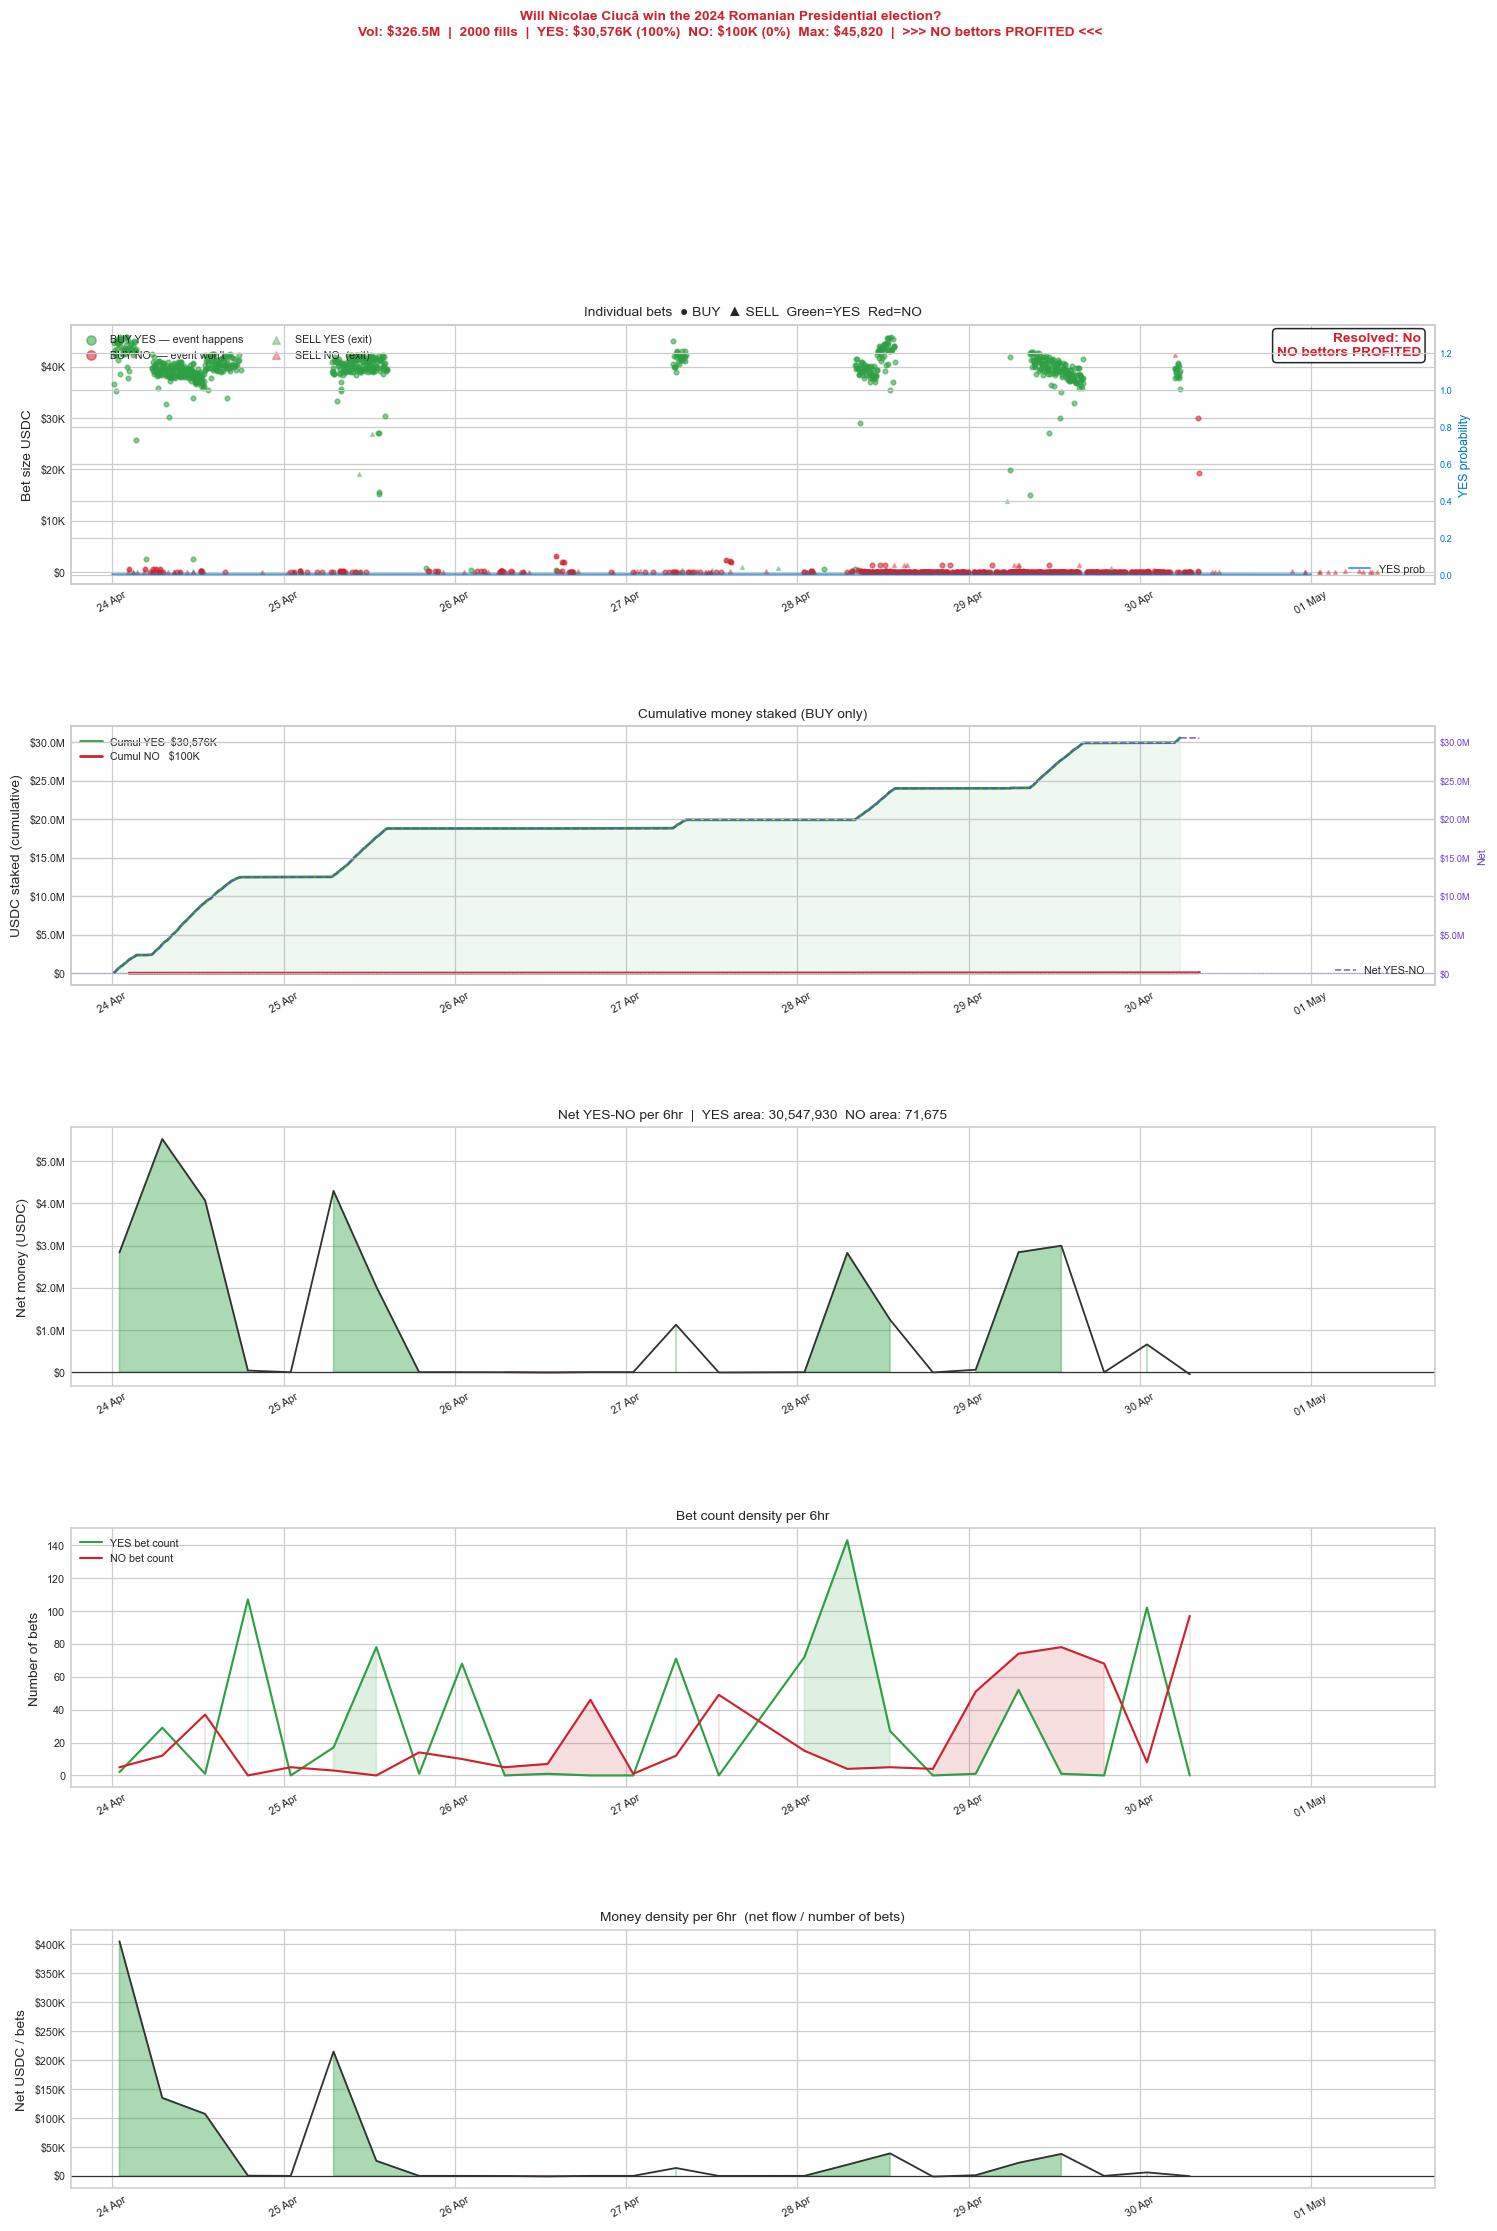

Will any other Republican Politician win the 2024 US Preside
  YES area: 21,303,816  |  NO area: 0


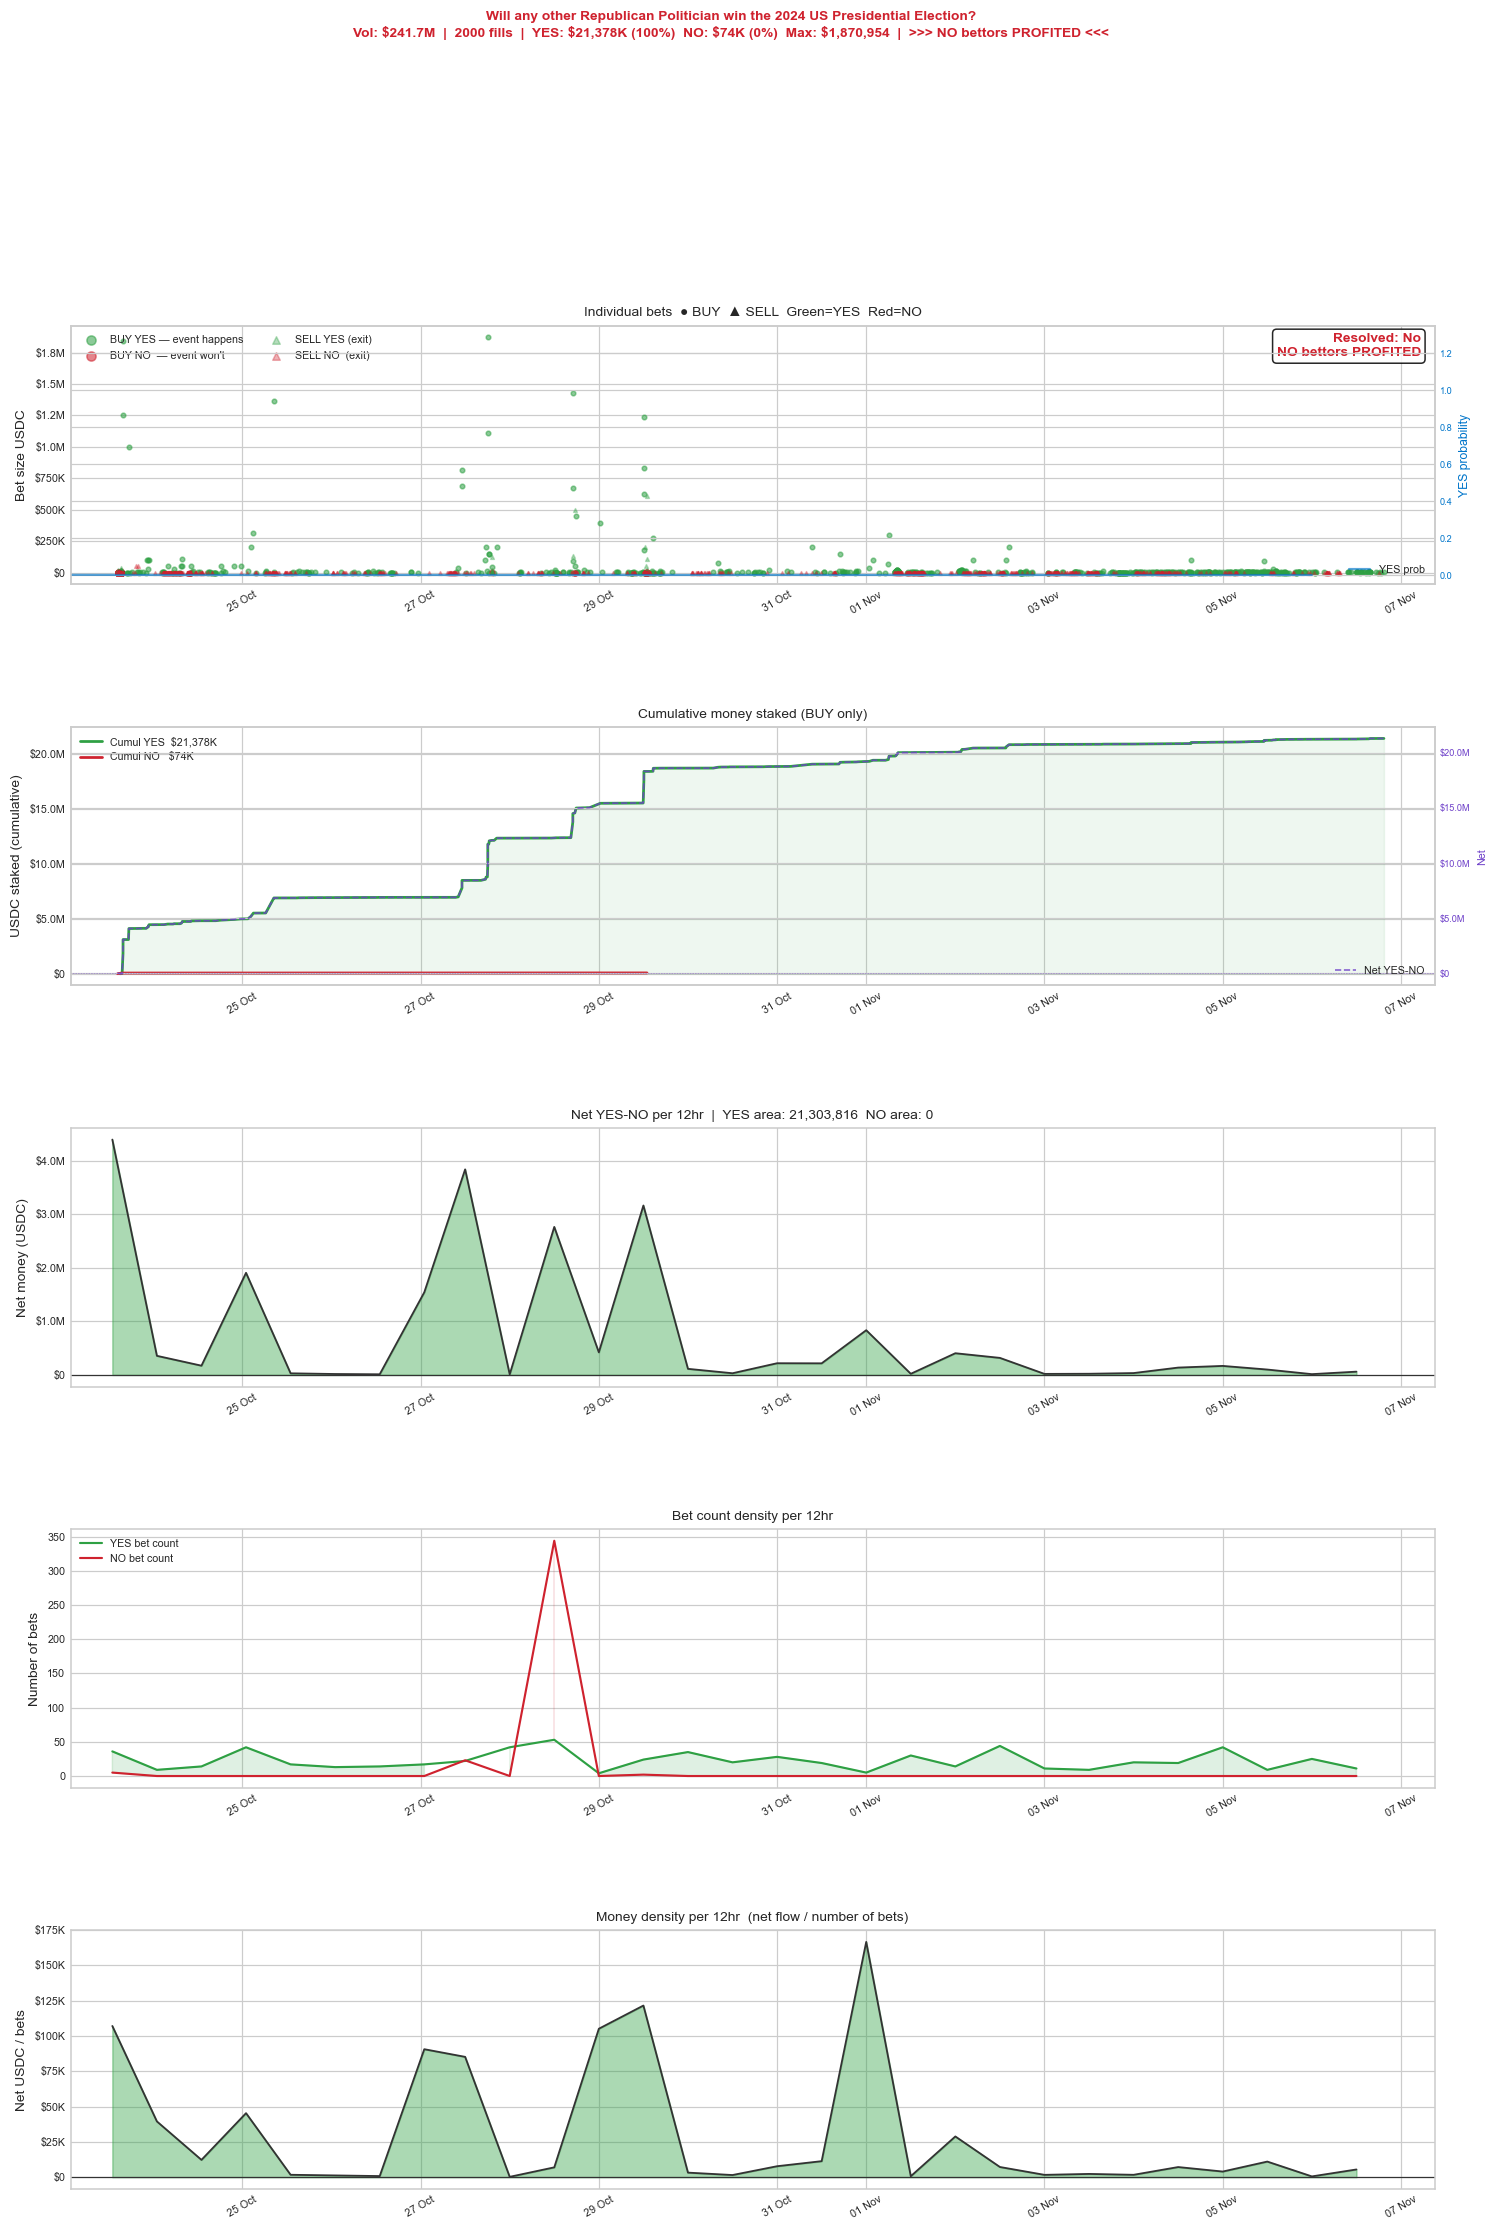

Will Michelle Obama win the 2024 US Presidential Election?
  YES area: 17,165,477  |  NO area: 0


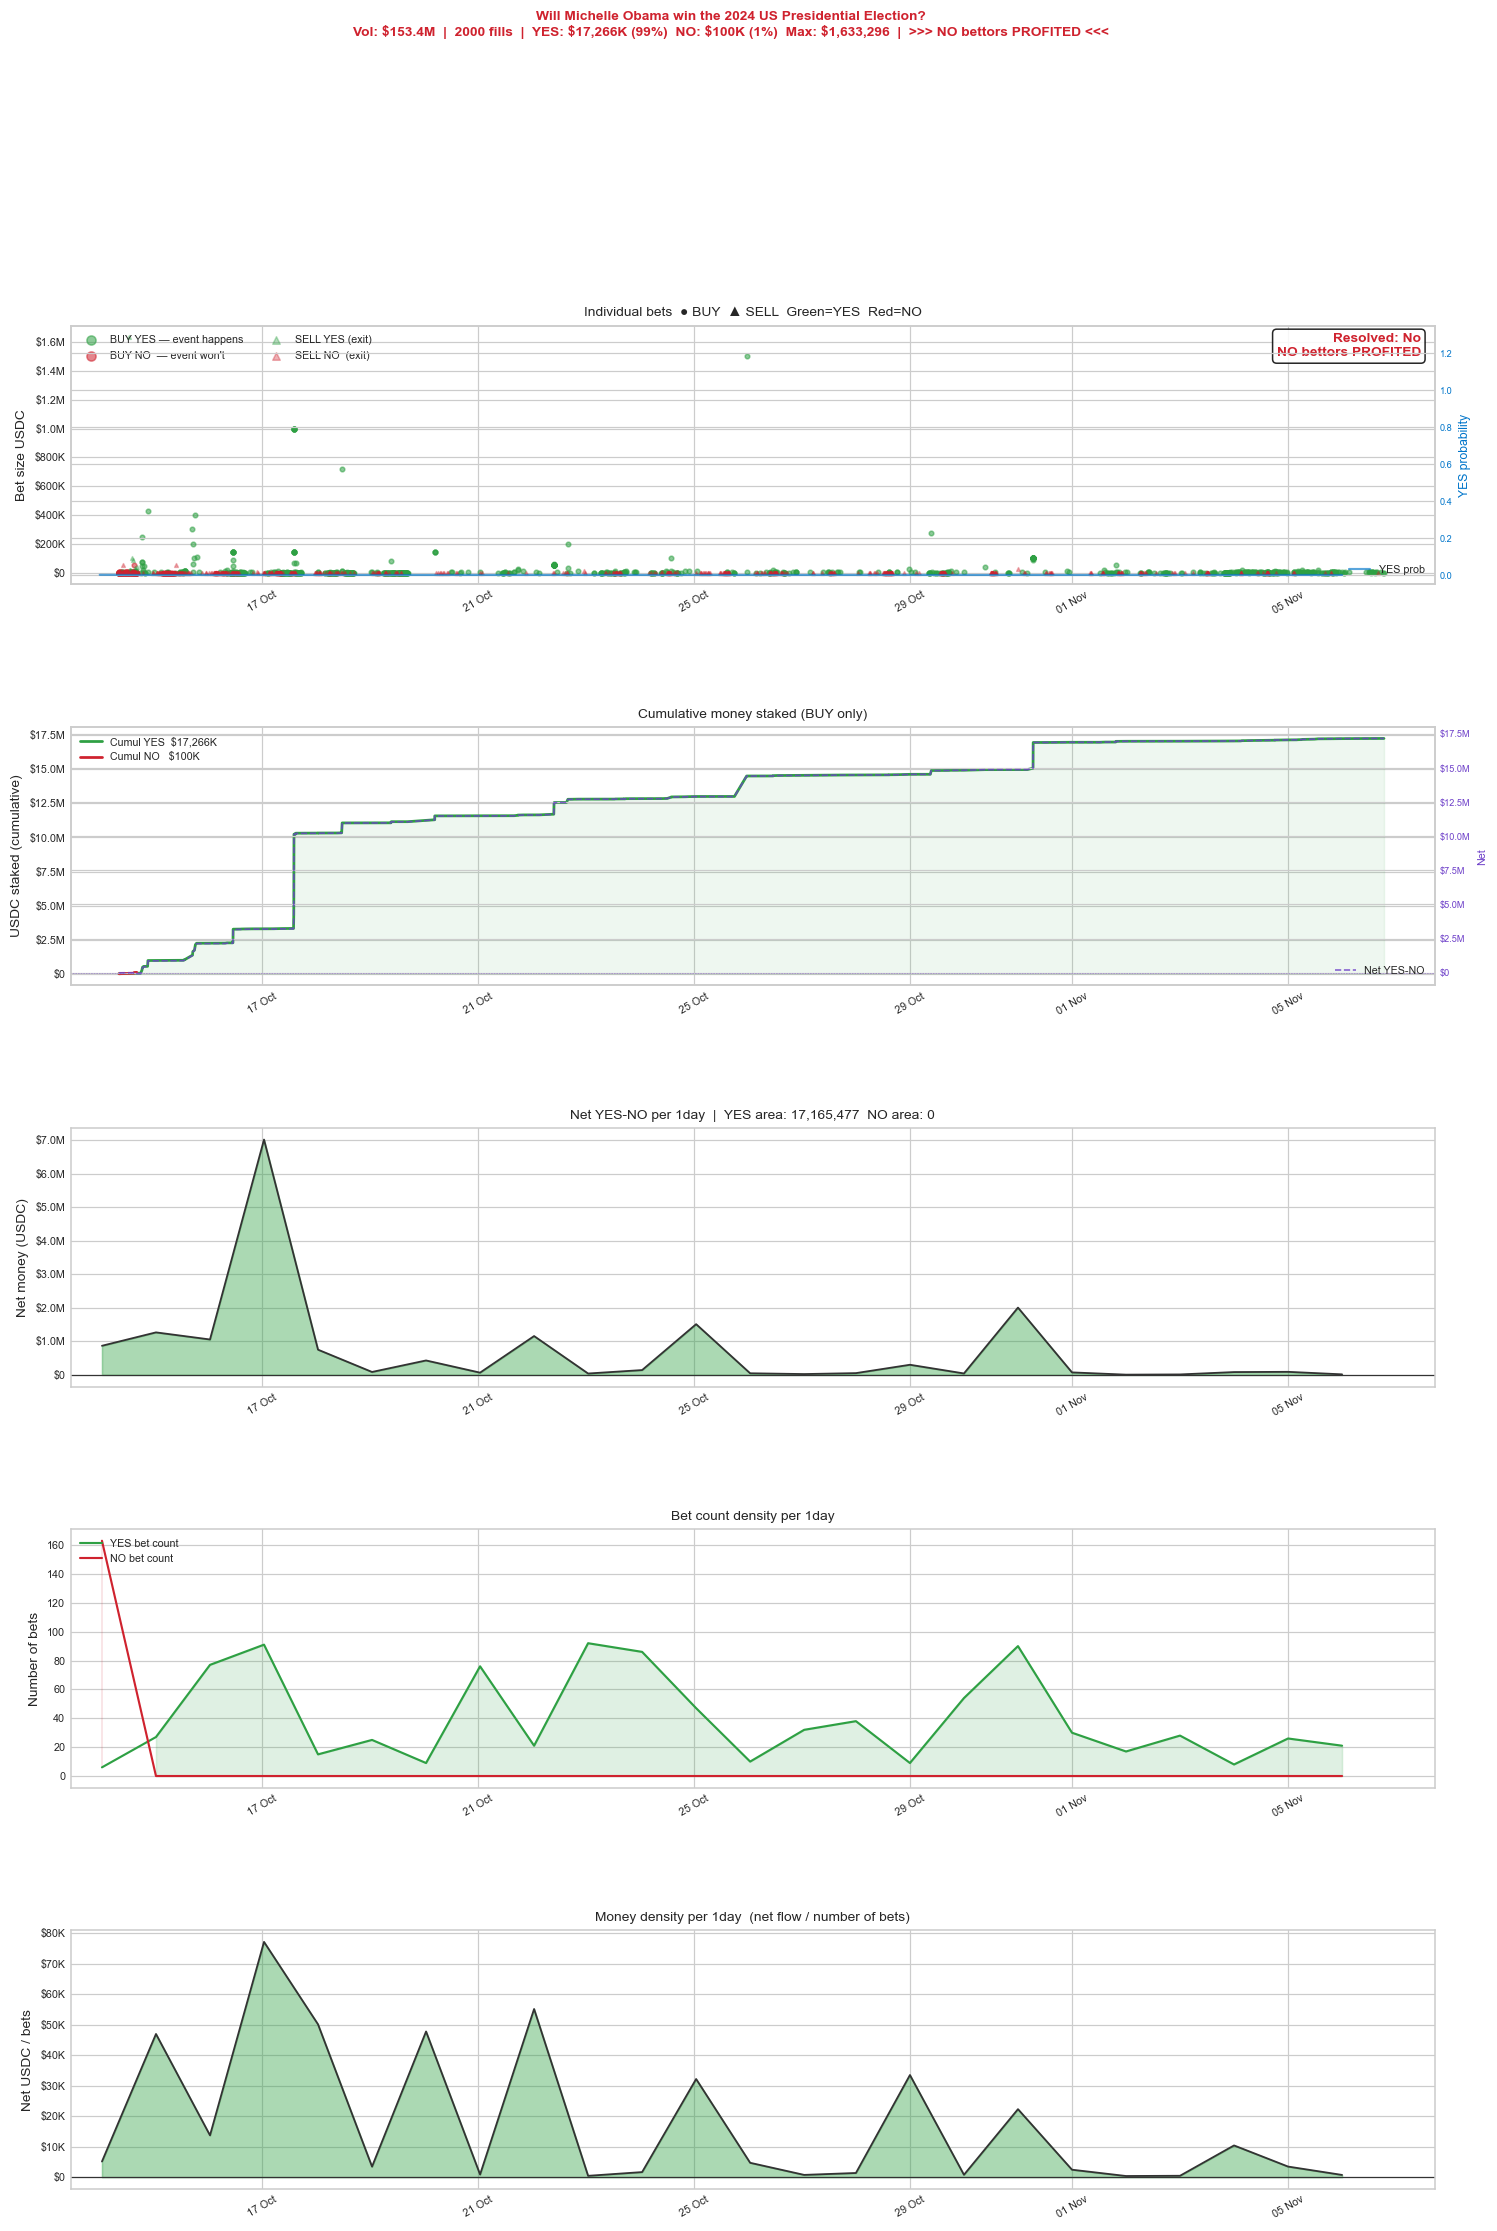

Will Zohran Mamdani win the 2025 NYC mayoral election?
  YES area: 2,331,682  |  NO area: 1,542,877


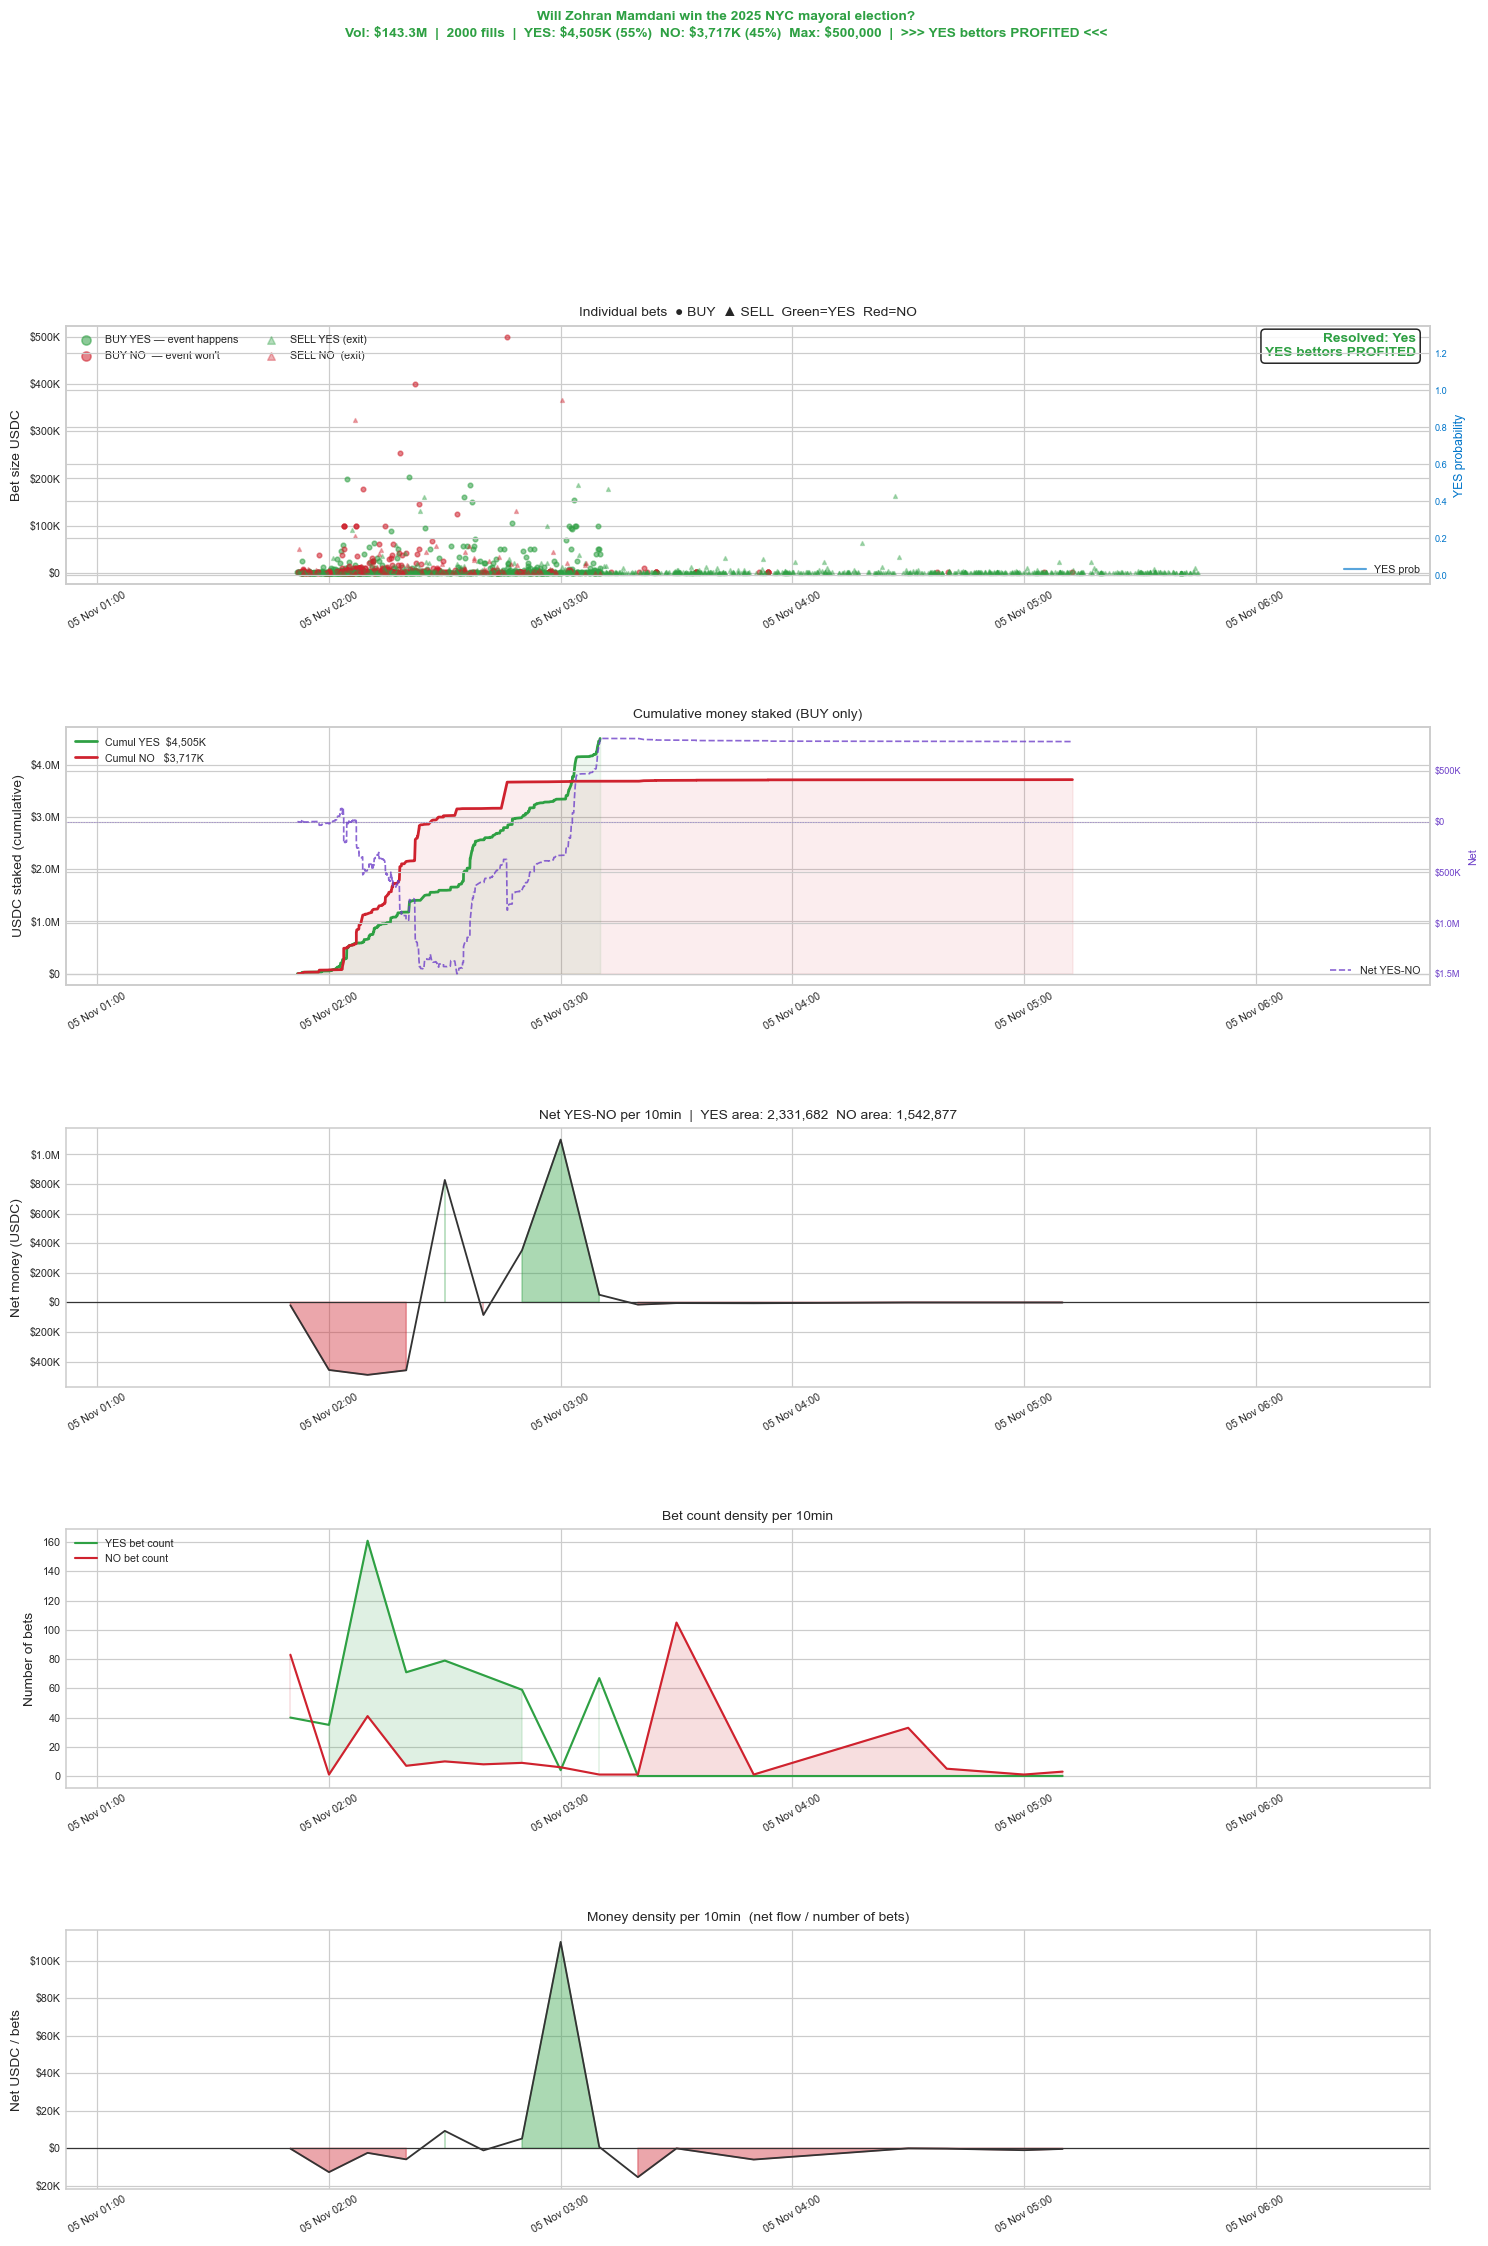

Will Robert F. Kennedy Jr. win the 2024 US Presidential Elec
  YES area: 2,520,099  |  NO area: 76,083


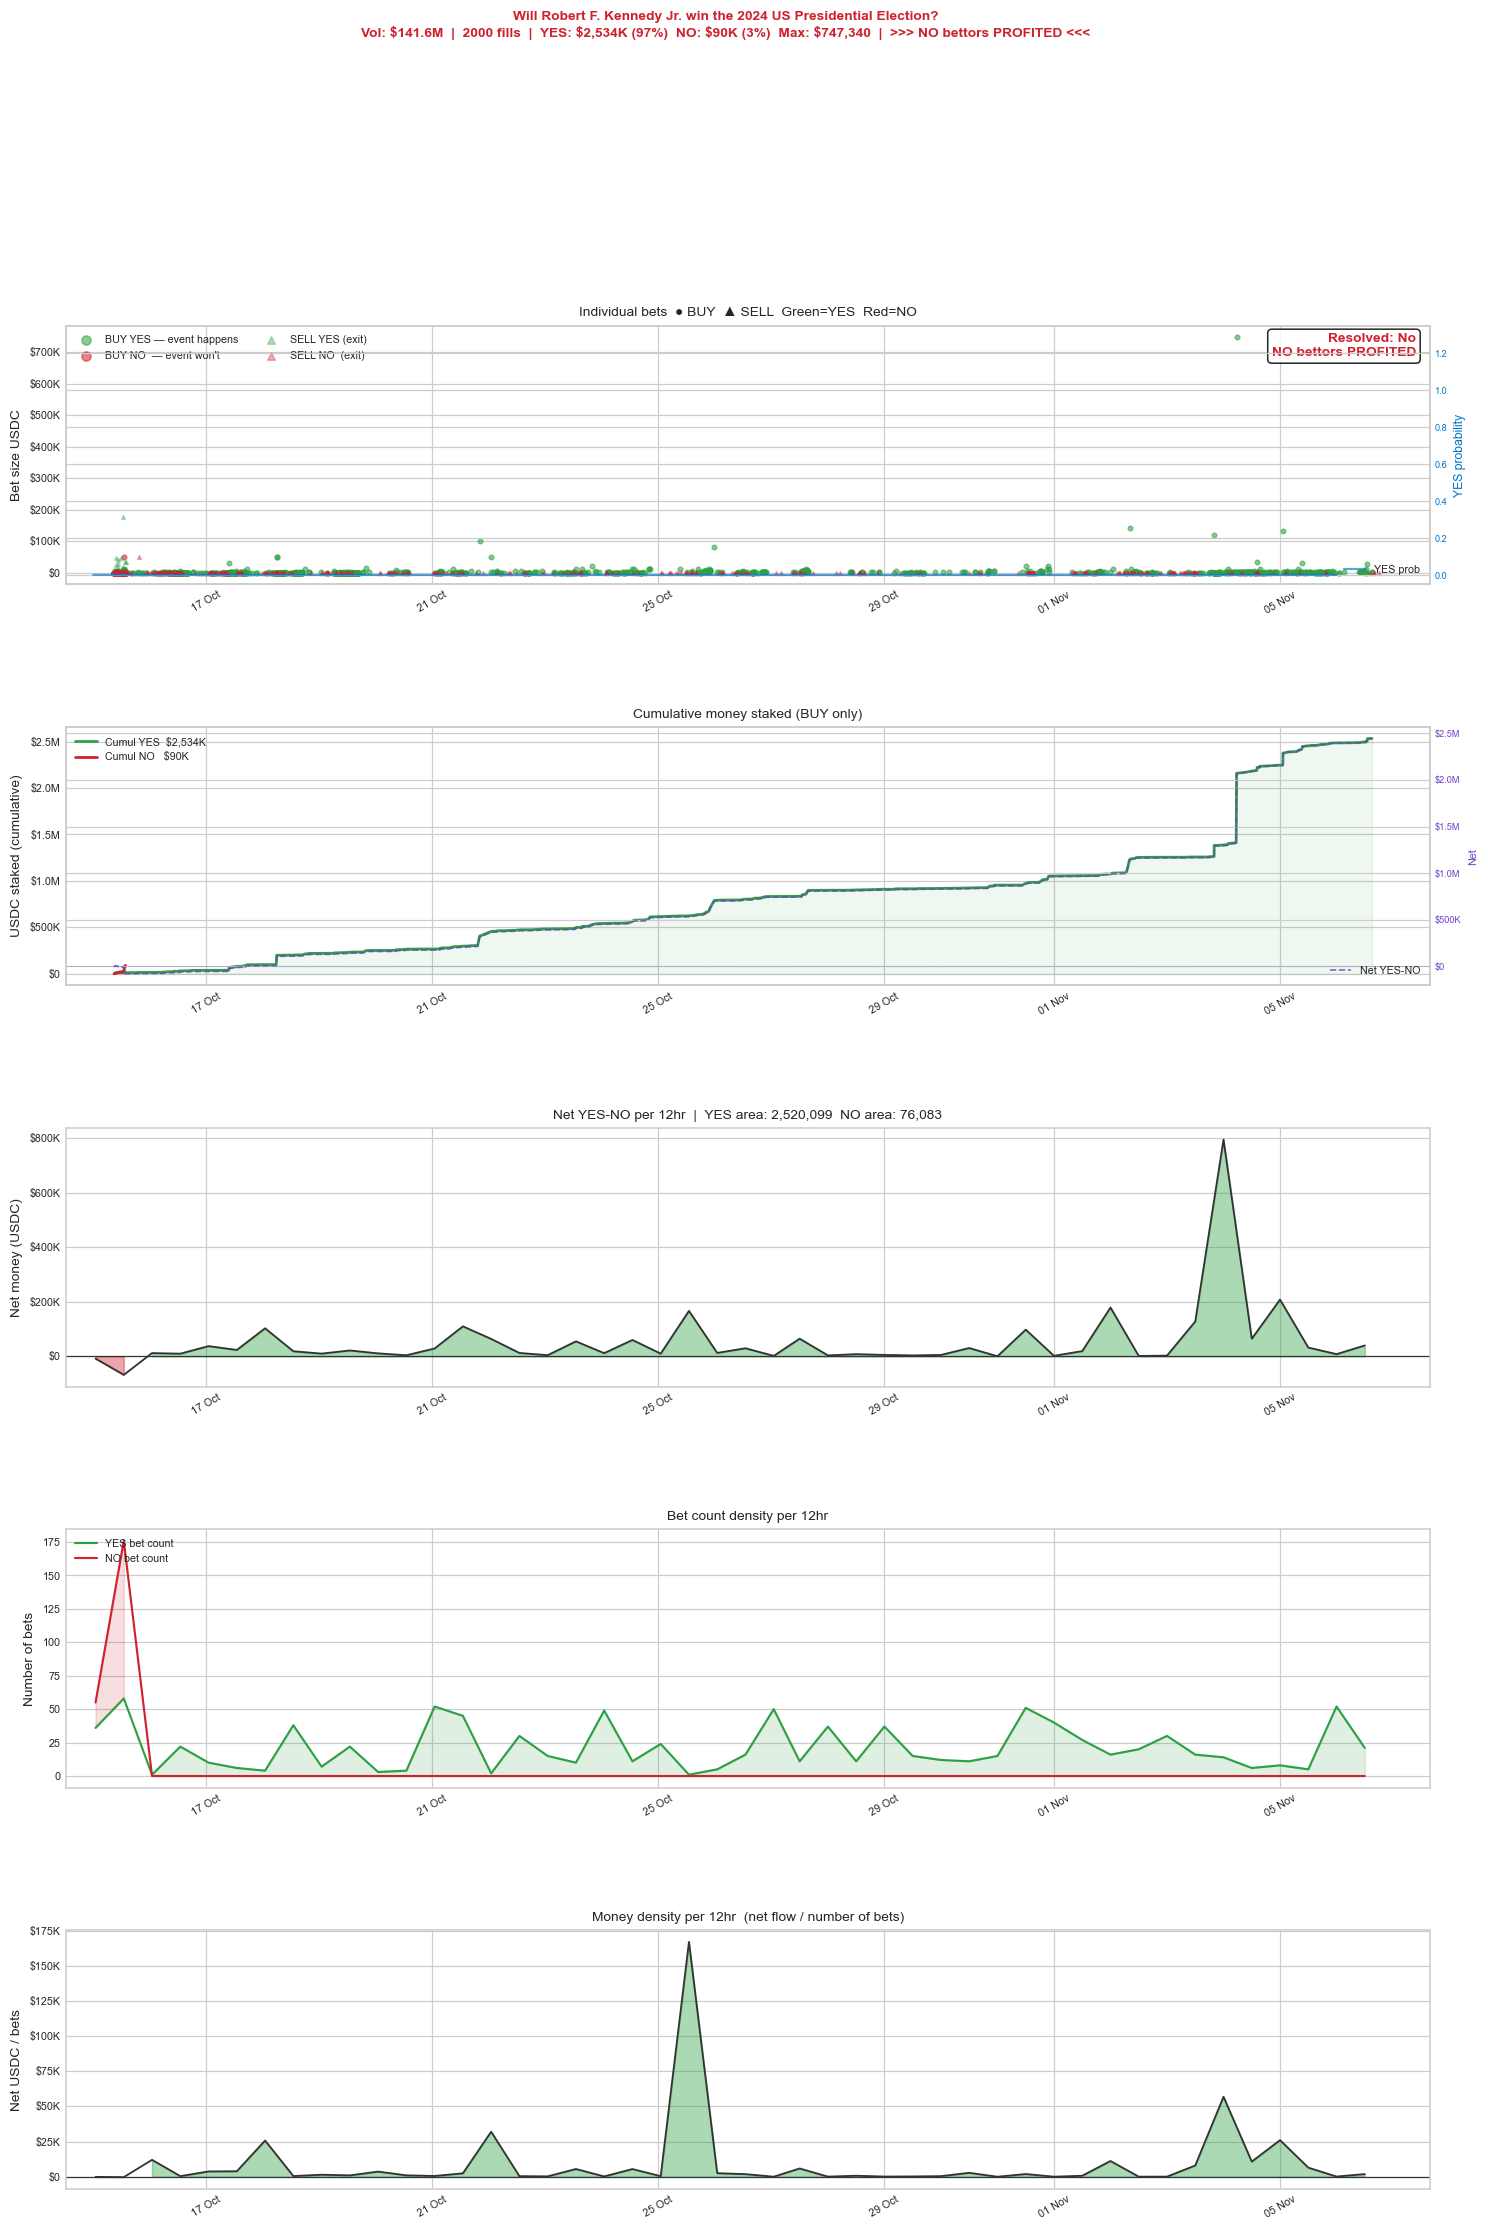

Will Trump nominate Judy Shelton as the next Fed chair?
  YES area: 7,127,369  |  NO area: 4,462,748


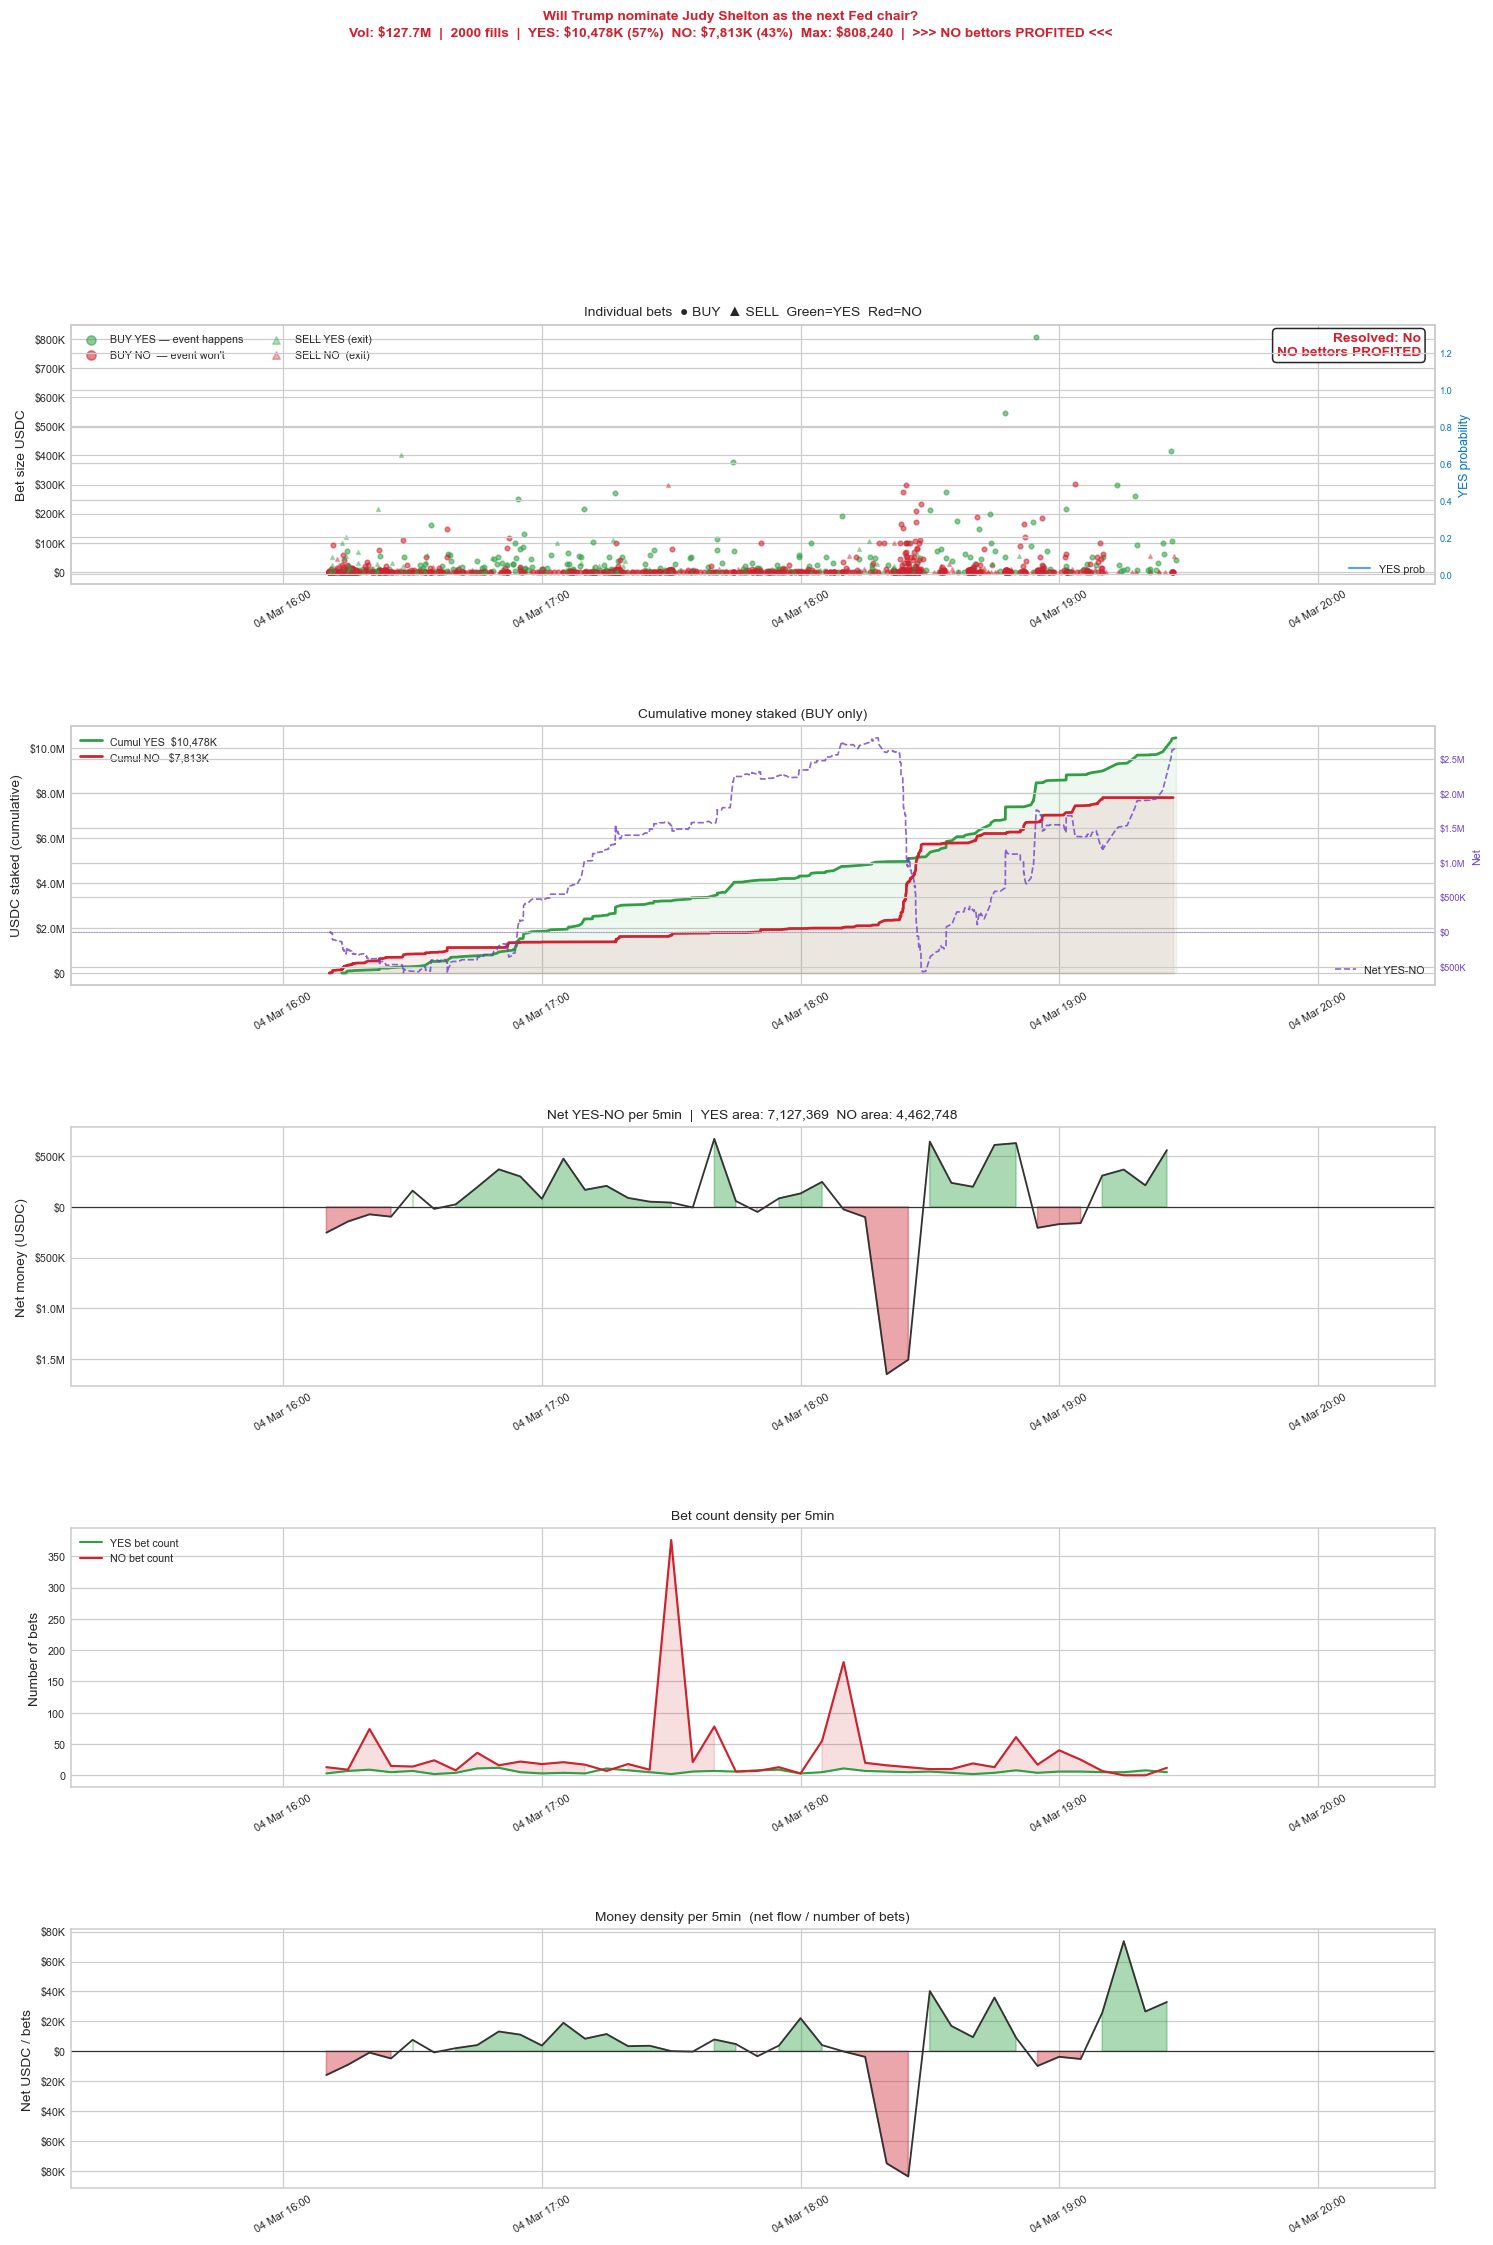

Will any other Democratic Politician win the 2024 US Preside
  YES area: 5,431,288  |  NO area: 71,697


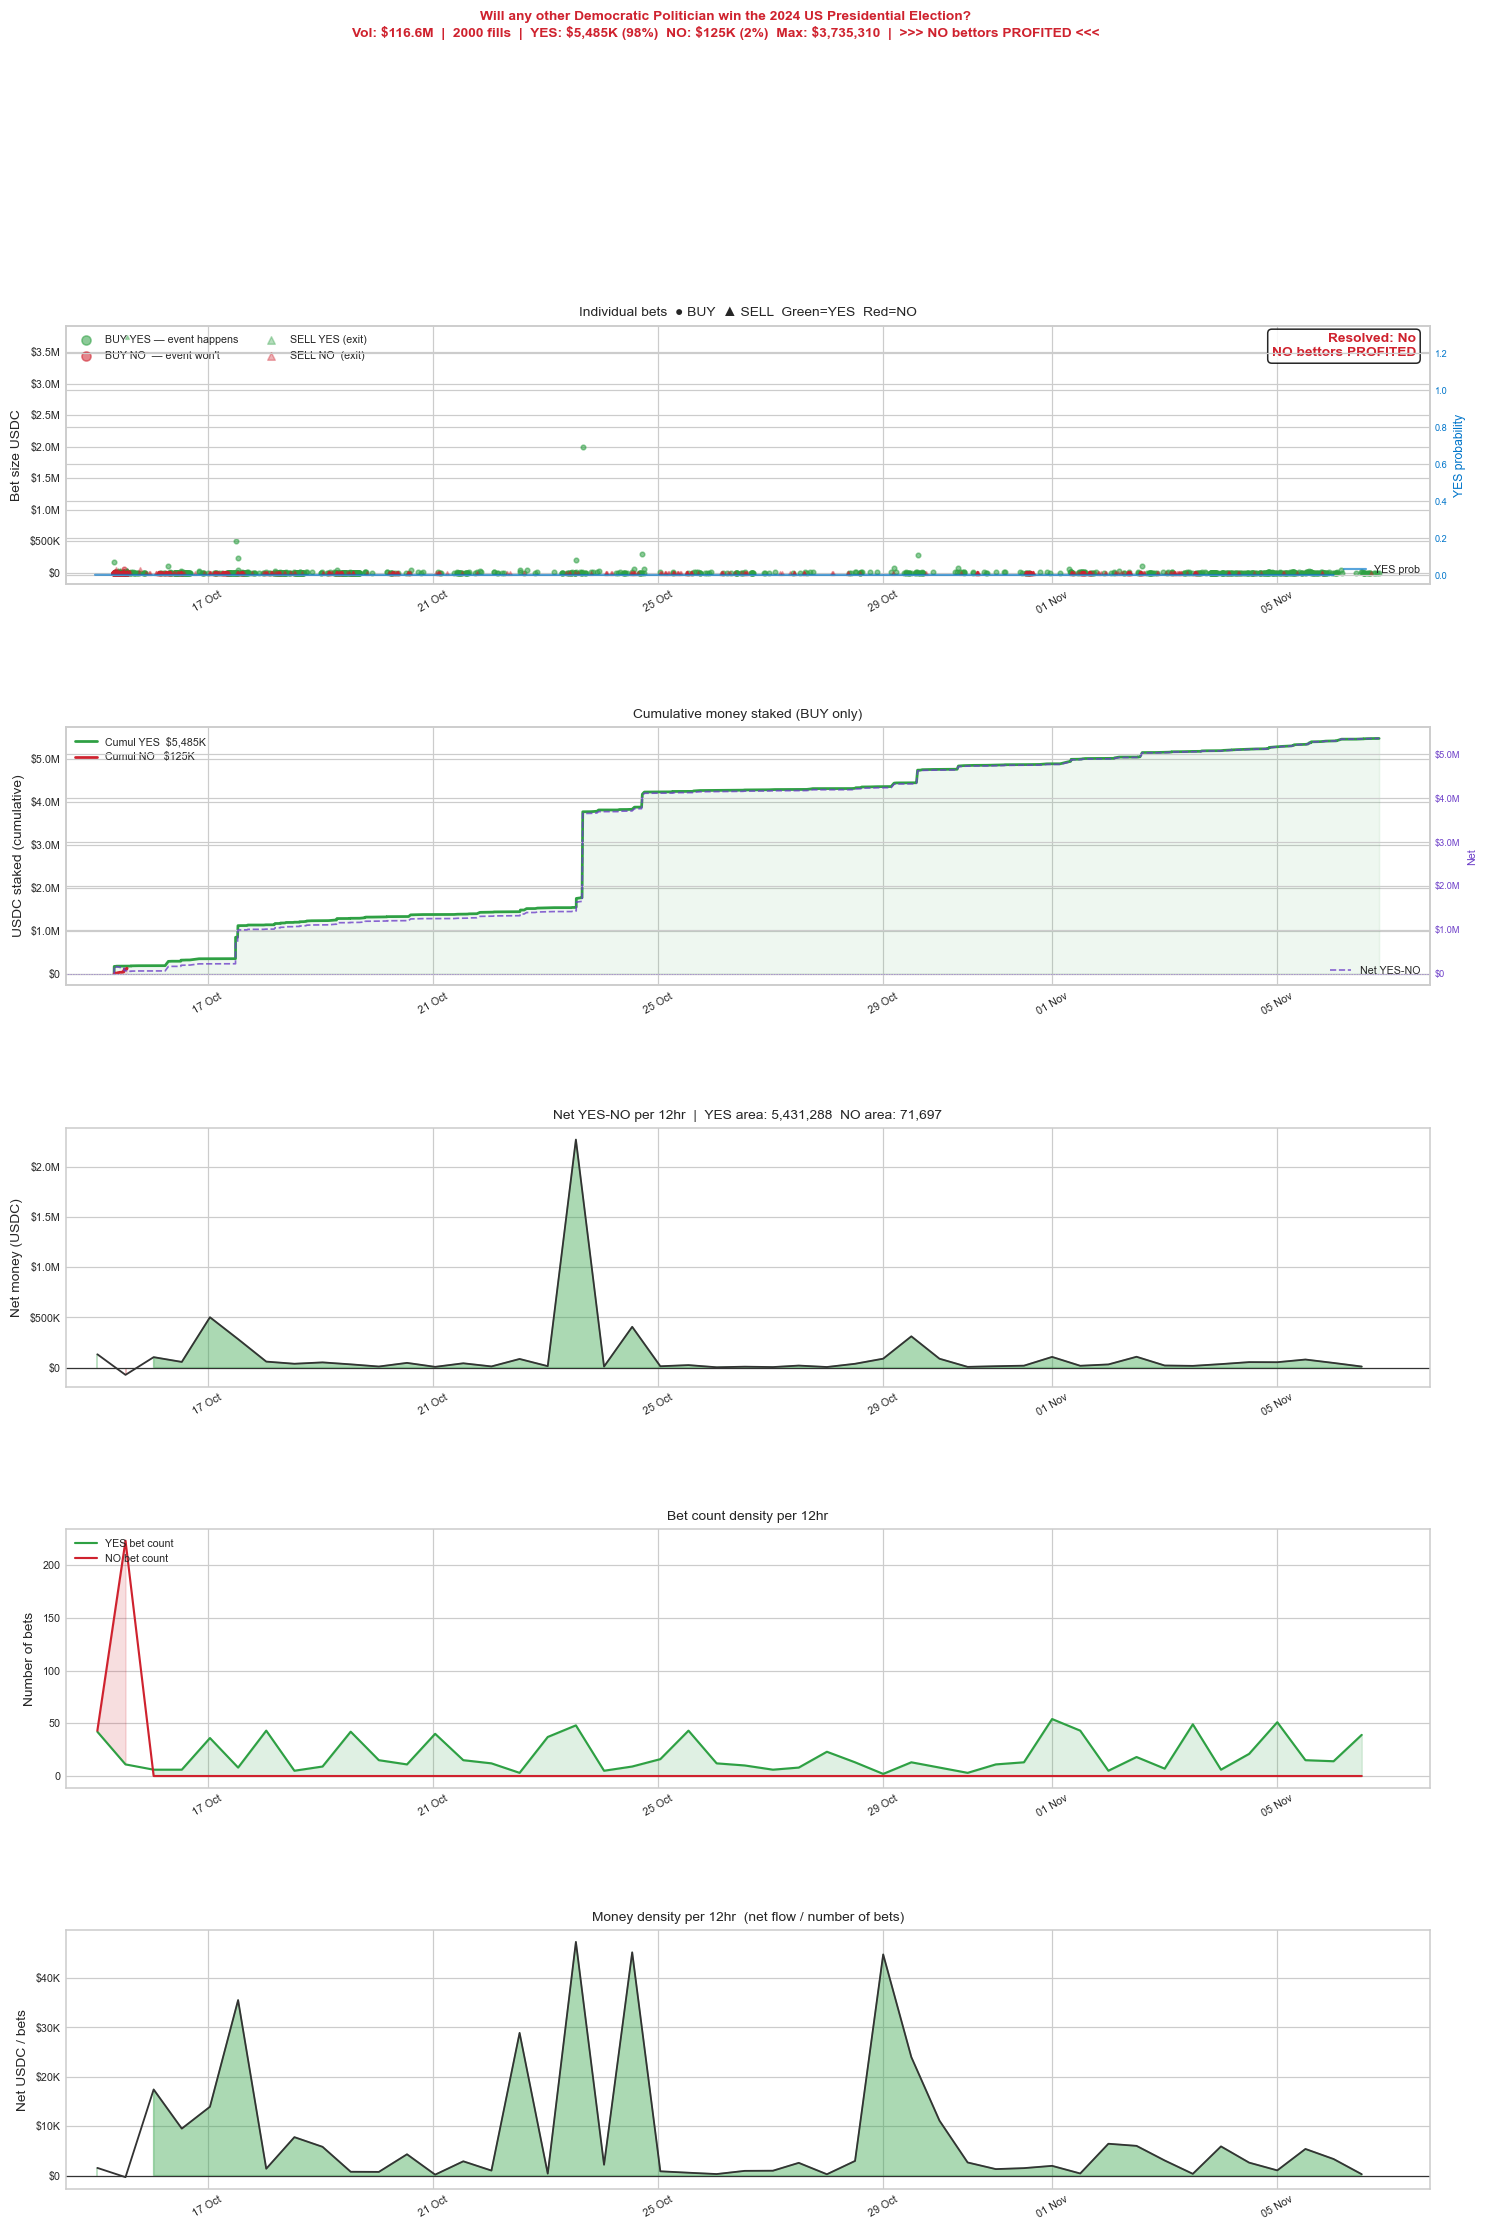

Will Frances Fitzgerald win the Irish Presidential Election?
  YES area: 114,497,039  |  NO area: 26,439


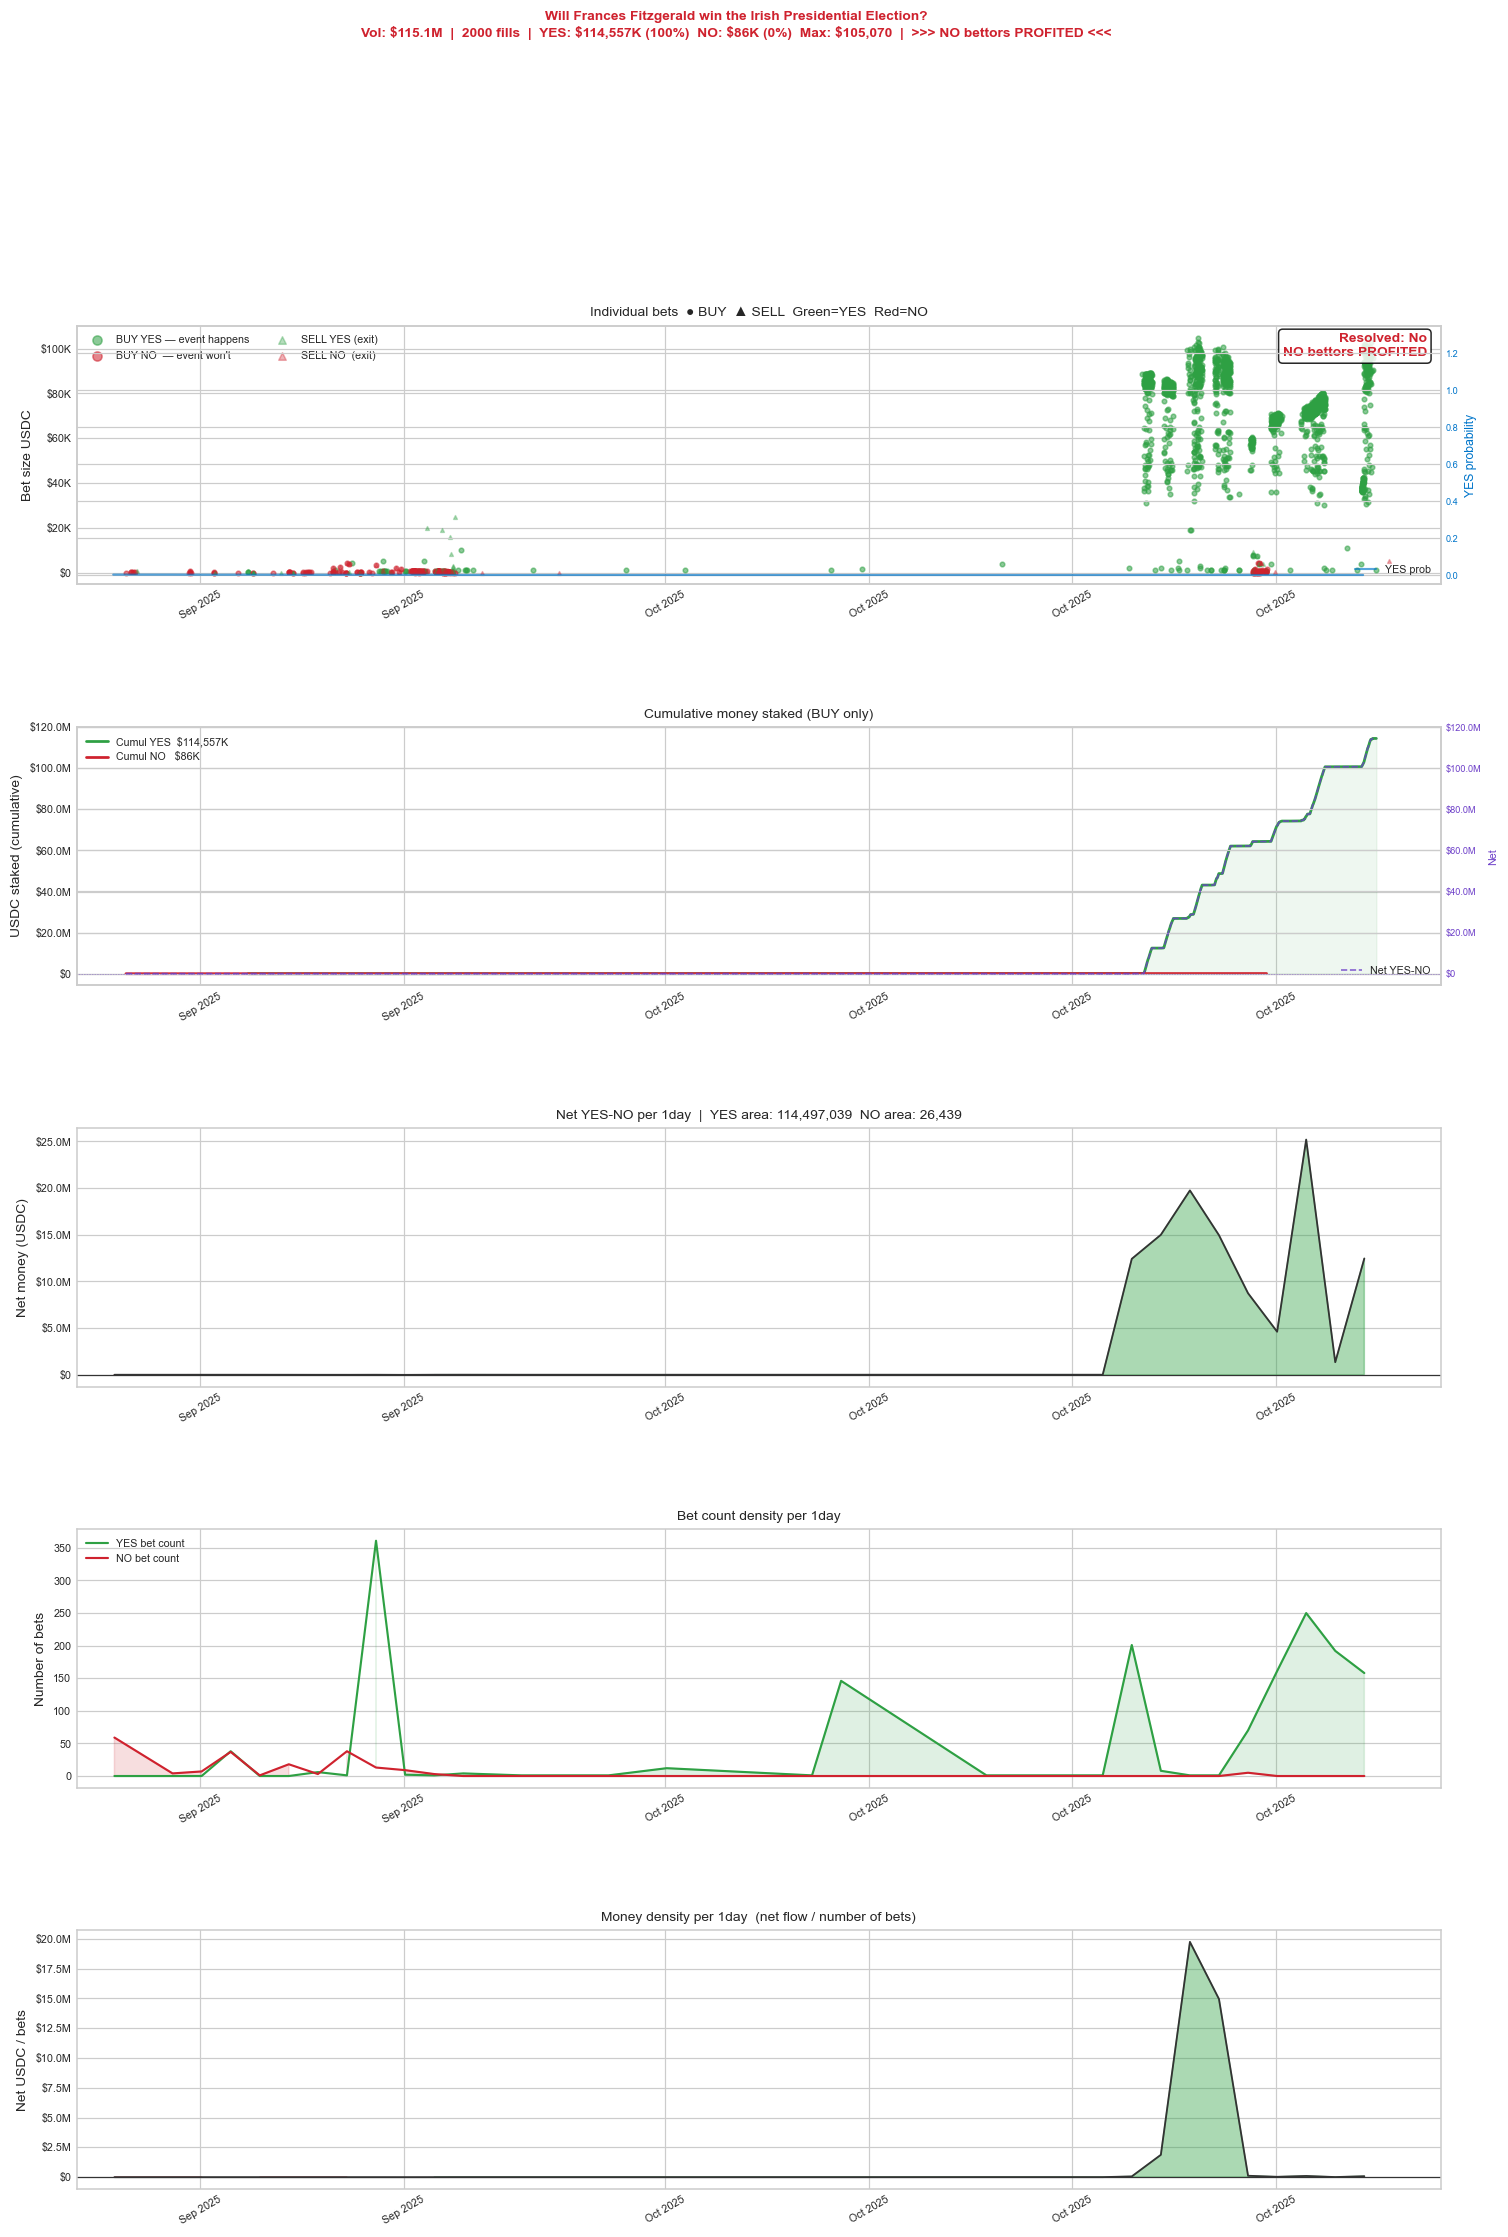

Will Nikki Haley win the 2024 US Presidential Election?
  YES area: 2,191,068  |  NO area: 0


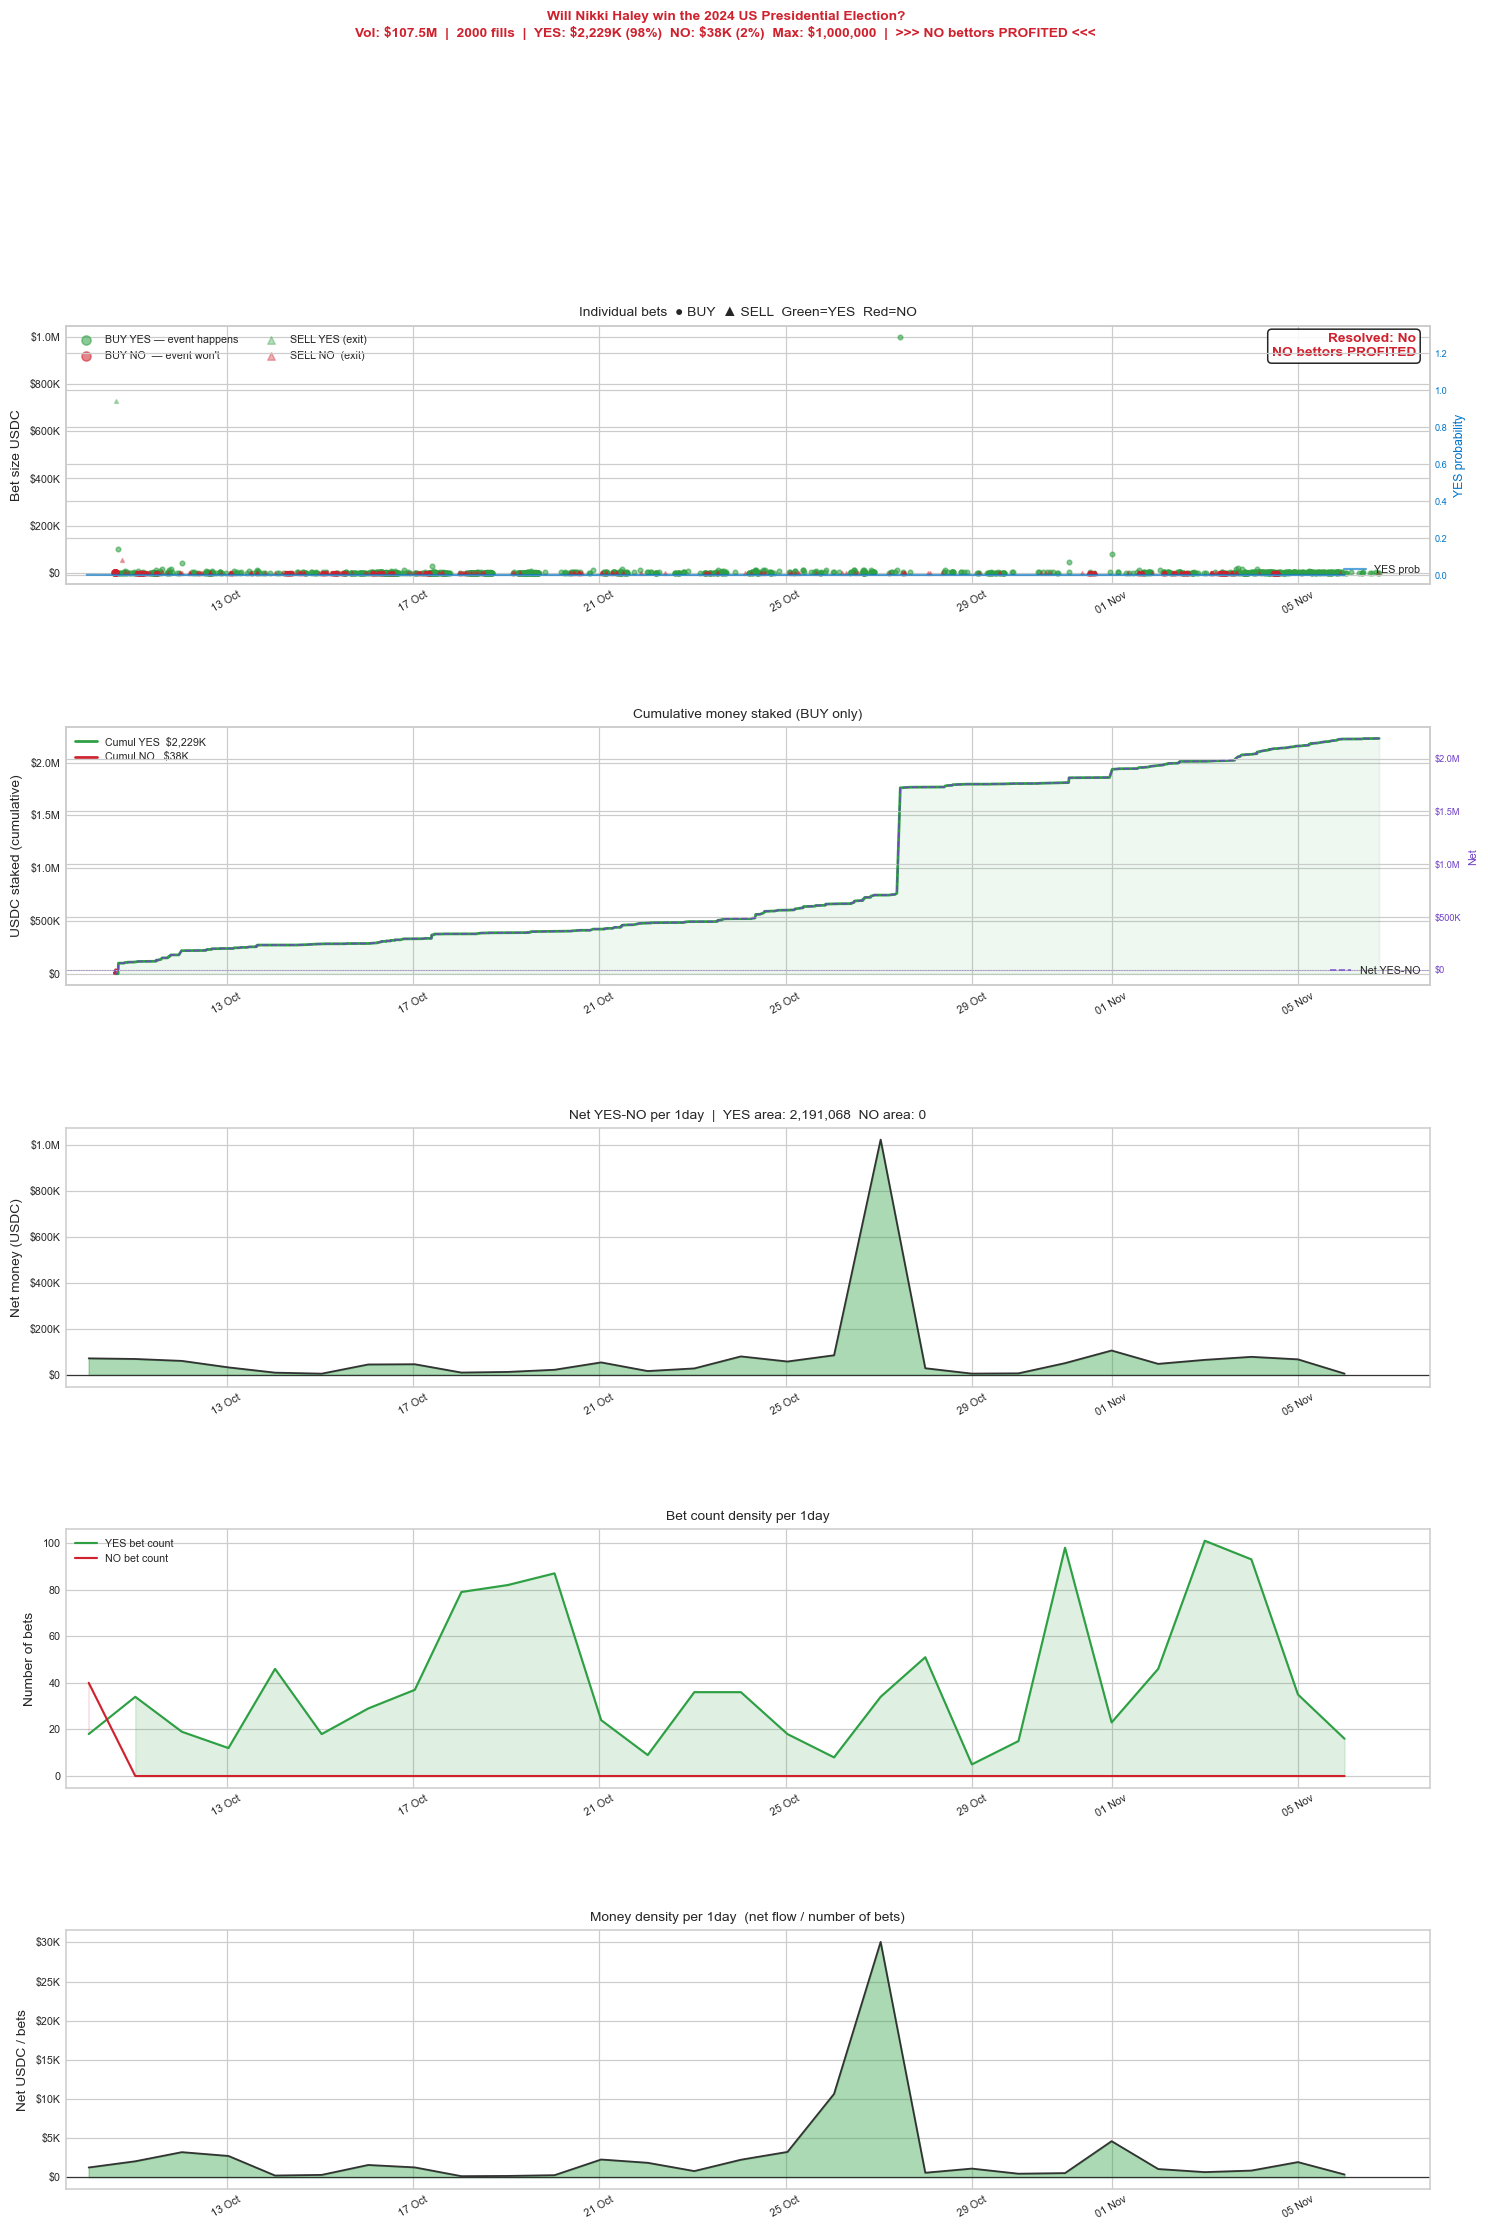

Will Hillary Clinton win the 2024 US Presidential Election?
  YES area: 5,641,371  |  NO area: 549,446


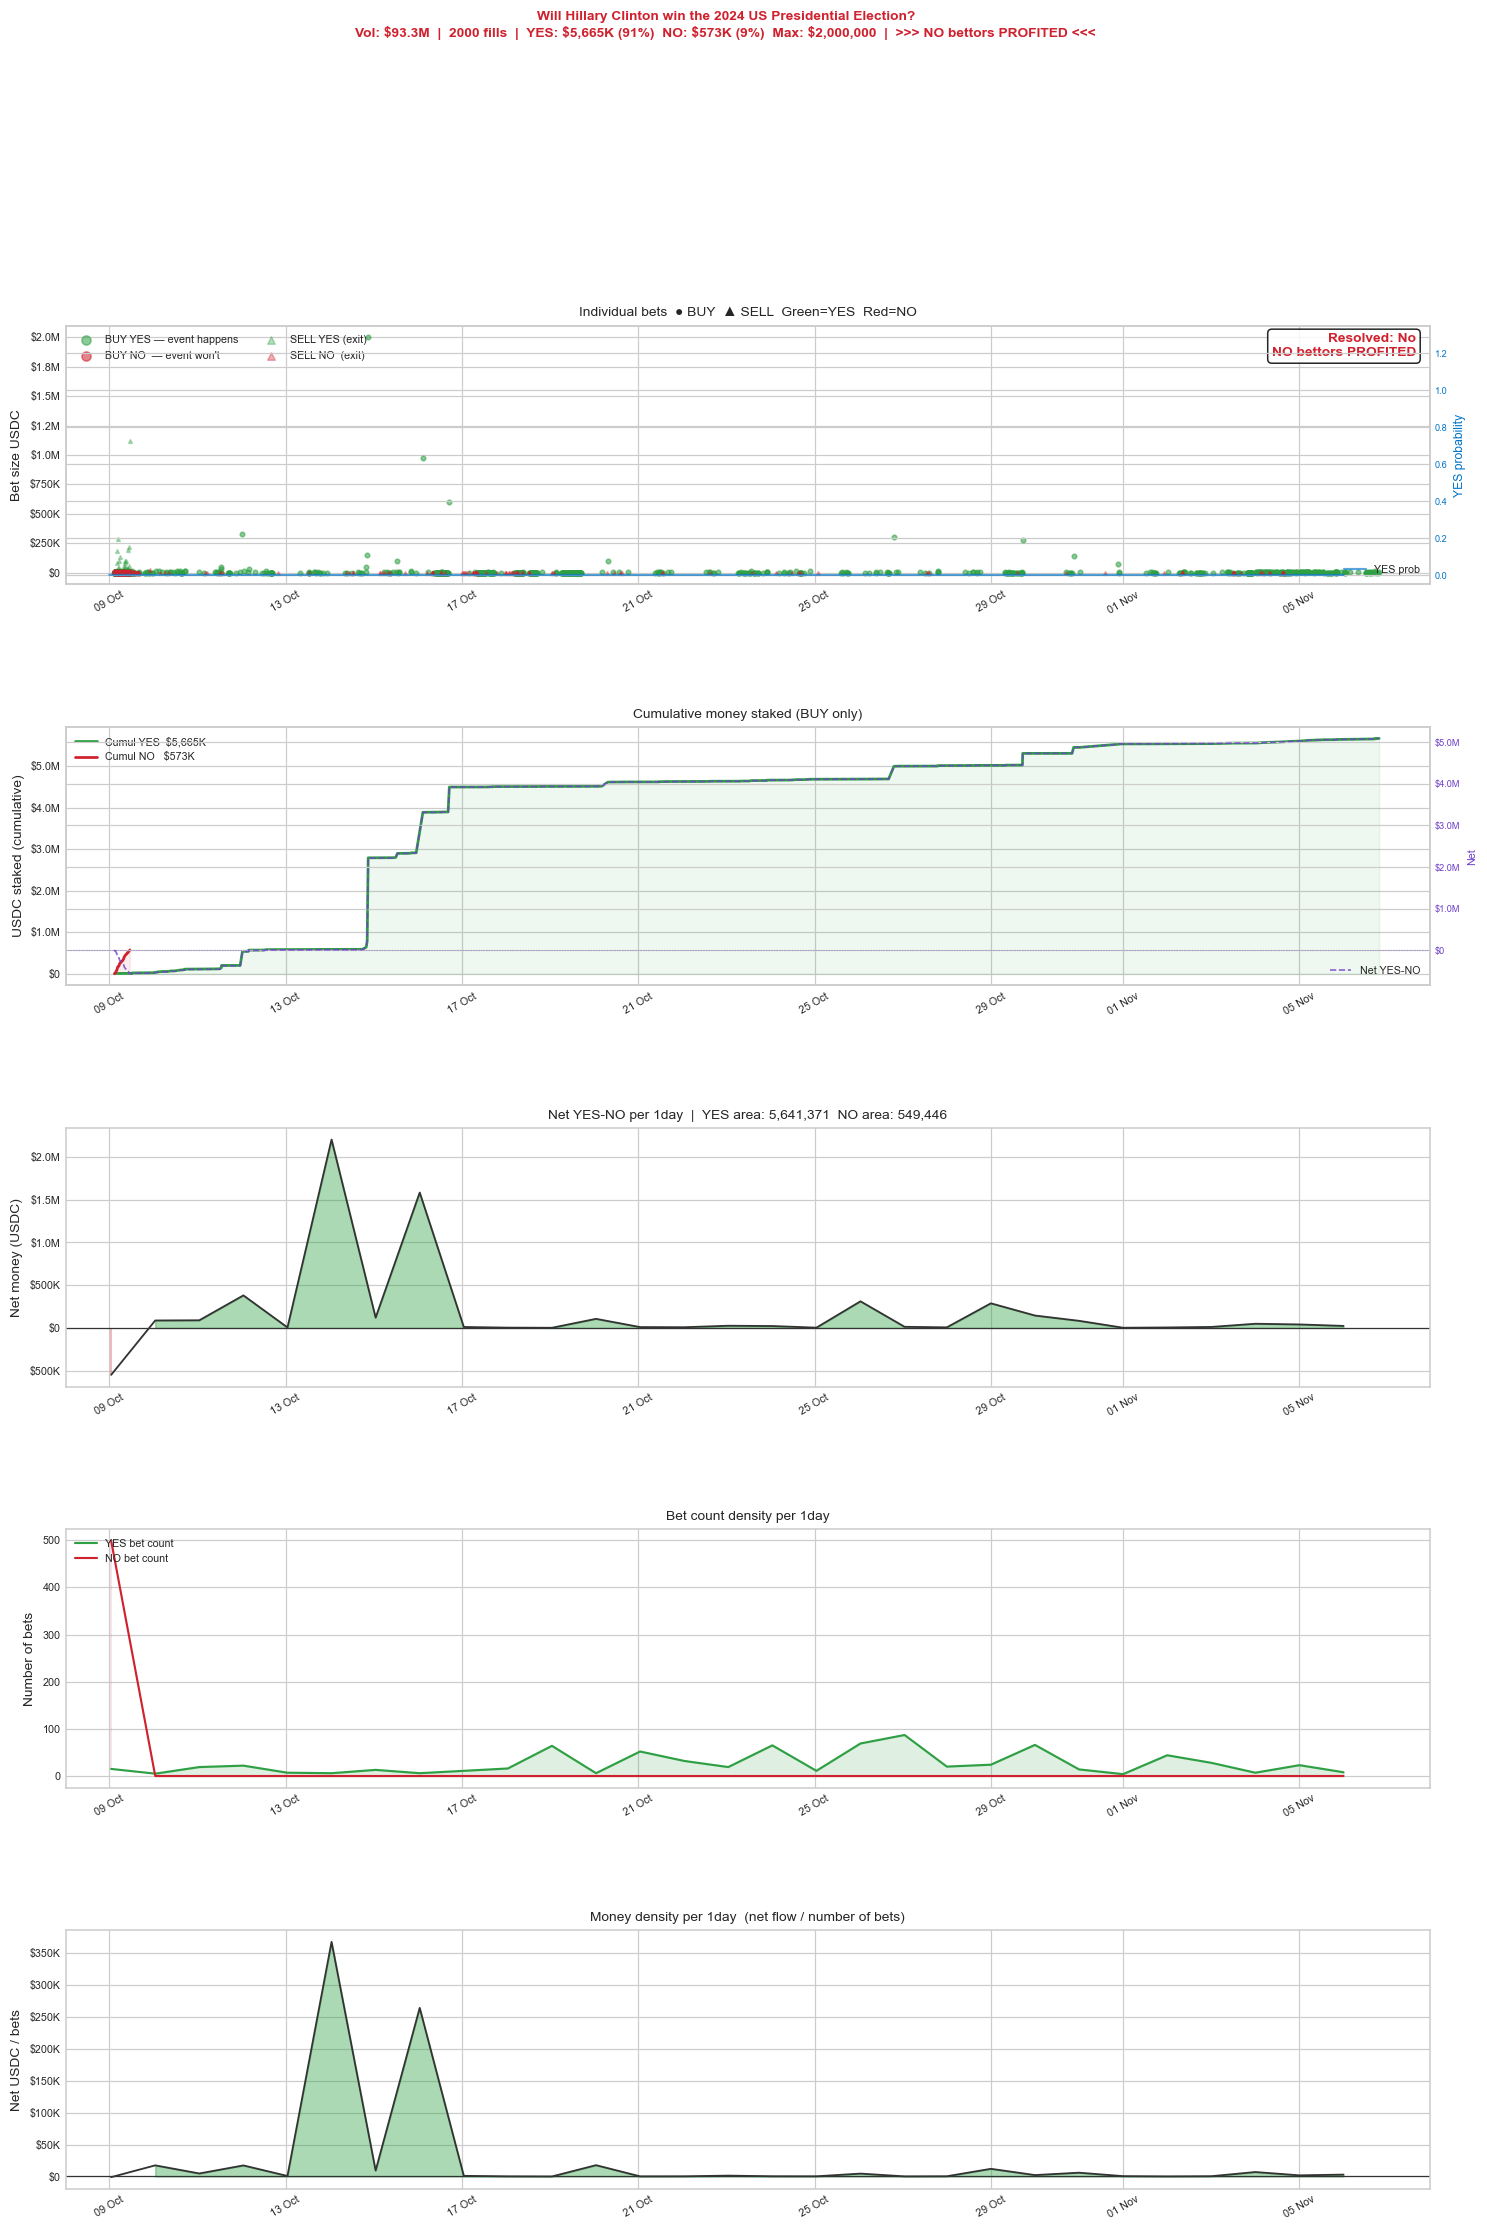

Will Gavin Newsom be D-nom for VP on Election Day?
  YES area: 88,011,351  |  NO area: 85,111


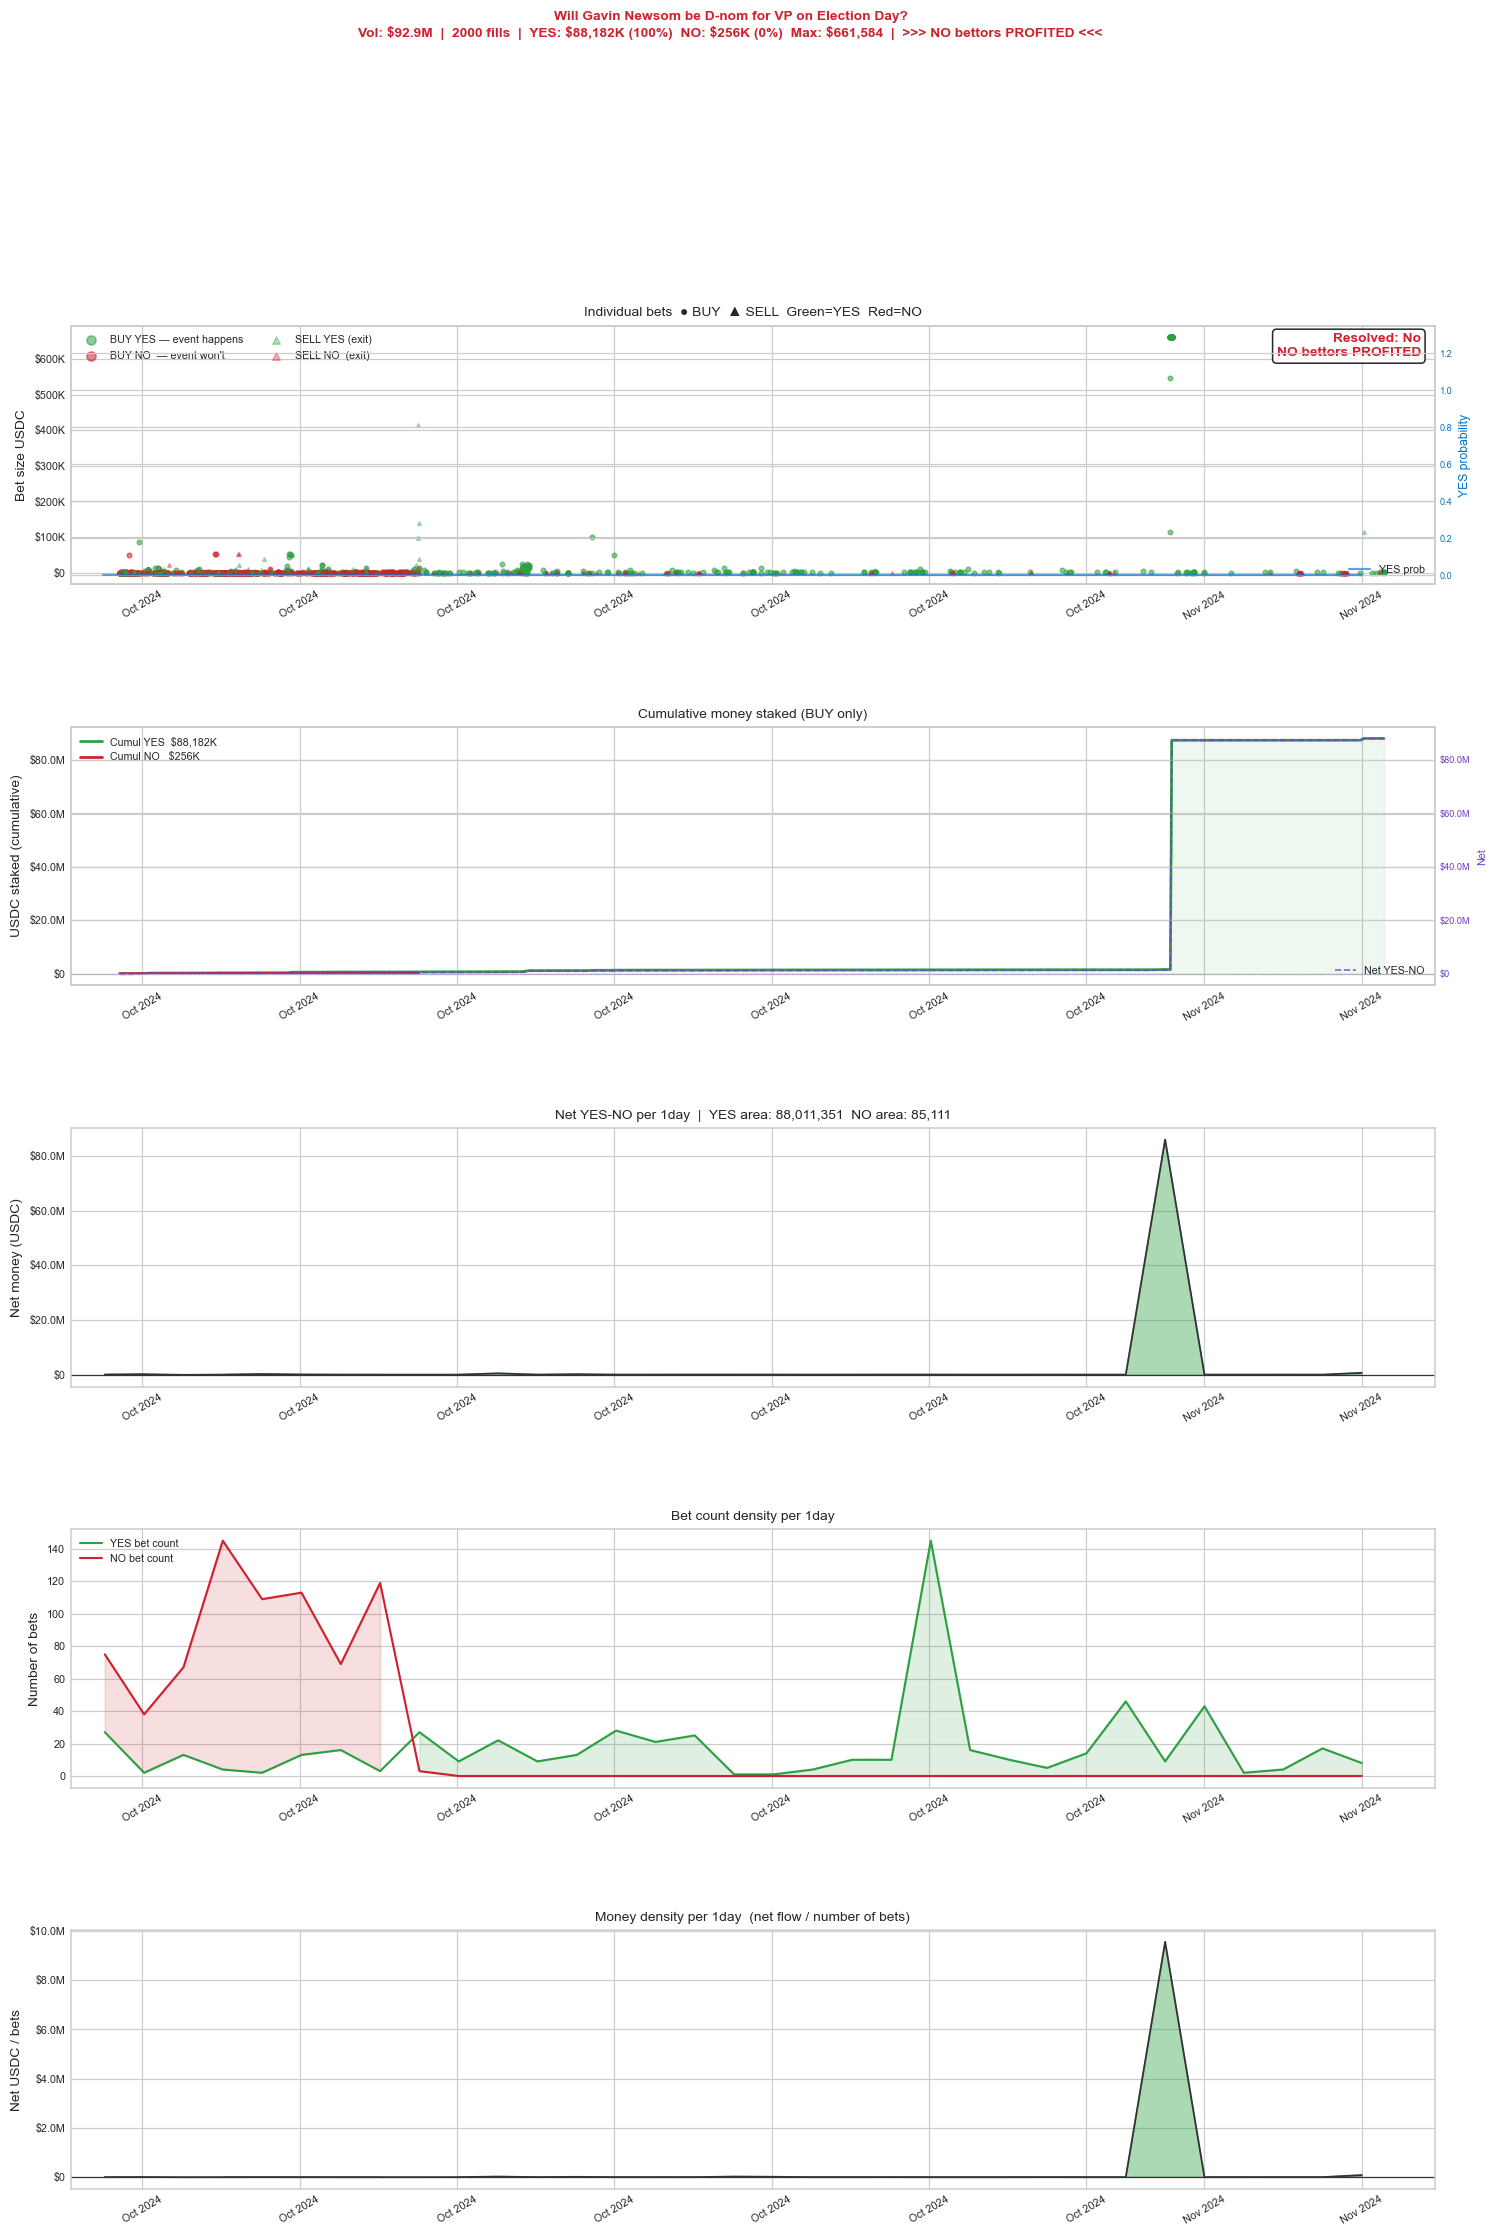

Will Trump release the Epstein files by December 19?
  YES area: 523,783  |  NO area: 9,197,144


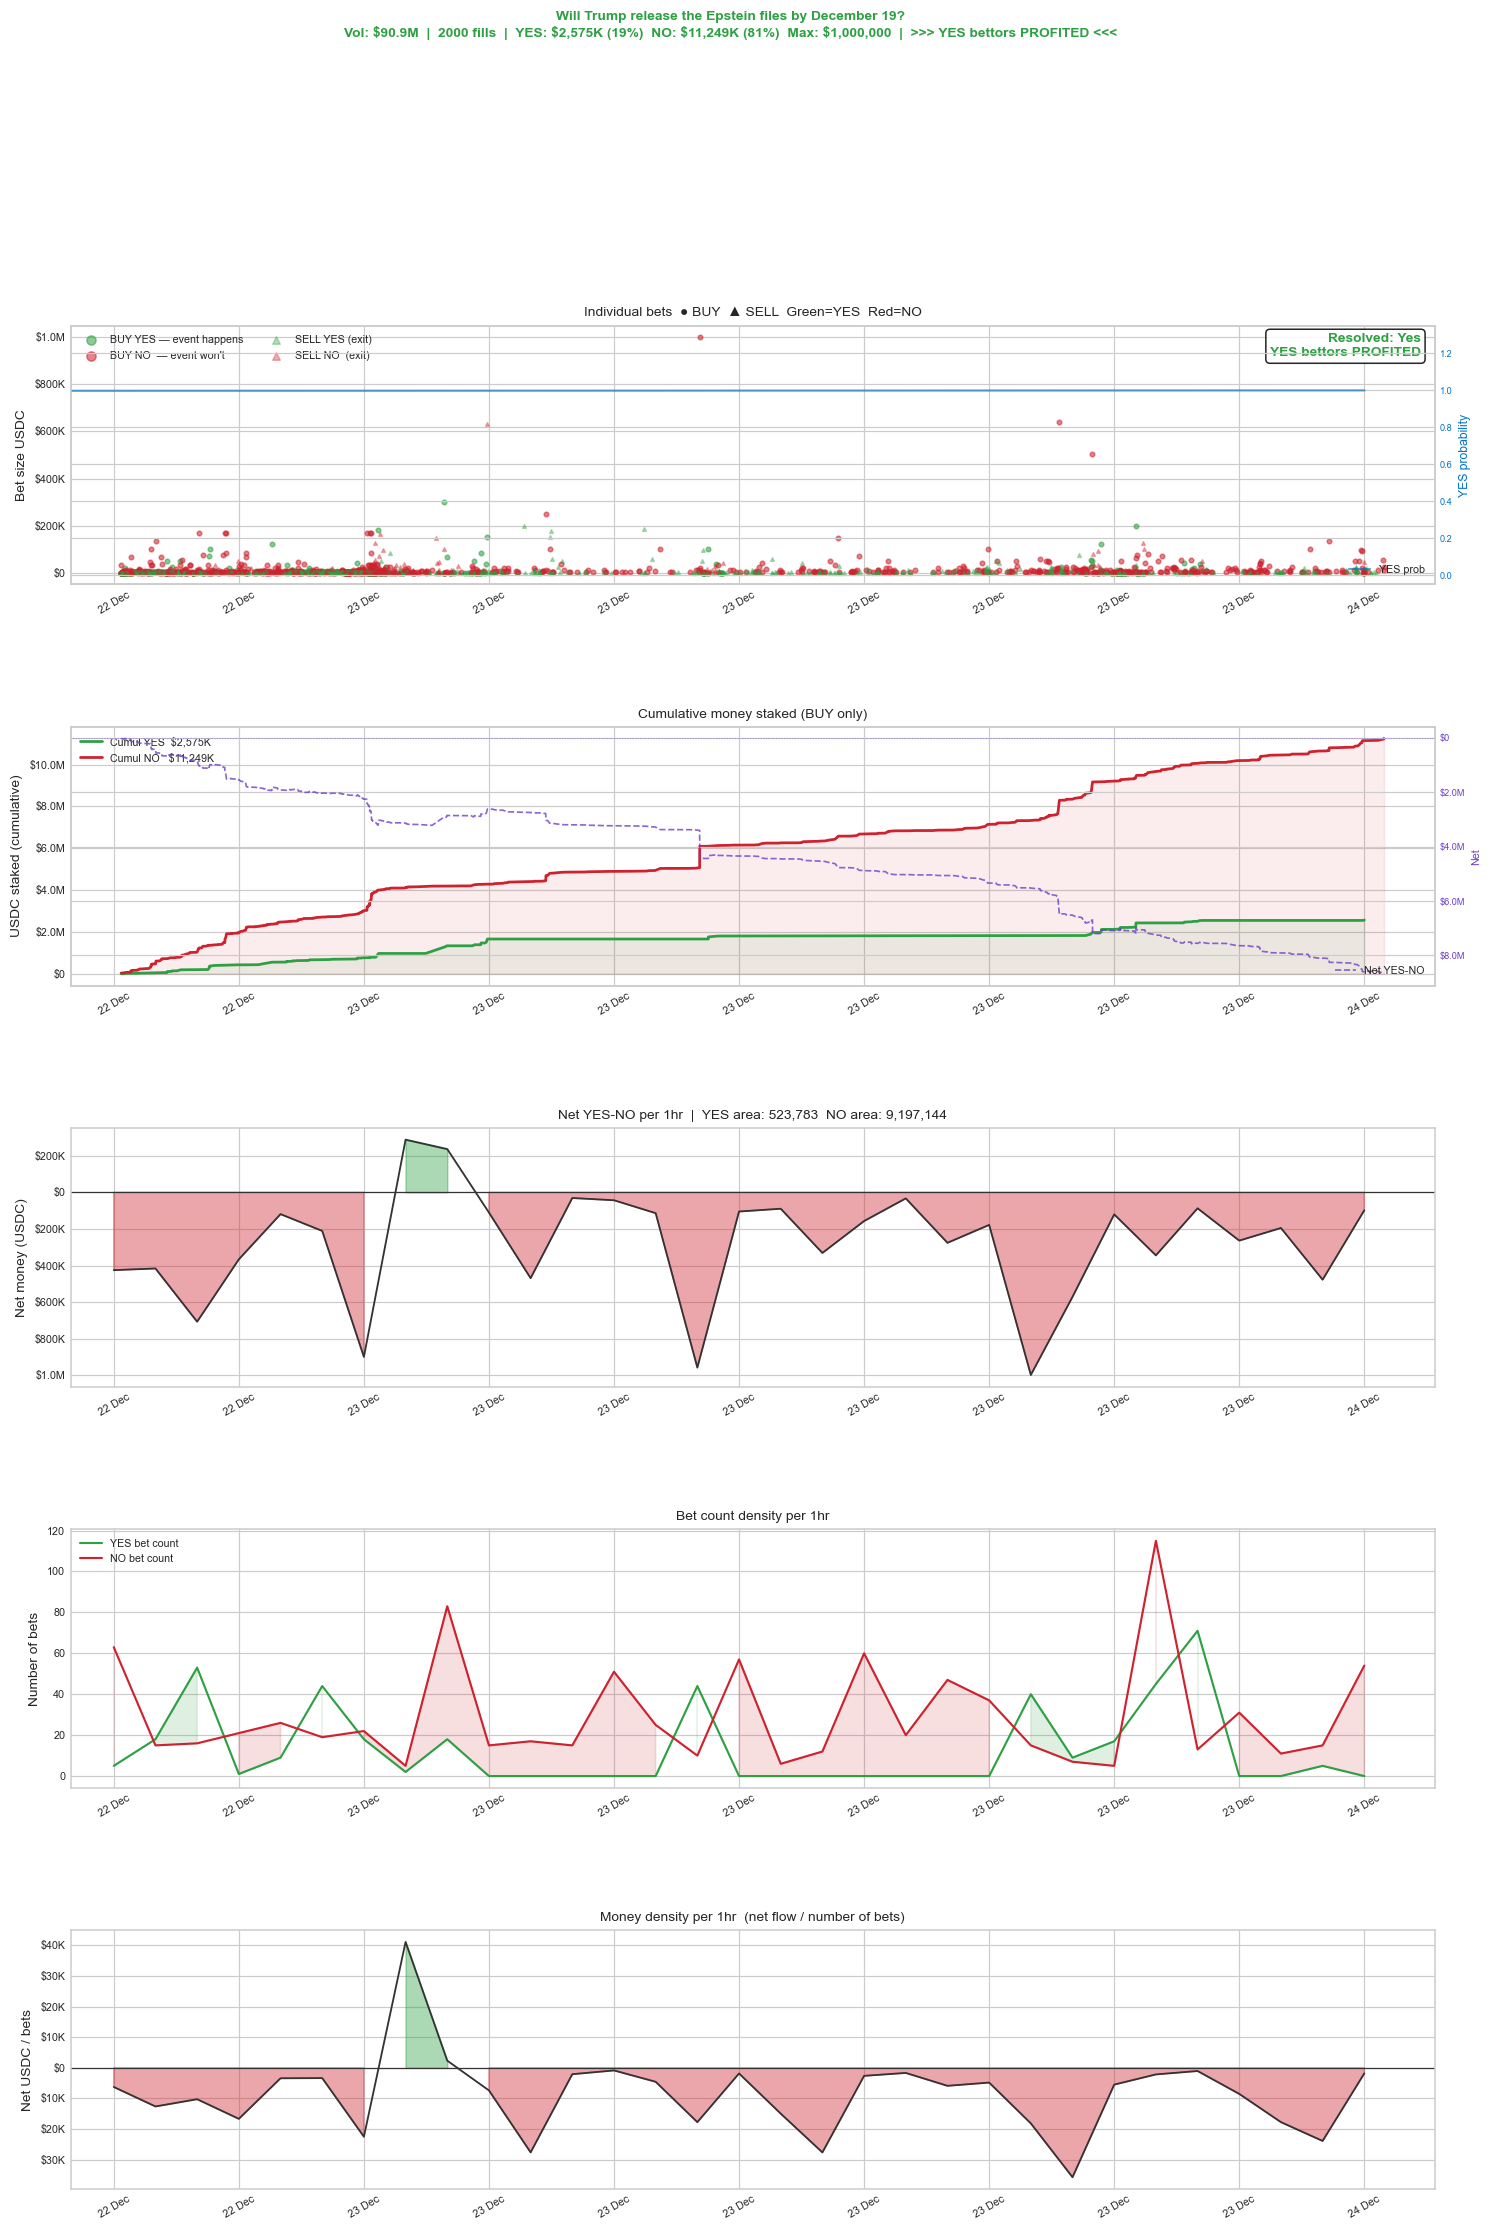

Will Lee Jae-myung be elected the next president of South Ko
  YES area: 1,171,085  |  NO area: 2,674,387


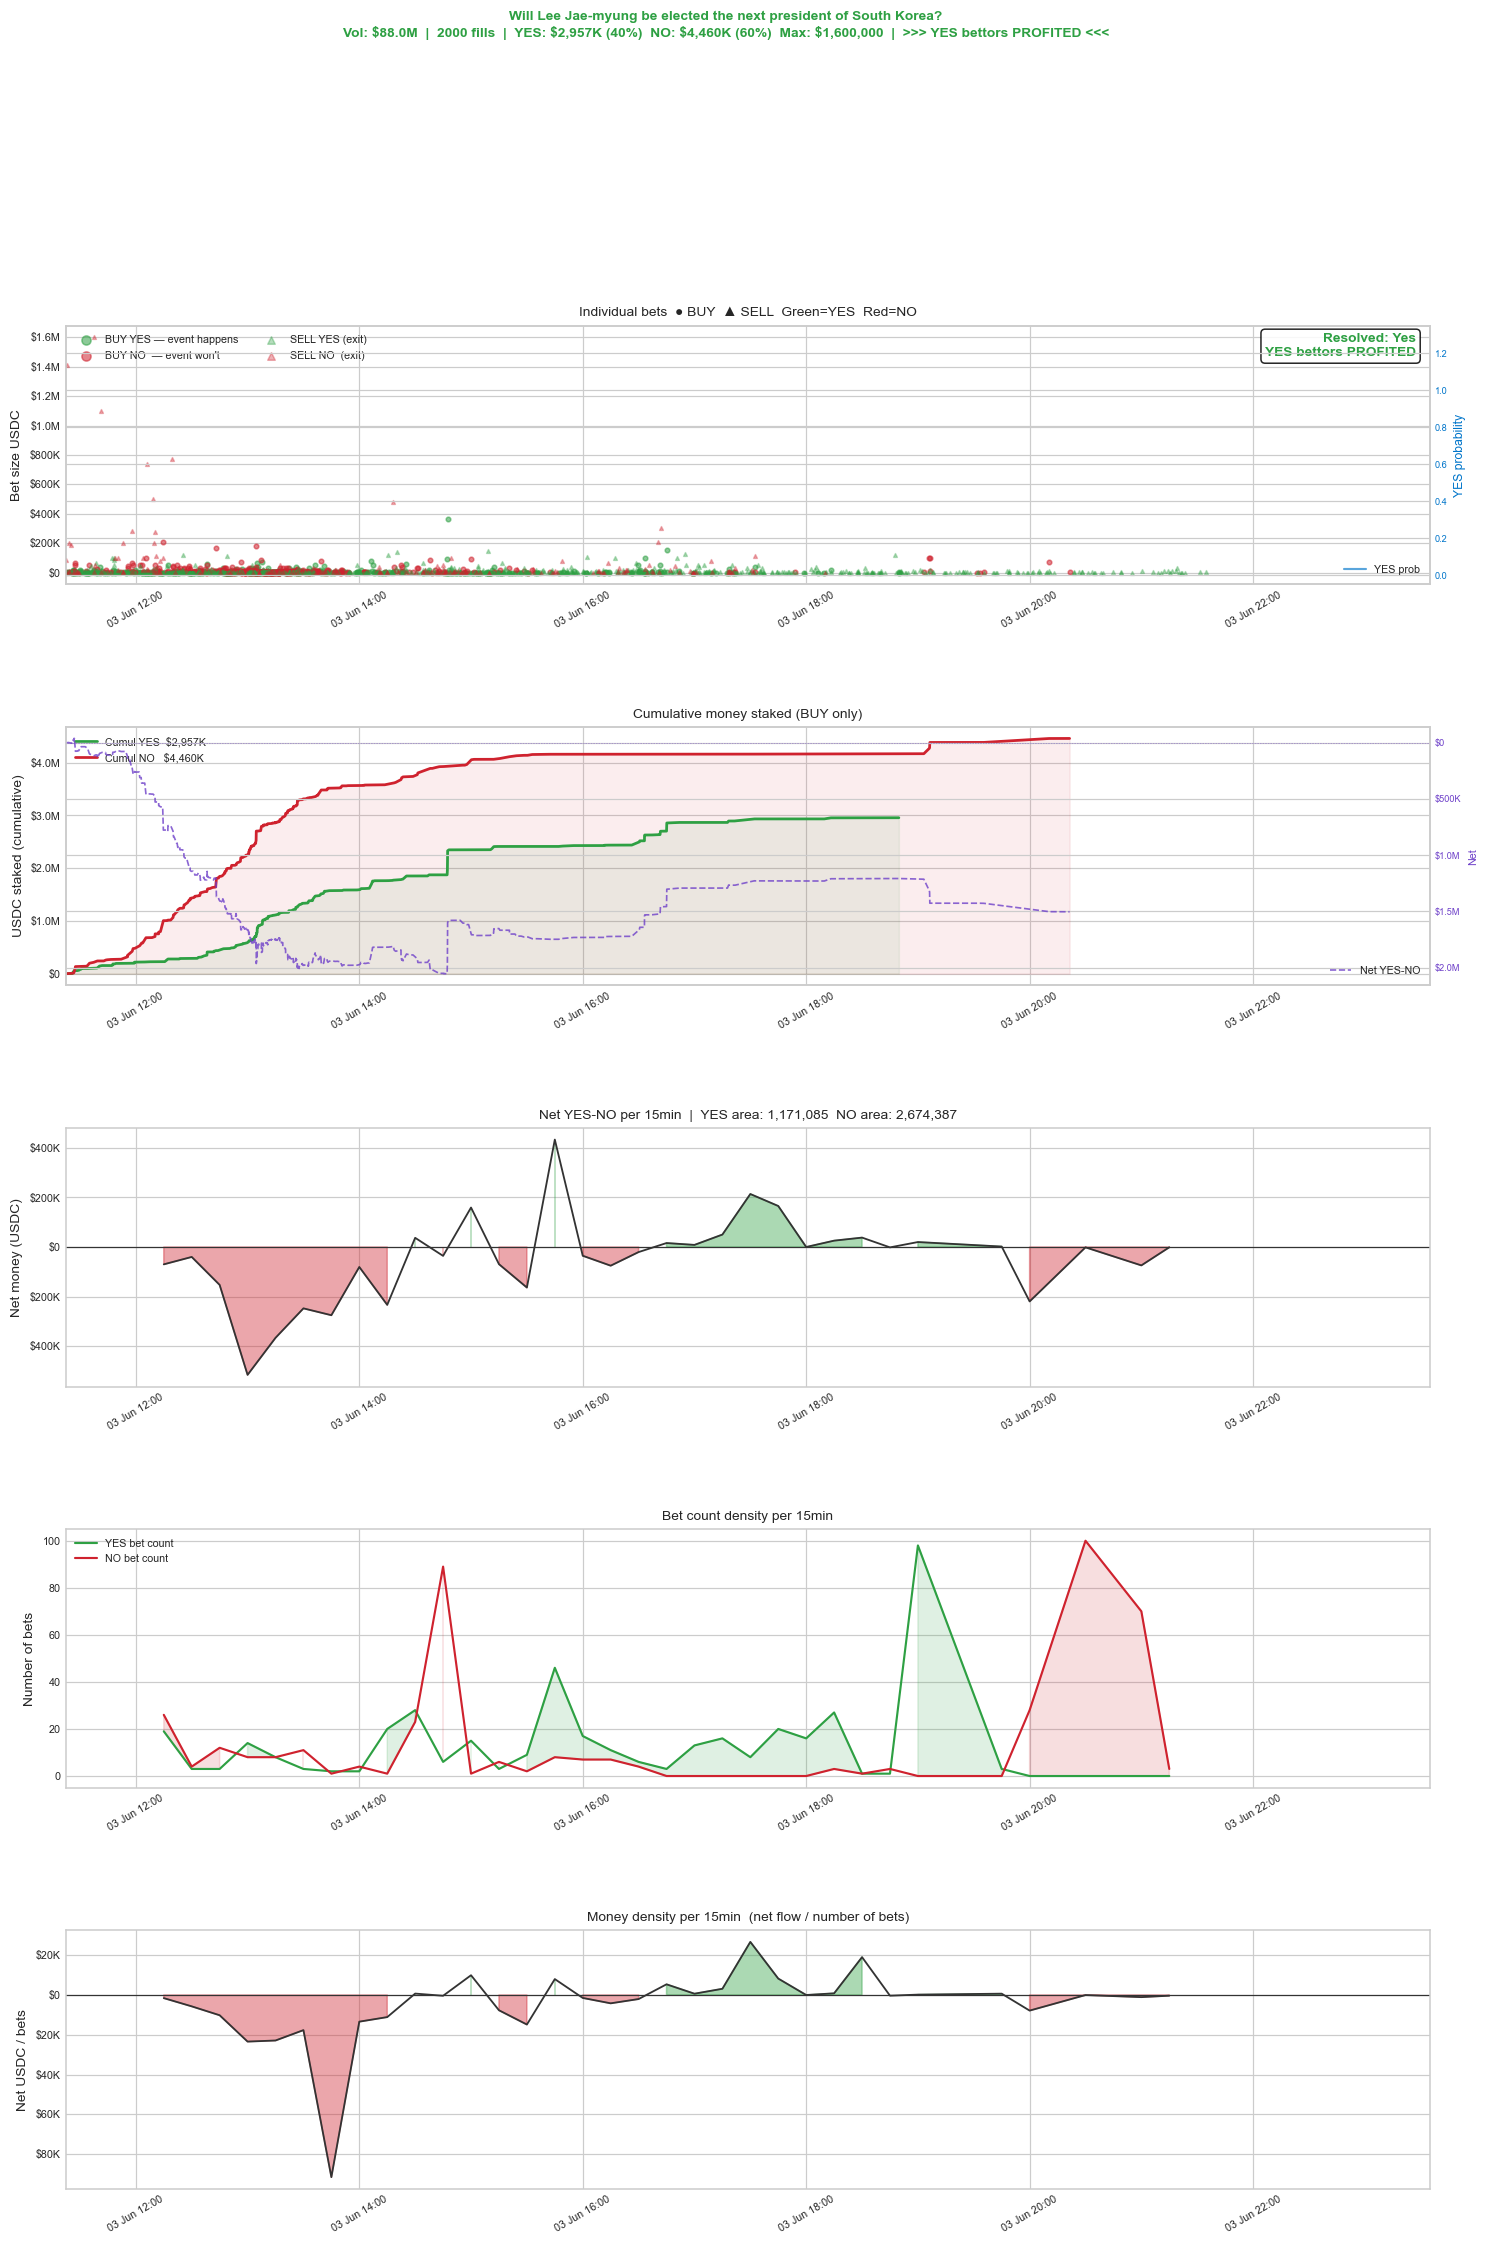

Will Hunor Kelemen win the Romanian presidential election?
  YES area: 80,474,383  |  NO area: 8,200


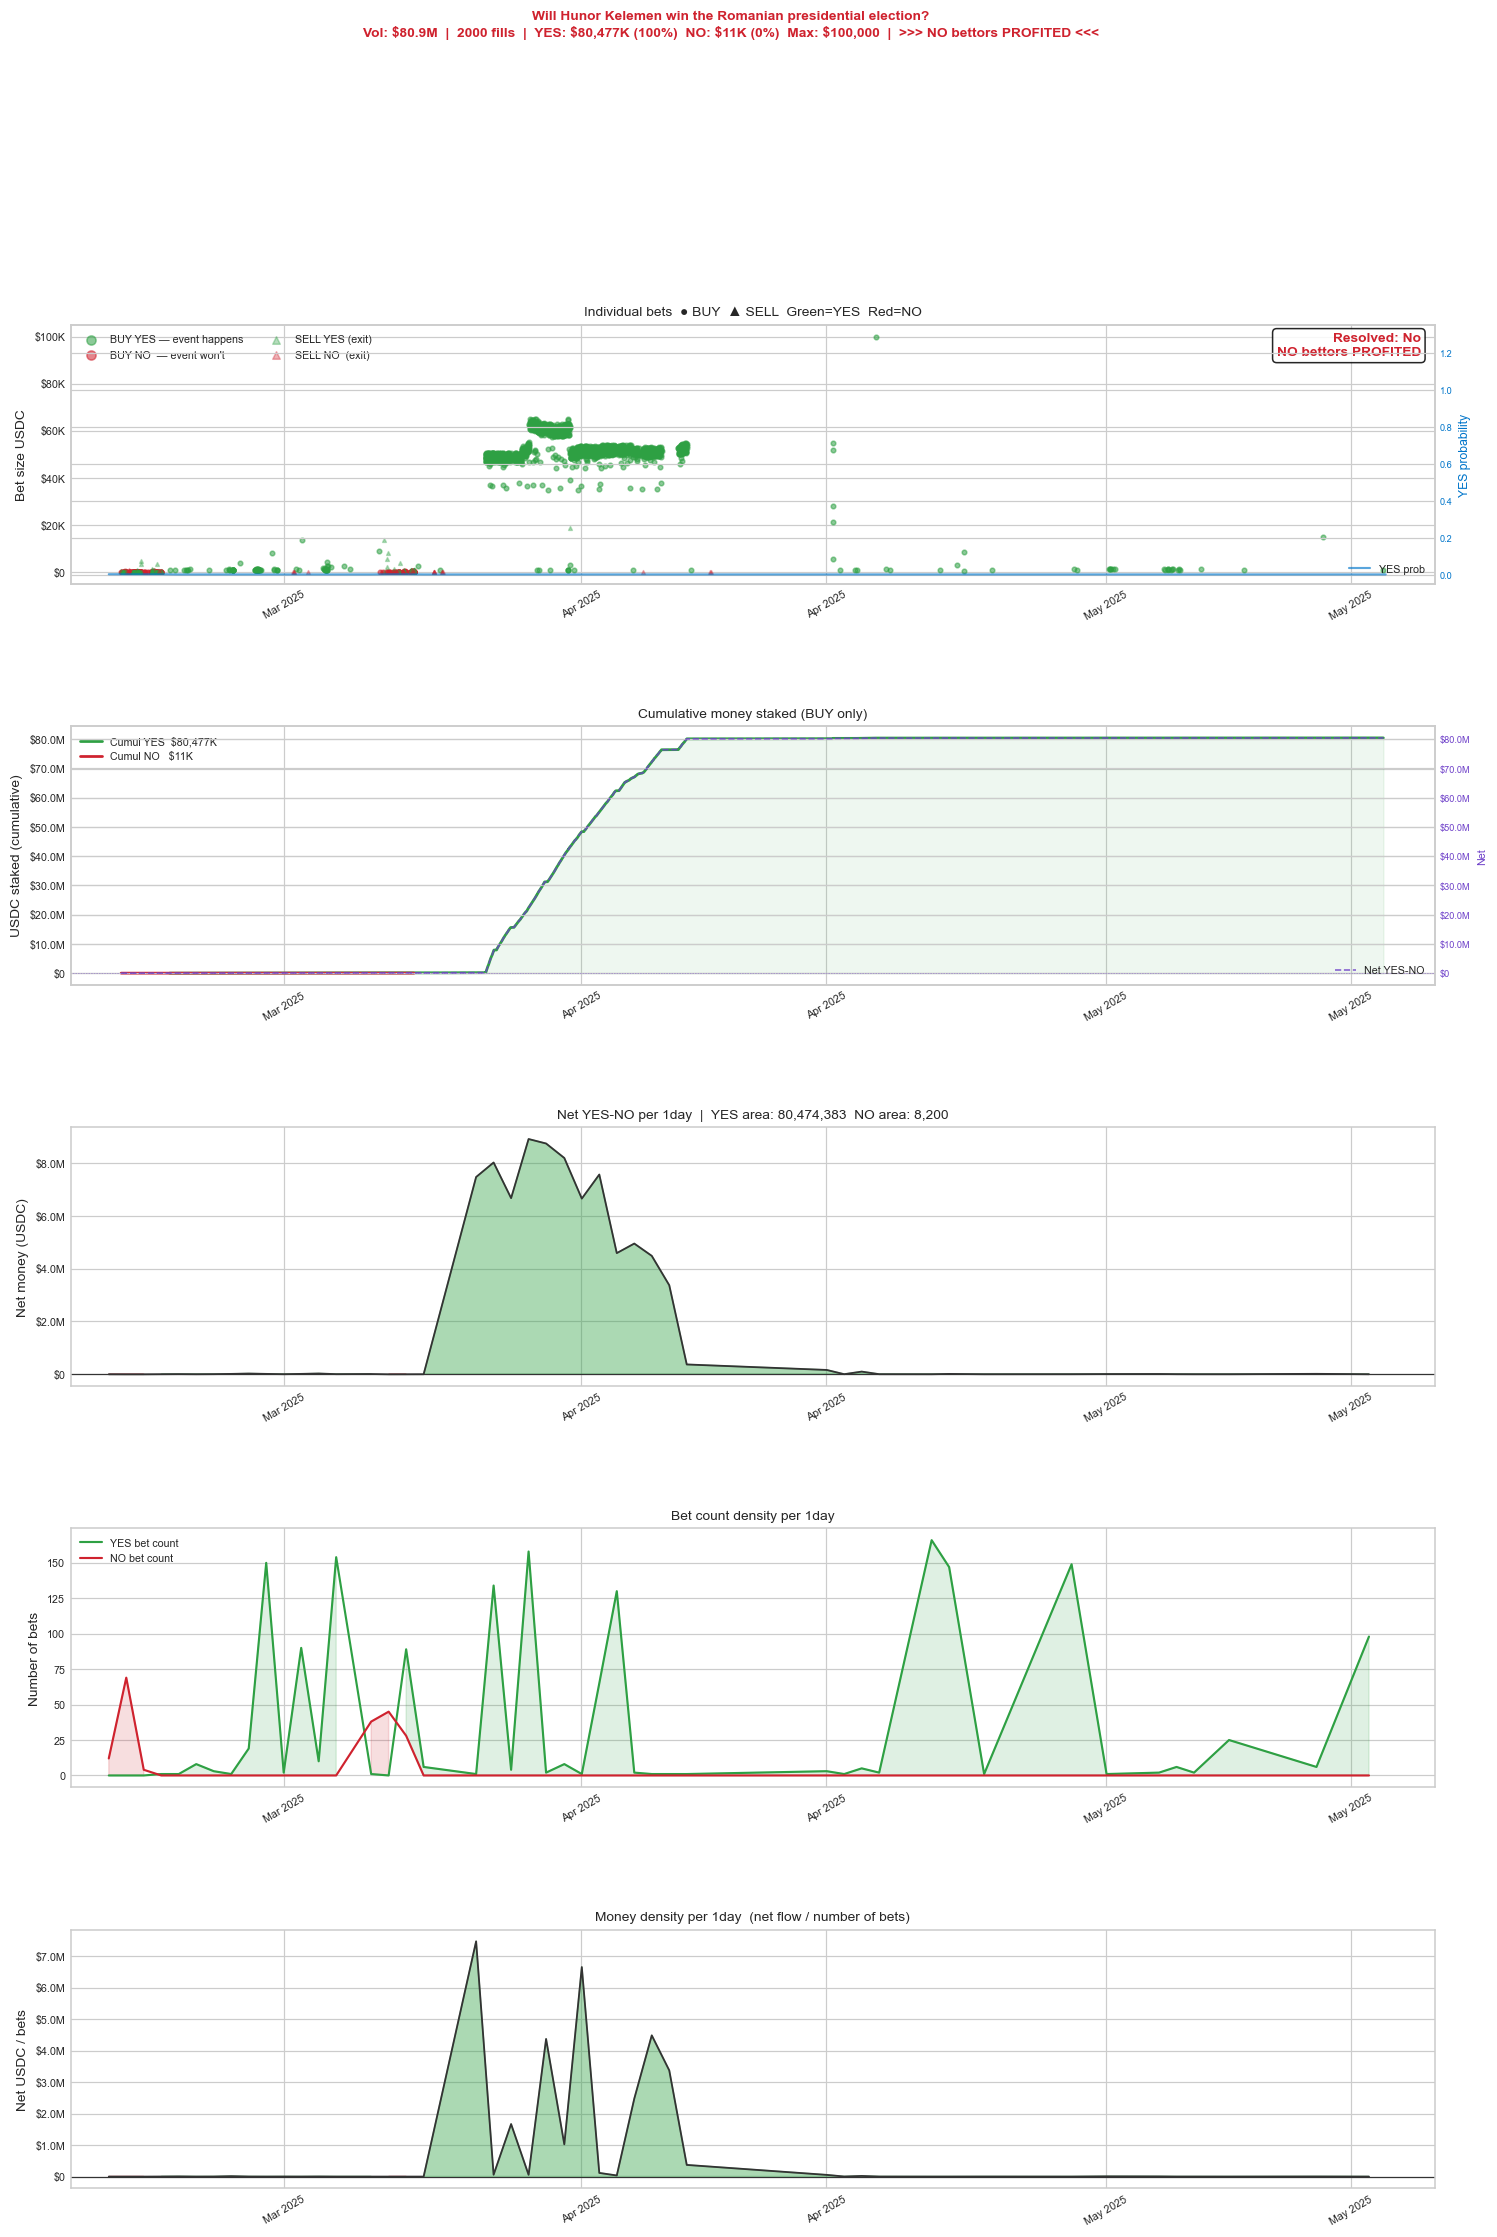

Will Trump launch a coin before the election?
  YES area: 73,634  |  NO area: 7,845,770


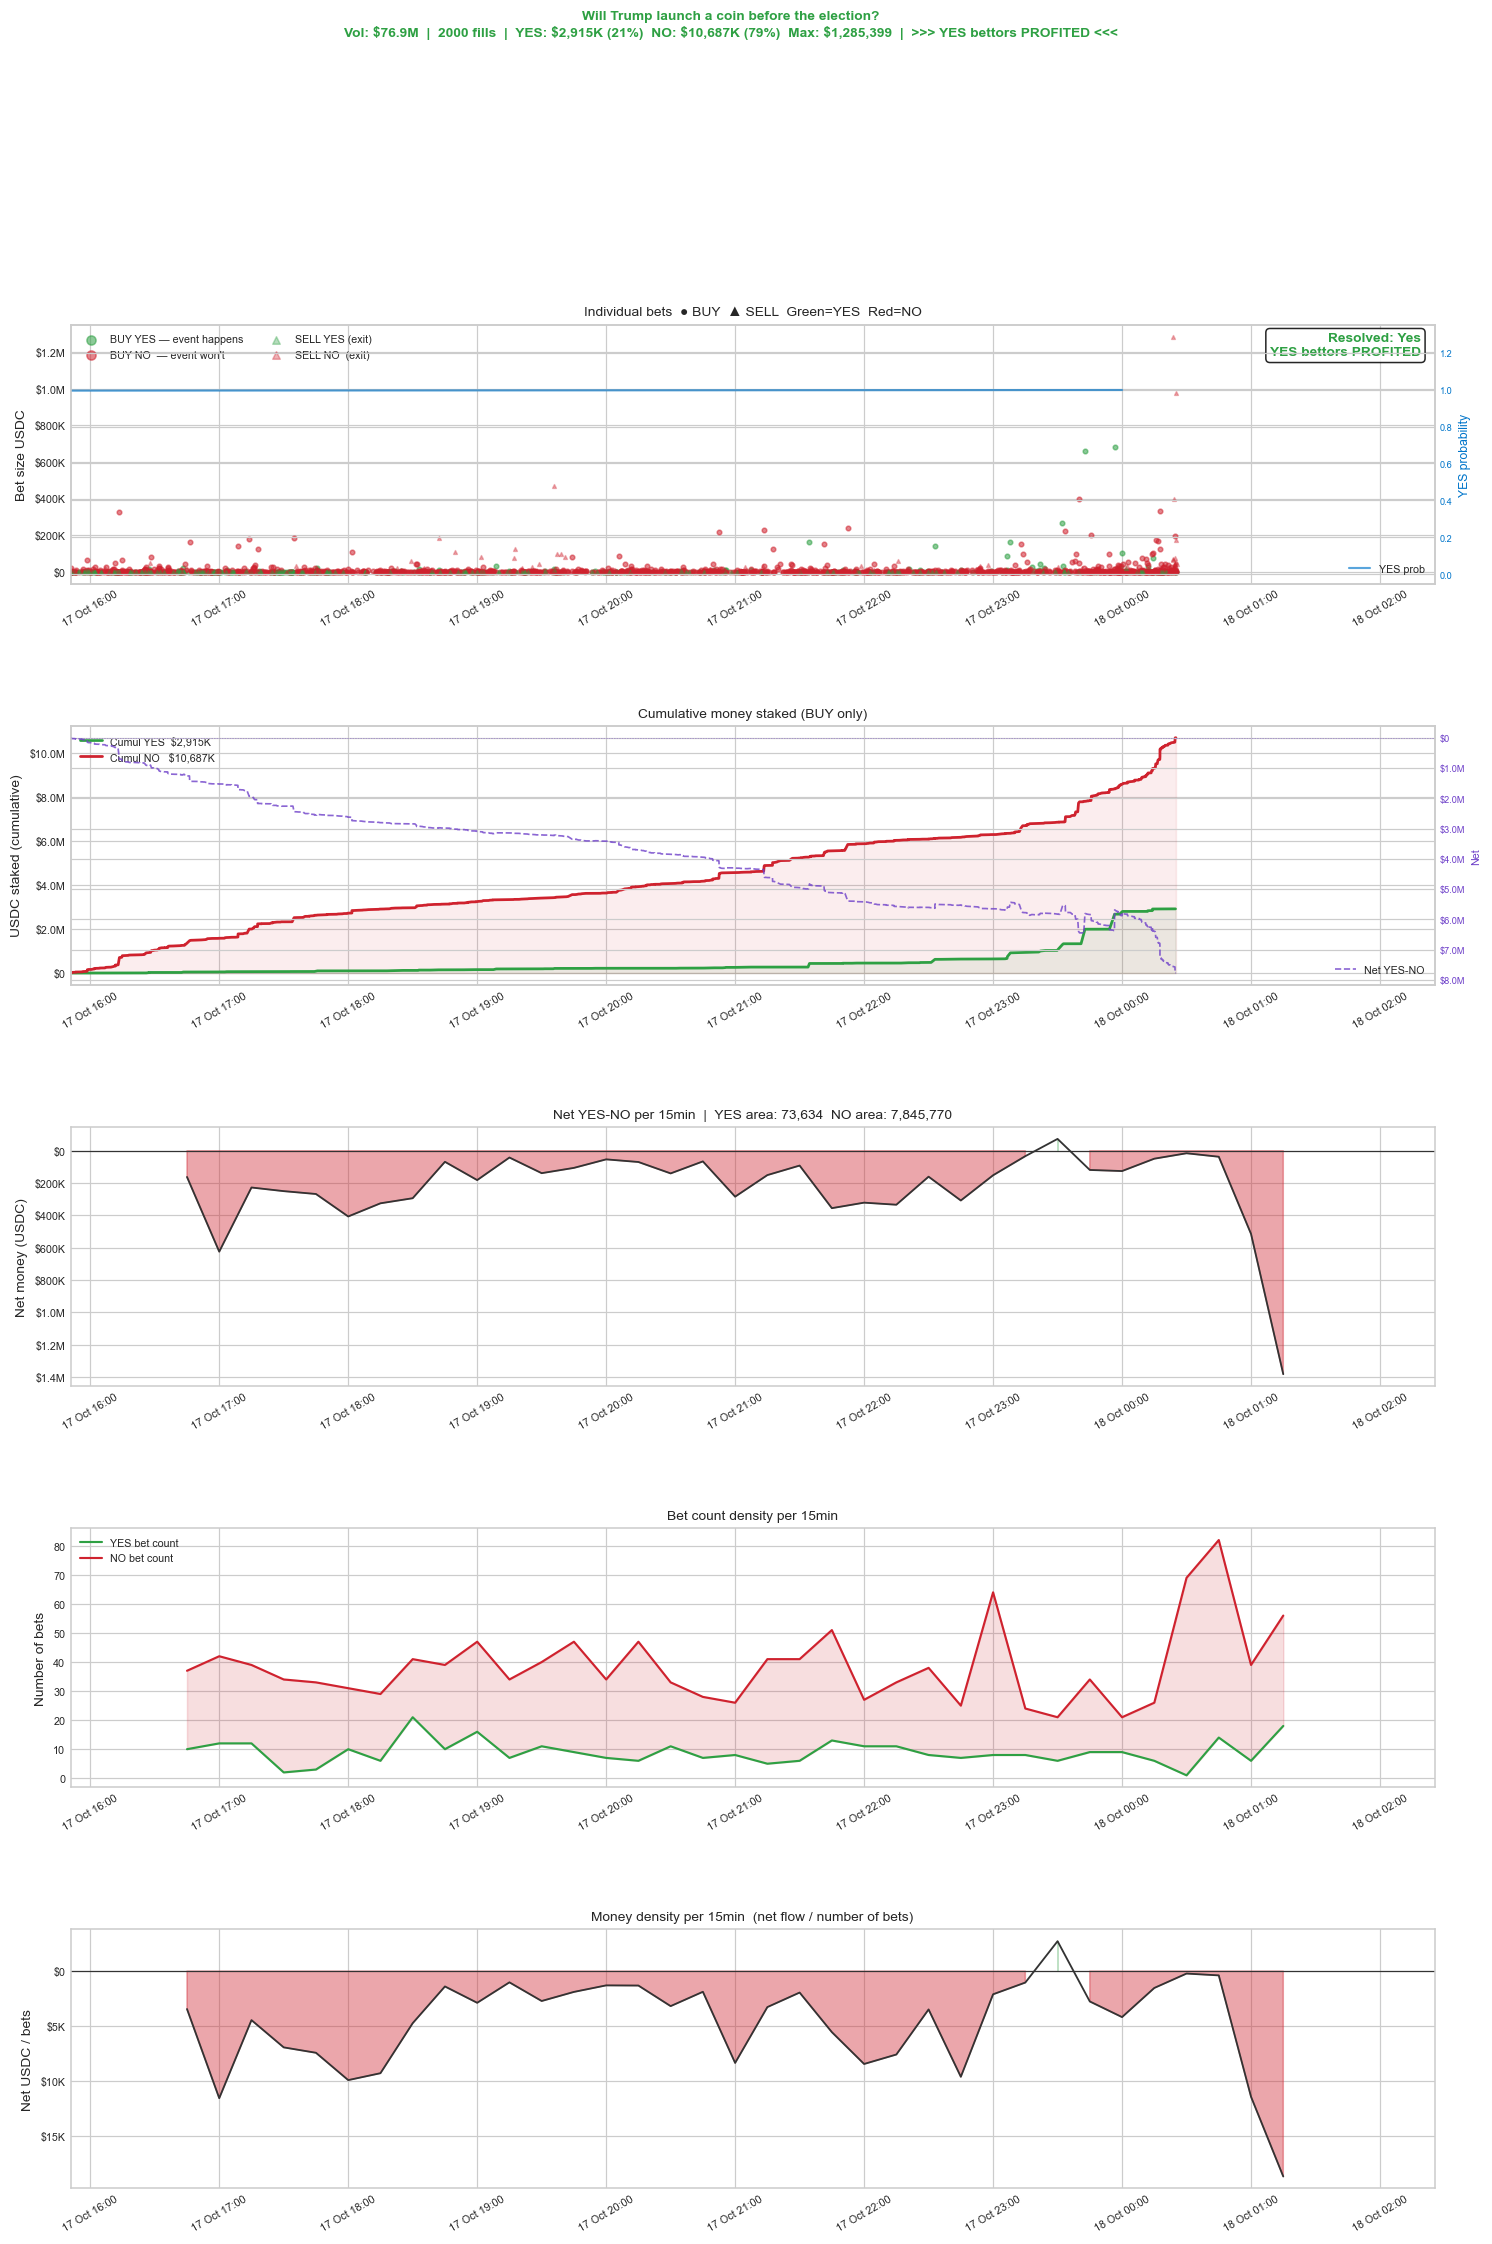

Will Kim Moon-soo be elected the next president of South Kor
  YES area: 12,011,866  |  NO area: 0


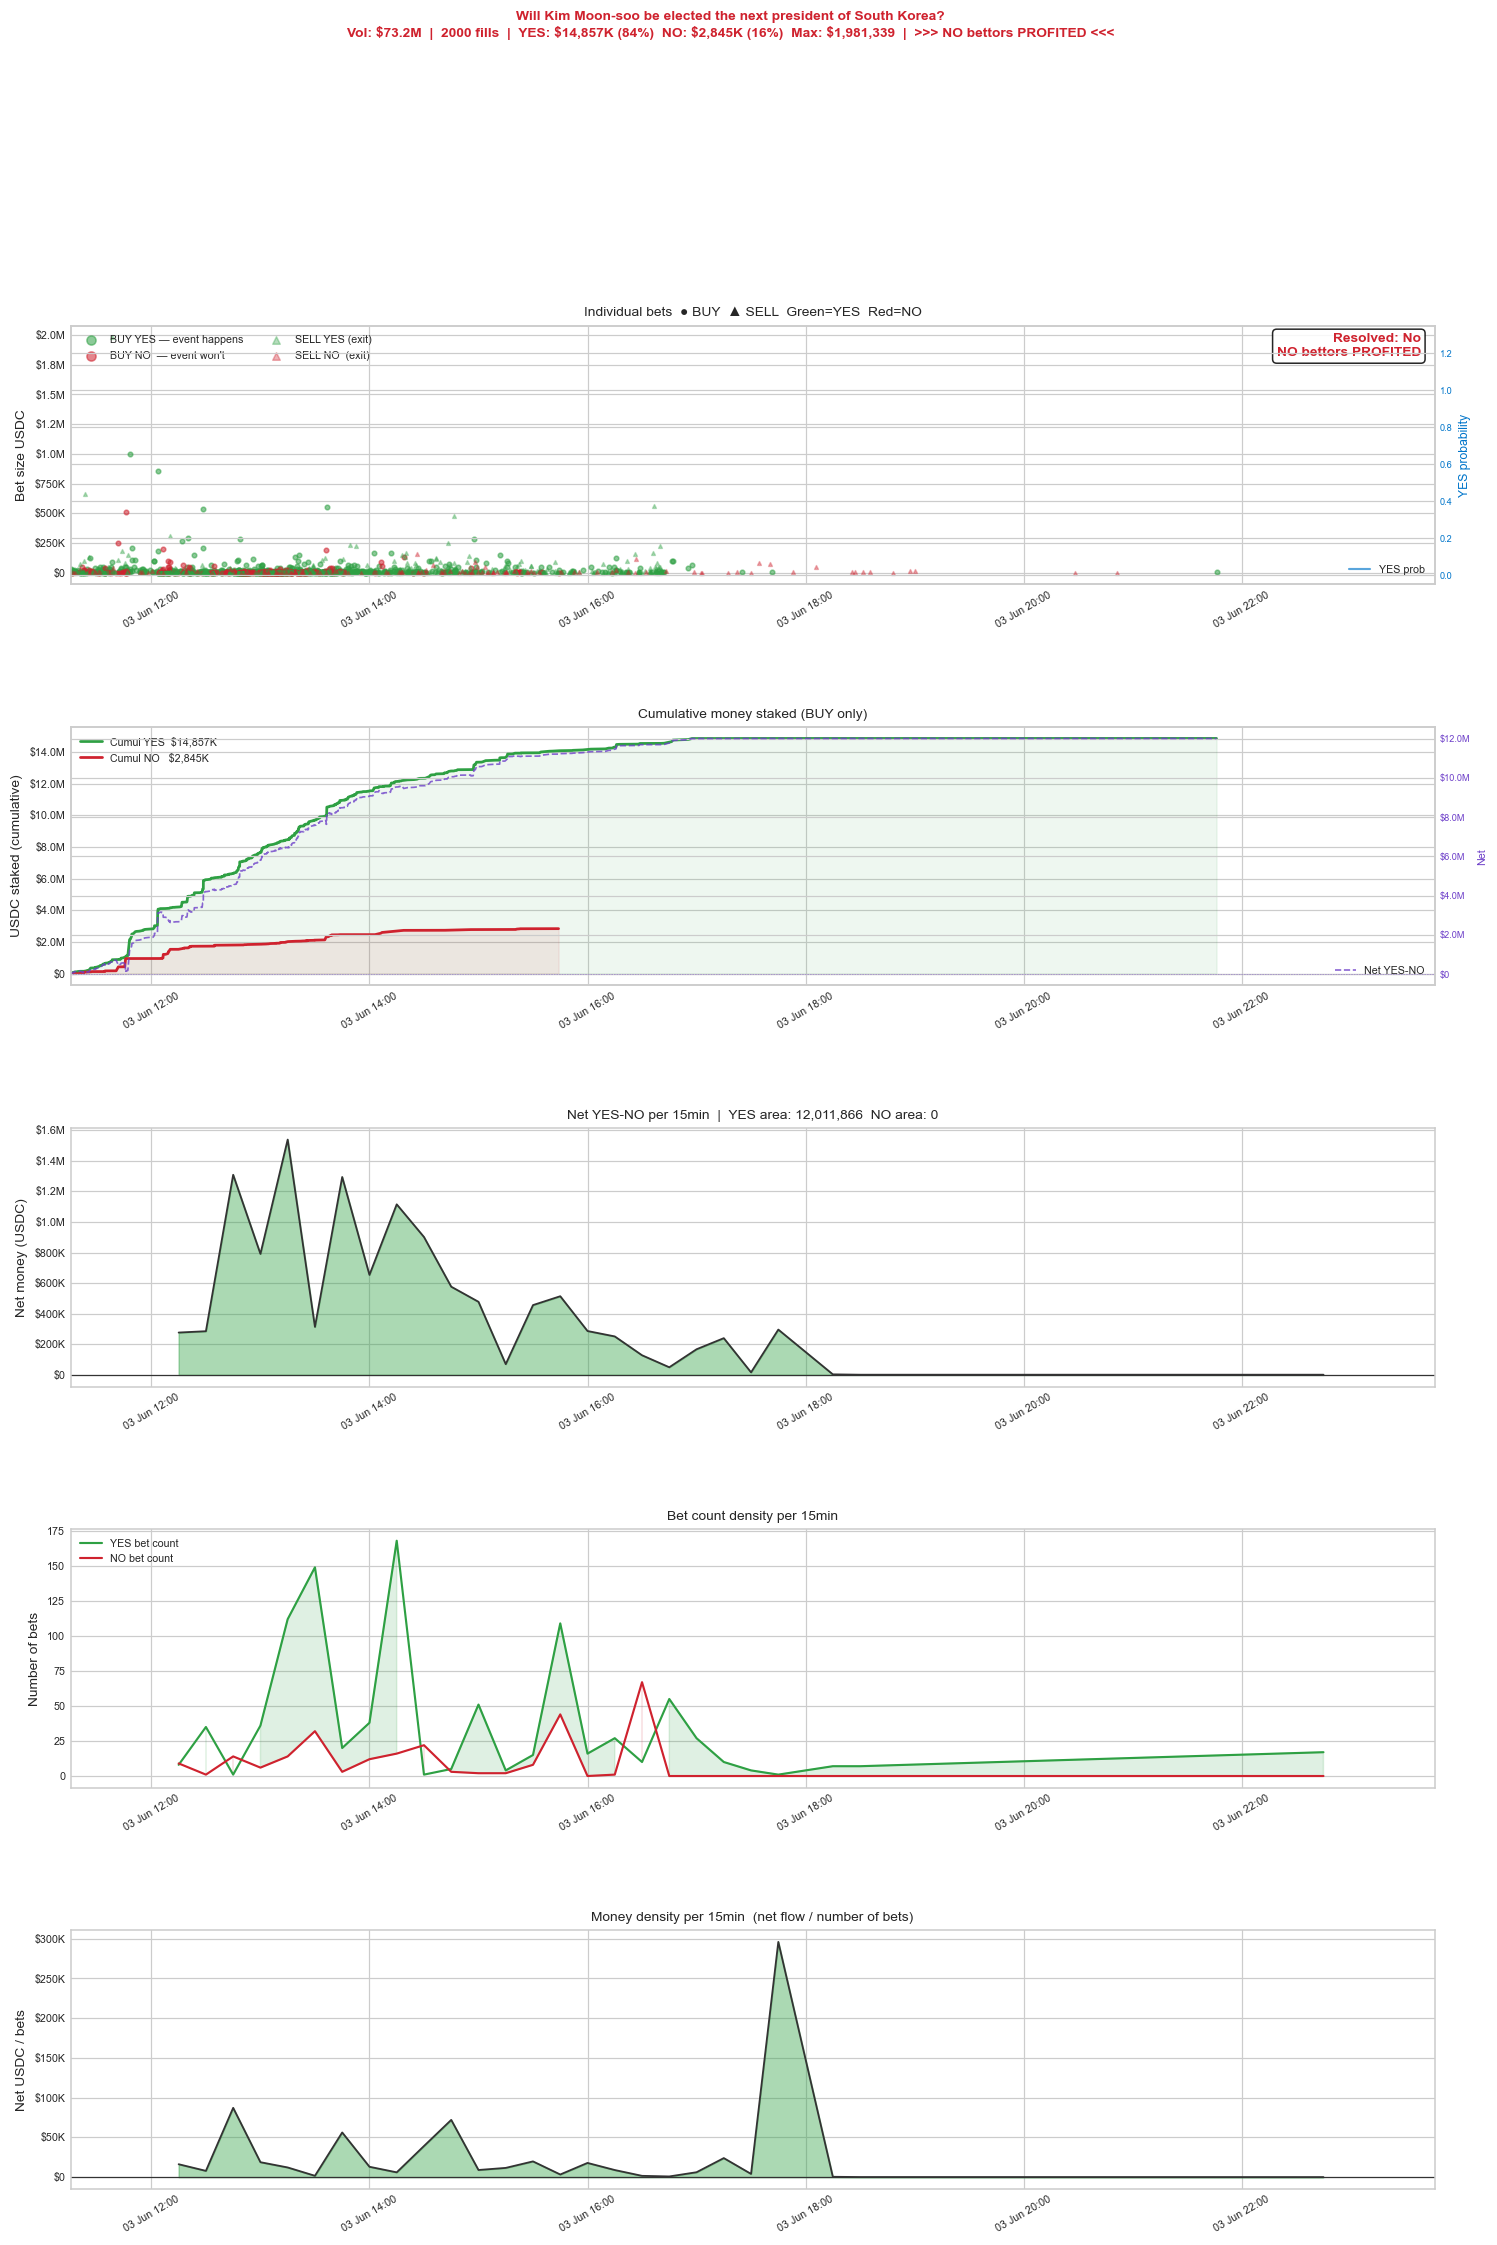

Will Kamala Harris be inaugurated?
  YES area: 543,683  |  NO area: 283,802


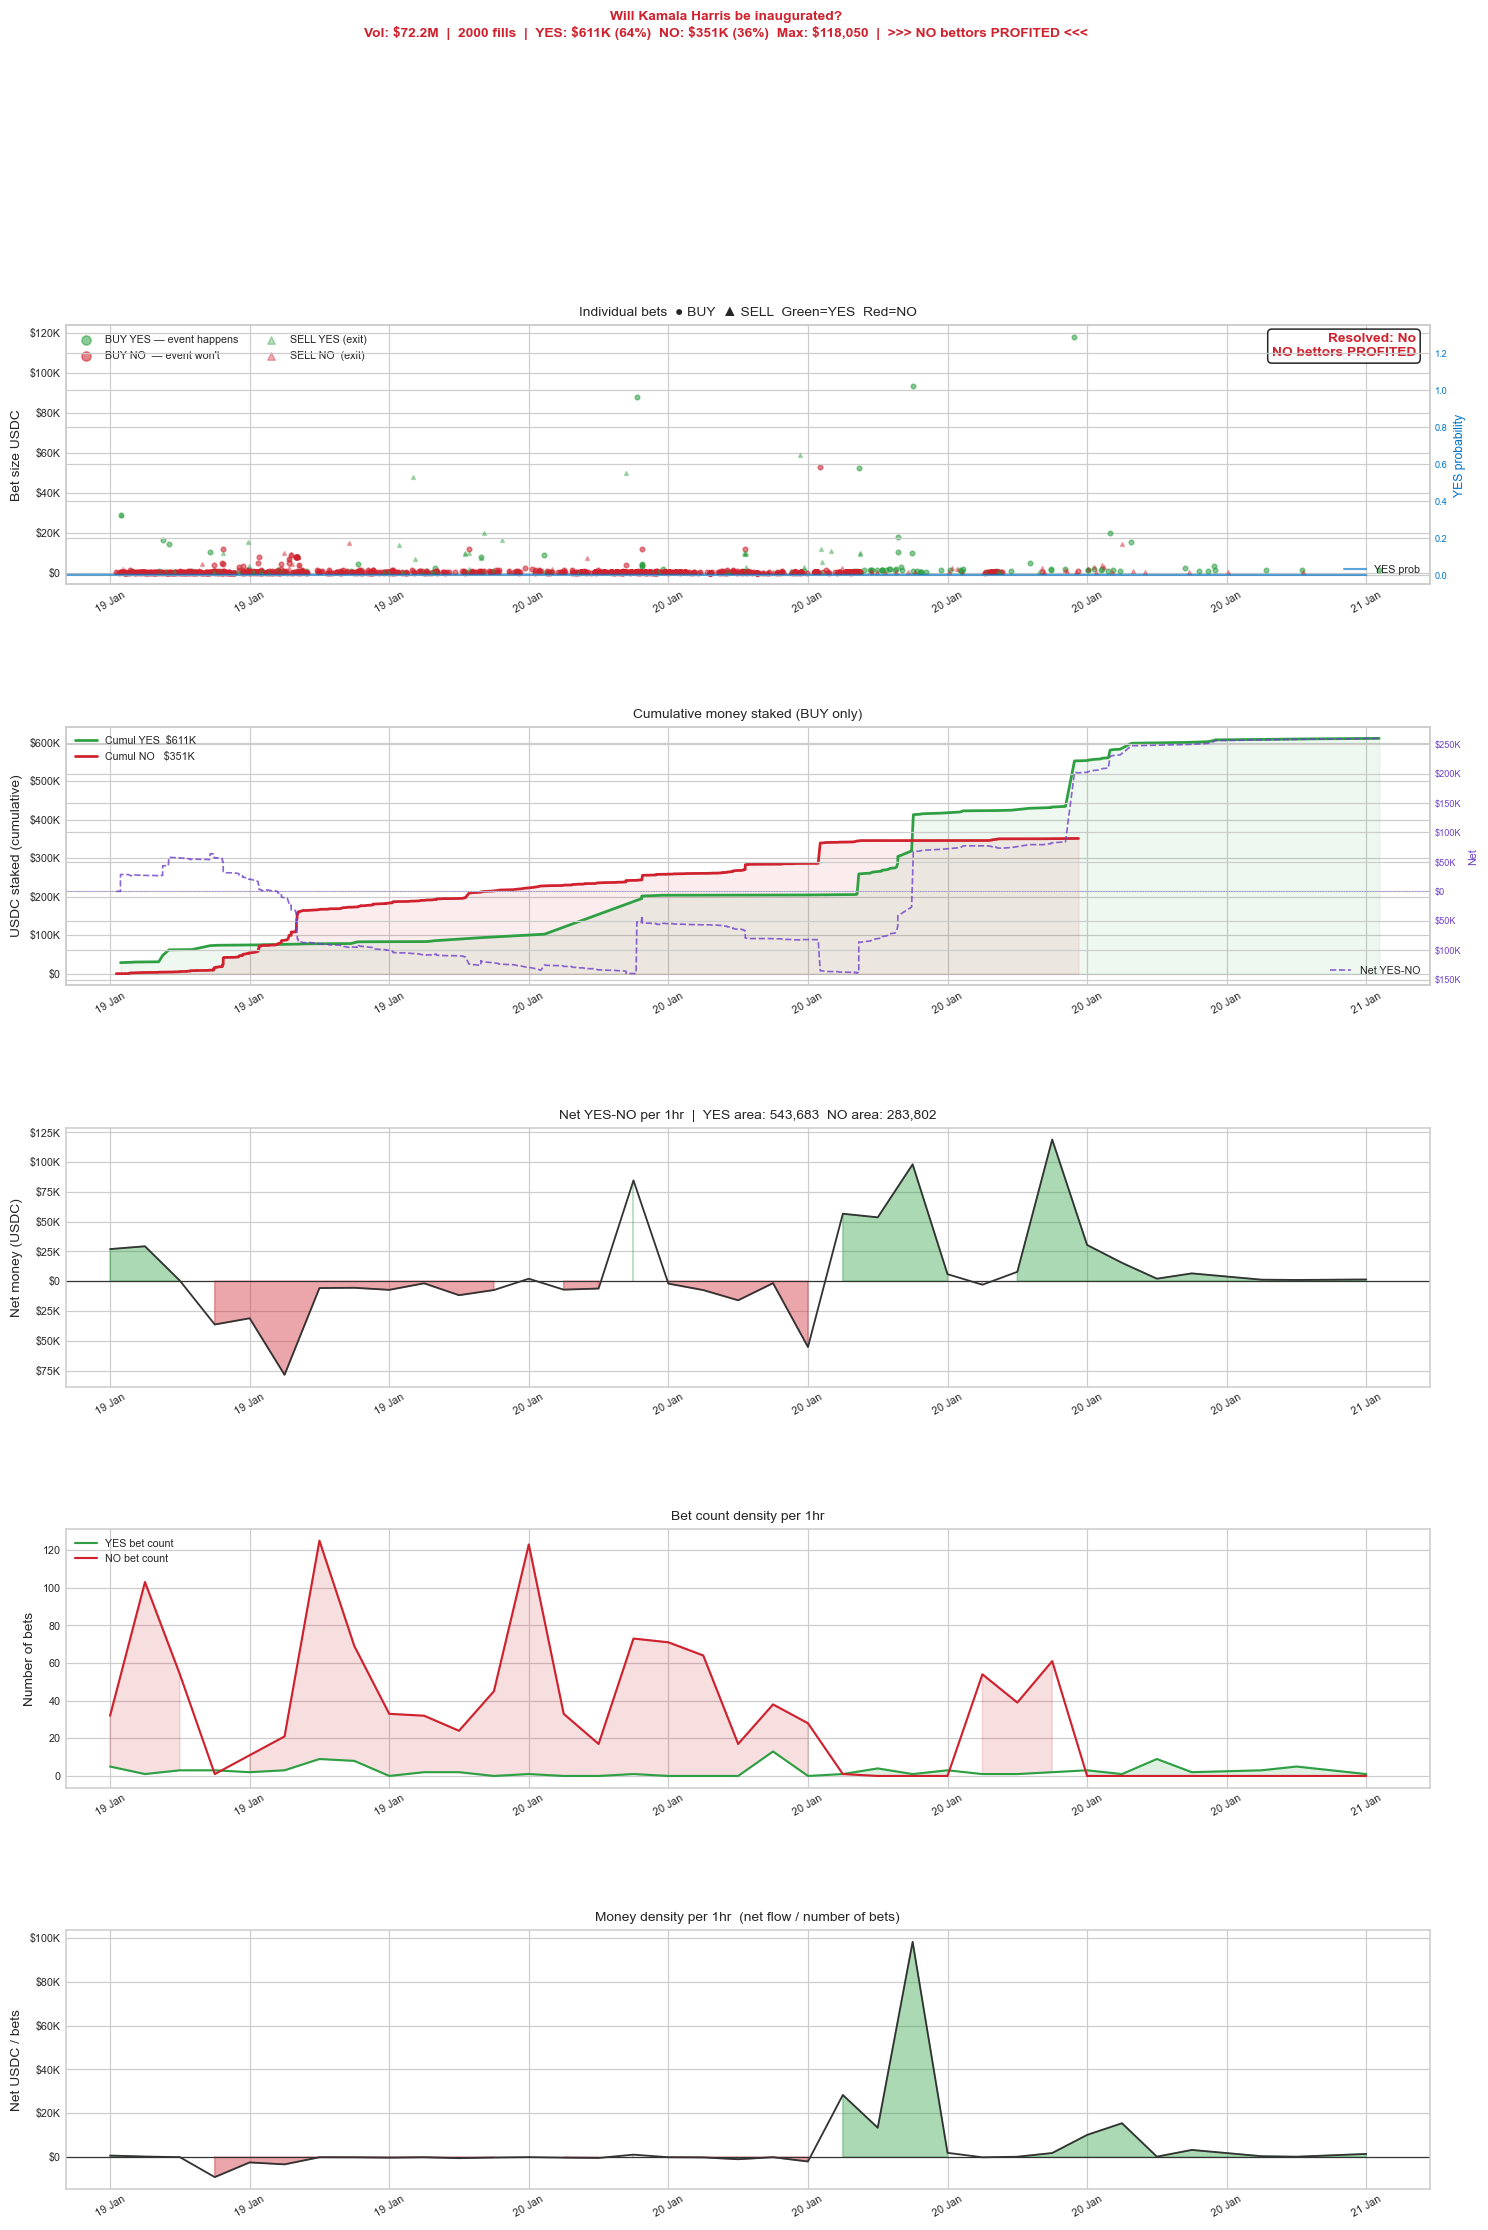

In [3]:
NICE = [60,300,600,900,1800,3600,7200,14400,21600,43200,86400]
NICE_LBL = {60:'1min',300:'5min',600:'10min',900:'15min',1800:'30min',
             3600:'1hr',7200:'2hr',14400:'4hr',21600:'6hr',43200:'12hr',86400:'1day'}

for row in markets.sort('volume_usdc', descending=True).iter_rows(named=True):
    slug       = row['slug']
    question   = row['question']
    resolution = row['resolution']
    total_vol  = float(row['volume_usdc'] or 0)
    yes_won    = (resolution == 'Yes')
    c_res      = C_YES if yes_won else C_NO
    winner     = 'YES bettors' if yes_won else 'NO bettors'

    tr = all_trades.filter(pl.col('slug') == slug)
    ph_p = EDA / slug / 'price_history.csv'
    ph = pl.read_csv(ph_p, schema_overrides=PRICE_SCHEMA).with_columns(
             (pl.col('timestamp')*1_000_000).cast(pl.Datetime('us')).alias('date')
         ) if ph_p.exists() else pl.DataFrame()

    if tr.is_empty(): continue

    yes_buy  = tr.filter((pl.col('side')=='BUY') & (pl.col('outcome')=='Yes'))
    no_buy   = tr.filter((pl.col('side')=='BUY') & (pl.col('outcome')=='No'))
    yes_sell = tr.filter((pl.col('side')=='SELL')& (pl.col('outcome')=='Yes'))
    no_sell  = tr.filter((pl.col('side')=='SELL')& (pl.col('outcome')=='No'))
    buys     = tr.filter(pl.col('side')=='BUY')

    yes_buy_vol = float(yes_buy['size'].sum() or 0)
    no_buy_vol  = float(no_buy['size'].sum()  or 0)
    total_s     = yes_buy_vol + no_buy_vol
    yes_pct     = 100*yes_buy_vol/total_s if total_s else 0
    max_bet     = float(tr['size'].max() or 0)

    ts_min = int(tr['timestamp'].min())
    ts_max = int(tr['timestamp'].max())
    span_s = ts_max - ts_min
    span_d = span_s / 86400
    pad    = timedelta(seconds=max(span_s*0.04, 3600))
    xlim   = (datetime.fromtimestamp(ts_min)-pad, datetime.fromtimestamp(ts_max)+pad)
    raw_b  = max(span_s/30, 60)
    bsecs  = min(NICE, key=lambda x: abs(x-raw_b))
    blbl   = NICE_LBL.get(bsecs, f'{bsecs}s')
    datefmt= mdates.DateFormatter('%d %b %H:%M' if span_d<1 else '%d %b' if span_d<30 else '%b %Y')

    ph_clip = ph.filter((pl.col('timestamp')>=ts_min-86400)&
                        (pl.col('timestamp')<=ts_max+86400)) if not ph.is_empty() else ph

    # Compute net per bucket to get area
    if not buys.is_empty():
        _b = buys.with_columns(((pl.col('timestamp')//bsecs)*bsecs).alias('bt'))
        _yb = _b.filter(pl.col('outcome')=='Yes').group_by('bt').agg(pl.col('size').sum().alias('y'))
        _nb = _b.filter(pl.col('outcome')=='No').group_by('bt').agg(pl.col('size').sum().alias('n'))
        _jn = _yb.join(_nb, on='bt', how='full').fill_null(0)
        _net = (_jn['y'] - _jn['n']).to_numpy()
        pos_area = float(_net[_net>0].sum())
        neg_area = float(abs(_net[_net<0].sum()))
    else:
        pos_area = neg_area = 0.0

    print(f'{question[:60]}')
    print(f'  YES area: {pos_area:,.0f}  |  NO area: {neg_area:,.0f}')

    title = (f'{question}\n'
             f'Vol: \${total_vol/1e6:.1f}M  |  {len(tr)} fills  |  '
             f'YES: \${yes_buy_vol/1e3:,.0f}K ({yes_pct:.0f}%)  '
             f'NO: \${no_buy_vol/1e3:,.0f}K ({100-yes_pct:.0f}%)  '
             f'Max: \${max_bet:,.0f}  |  >>> {winner} PROFITED <<<')

    fig,(ax1,ax2,ax3,ax4,ax5) = plt.subplots(5,1,figsize=(16,22),
                                              gridspec_kw={'hspace':0.55})
    fig.suptitle(title, fontsize=9, fontweight='bold', color=c_res, y=1.01)

    # Panel 1 — scatter
    for df_s,col,mk,sz,al,lb in [
        (yes_buy, C_YES,'o',9,0.55,'BUY YES — event happens'),
        (no_buy,  C_NO, 'o',9,0.55,'BUY NO  — event won\'t'),
        (yes_sell,C_YES,'^',6,0.35,'SELL YES (exit)'),
        (no_sell, C_NO, '^',6,0.35,'SELL NO  (exit)')]:
        if not df_s.is_empty():
            ax1.scatter(df_s['date'].to_list(),df_s['size'].to_list(),
                        s=sz,alpha=al,color=col,marker=mk,label=lb,zorder=3)
    ax1.yaxis.set_major_formatter(fmt_usdc)
    ax1.set_ylabel('Bet size USDC')
    ax1.set_title('Individual bets  ● BUY  ▲ SELL  Green=YES  Red=NO', fontsize=9)
    ax1.legend(markerscale=2,loc='upper left',ncol=2)
    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_formatter(datefmt)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(),rotation=30)
    ax1.text(0.99,0.97,f'Resolved: {resolution}\n{winner} PROFITED',
             transform=ax1.transAxes,ha='right',va='top',fontsize=9,
             fontweight='bold',color=c_res,
             bbox=dict(boxstyle='round,pad=0.3',fc='white',alpha=0.85))
    if not ph_clip.is_empty():
        ax1b=ax1.twinx()
        ax1b.plot(ph_clip['date'].to_list(),ph_clip['price'].to_list(),
                  color='#0075ca',linewidth=1.4,alpha=0.65,label='YES prob')
        ax1b.set_ylim(-0.05,1.35)
        ax1b.set_ylabel('YES probability',color='#0075ca',fontsize=8)
        ax1b.tick_params(axis='y',colors='#0075ca',labelsize=6)
        ax1b.legend(loc='lower right',fontsize=7)
        ax1b.set_xlim(*xlim)

    # Panel 2 — cumulative
    yes_s = yes_buy.sort('date'); no_s = no_buy.sort('date')
    if not yes_s.is_empty():
        cy = np.cumsum(yes_s['size'].cast(pl.Float64).to_list())
        ax2.plot(yes_s['date'].to_list(),cy,color=C_YES,linewidth=1.8,
                 label=f'Cumul YES  \${yes_buy_vol/1e3:,.0f}K')
        ax2.fill_between(yes_s['date'].to_list(),cy,0,color=C_YES,alpha=0.08)
    if not no_s.is_empty():
        cn = np.cumsum(no_s['size'].cast(pl.Float64).to_list())
        ax2.plot(no_s['date'].to_list(),cn,color=C_NO,linewidth=1.8,
                 label=f'Cumul NO   \${no_buy_vol/1e3:,.0f}K')
        ax2.fill_between(no_s['date'].to_list(),cn,0,color=C_NO,alpha=0.08)
    both = pl.concat([yes_s.select(['date',pl.col('size').alias('net')]),
                      no_s.select(['date',(-pl.col('size')).alias('net')])]).sort('date')
    if not both.is_empty():
        cum_net=np.cumsum(both['net'].cast(pl.Float64).to_list())
        ax2b=ax2.twinx()
        ax2b.plot(both['date'].to_list(),cum_net,color=C_NET,linewidth=1.1,
                  linestyle='--',alpha=0.8,label='Net YES-NO')
        ax2b.axhline(0,color=C_NET,linewidth=0.4,linestyle=':')
        ax2b.yaxis.set_major_formatter(fmt_usdc)
        ax2b.set_ylabel('Net',color=C_NET,fontsize=7)
        ax2b.tick_params(axis='y',colors=C_NET,labelsize=6)
        ax2b.legend(loc='lower right',fontsize=7)
        ax2b.set_xlim(*xlim)
    ax2.yaxis.set_major_formatter(fmt_usdc)
    ax2.set_ylabel('USDC staked (cumulative)')
    ax2.set_title('Cumulative money staked (BUY only)',fontsize=9)
    ax2.legend(loc='upper left')
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_formatter(datefmt)
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30)

    # Panel 3 — net per bucket
    if not buys.is_empty():
        buys_b = buys.with_columns(((pl.col('timestamp')//bsecs)*bsecs).alias('bt'))
        yb = buys_b.filter(pl.col('outcome')=='Yes').group_by('bt').agg(pl.col('size').sum().alias('y')).sort('bt')
        nb_ = buys_b.filter(pl.col('outcome')=='No').group_by('bt').agg(pl.col('size').sum().alias('n')).sort('bt')
        all_ts = sorted(set(yb['bt'].to_list()+nb_['bt'].to_list()))
        ym = dict(zip(yb['bt'].to_list(),yb['y'].to_list()))
        nm = dict(zip(nb_['bt'].to_list(),nb_['n'].to_list()))
        bkts = [datetime.fromtimestamp(t) for t in all_ts]
        net_v= np.array([ym.get(t,0)-nm.get(t,0) for t in all_ts])
        yc   = [ym.get(t,0) for t in all_ts]
        nc   = [nm.get(t,0) for t in all_ts]
        ycnt = dict(zip(buys_b.filter(pl.col('outcome')=='Yes').group_by('bt').agg(pl.len().alias('c'))['bt'].to_list(),
                        buys_b.filter(pl.col('outcome')=='Yes').group_by('bt').agg(pl.len().alias('c'))['c'].to_list()))
        ncnt = dict(zip(buys_b.filter(pl.col('outcome')=='No').group_by('bt').agg(pl.len().alias('c'))['bt'].to_list(),
                        buys_b.filter(pl.col('outcome')=='No').group_by('bt').agg(pl.len().alias('c'))['c'].to_list()))
        yes_cnt=[ycnt.get(t,0) for t in all_ts]
        no_cnt =[ncnt.get(t,0) for t in all_ts]
        tot_b  =[a+b for a,b in zip(yes_cnt,no_cnt)]
        mdens  =np.array([nv/tb if tb>0 else 0 for nv,tb in zip(net_v,tot_b)])

        ax3.plot(bkts,net_v,color='#333',linewidth=1.2,zorder=4)
        ax3.fill_between(bkts,net_v,0,where=net_v>=0,color=C_YES,alpha=0.4)
        ax3.fill_between(bkts,net_v,0,where=net_v<0, color=C_NO, alpha=0.4)
        ax3.axhline(0,color='#333',linewidth=0.8)
        ax3.yaxis.set_major_formatter(fmt_usdc)
        ax3.set_ylabel('Net money (USDC)')
        ax3.set_title(f'Net YES-NO per {blbl}  |  YES area: {pos_area:,.0f}  NO area: {neg_area:,.0f}',fontsize=9)
        ax3.set_xlim(*xlim)
        ax3.xaxis.set_major_formatter(datefmt)
        ax3.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax3.xaxis.get_majorticklabels(),rotation=30)

        ax4.plot(bkts,yes_cnt,color=C_YES,linewidth=1.4,label='YES bet count')
        ax4.plot(bkts,no_cnt, color=C_NO, linewidth=1.4,label='NO bet count')
        ax4.fill_between(bkts,yes_cnt,no_cnt,
                         where=[y>=n for y,n in zip(yes_cnt,no_cnt)],color=C_YES,alpha=0.15)
        ax4.fill_between(bkts,yes_cnt,no_cnt,
                         where=[y<n  for y,n in zip(yes_cnt,no_cnt)],color=C_NO, alpha=0.15)
        ax4.set_ylabel('Number of bets')
        ax4.set_title(f'Bet count density per {blbl}',fontsize=9)
        ax4.legend(loc='upper left',fontsize=7)
        ax4.set_xlim(*xlim)
        ax4.xaxis.set_major_formatter(datefmt)
        ax4.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax4.xaxis.get_majorticklabels(),rotation=30)

        ax5.plot(bkts,mdens,color='#333',linewidth=1.2,zorder=4)
        ax5.fill_between(bkts,mdens,0,where=mdens>=0,color=C_YES,alpha=0.4)
        ax5.fill_between(bkts,mdens,0,where=mdens<0, color=C_NO, alpha=0.4)
        ax5.axhline(0,color='#333',linewidth=0.8)
        ax5.yaxis.set_major_formatter(fmt_usdc)
        ax5.set_ylabel('Net USDC / bets')
        ax5.set_title(f'Money density per {blbl}  (net flow / number of bets)',fontsize=9)
        ax5.set_xlim(*xlim)
        ax5.xaxis.set_major_formatter(datefmt)
        ax5.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax5.xaxis.get_majorticklabels(),rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close(fig)